# Hotel Reservation Business Analysis

Analisis data reservasi hotel untuk mengevaluasi performa bisnis, perilaku tamu, performa OTA, revenue, cancellation, dan occupancy.

**Dataset**
- Reservation 2025–2026

**Author**
- Ananda Mahaputra

In [7]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from pandas.tseries.offsets import MonthBegin

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"]=(12,6)
plt.rcParams["axes.titlesize"]=15
plt.rcParams["axes.labelsize"]=12
plt.rcParams["legend.fontsize"]=11
plt.rcParams["figure.dpi"]=120

In [8]:
df = pd.read_excel("/home/mahaputra777/pt_skp/dataset/pp_may_june_2026.xls")

print(df.shape)

df.head()

(1613, 31)


,Reservation Date,Folio,Reference No,Room Type,Room,Rates,Guest,Date of Birth,Guest Email,Nationality,...,Status,Cancel Date,Special Request,Room Charge,Extra Charge,Pos,Rebate,Commission,Total,Room Net
0,2025-07-09,4.0,NaN,River House,River House,Room Breakfast 4 Pax,Anthony,NaN,NaN,NaN,...,CHECK_OUT,NaN,NaN,8730000,0,0.0,0,218250.0,8730000.0,6.992888e+06
1,2025-07-09,7.0,NaN,River Suite,River Suite C3,Room Breakfast 2 Pax,Clair Fraser,NaN,NaN,NaN,...,CHECK_OUT,NaN,NaN,7692300,0,0.0,0,1384614.0,7692300.0,4.811399e+06
2,2025-07-09,6.0,NaN,River Suite,River Suite C4,Room Breakfast 2 Pax,Clair Fraser,NaN,NaN,NaN,...,CHECK_OUT,NaN,NaN,7692300,0,0.0,0,1384614.0,7692300.0,4.811399e+06
3,2025-07-09,5.0,NaN,River Suite,River Suite A8,Room Breakfast 2 Pax,Diana Ivanovski,NaN,NaN,NaN,...,CHECK_OUT,NaN,NaN,9000000,0,0.0,0,225000.0,9000000.0,6.756757e+06
4,2025-07-09,12.0,NaN,River Suite,River Suite D7,Room Breakfast 2 Pax,Kristyn,NaN,NaN,NaN,...,CHECK_OUT,NaN,NaN,6593400,0,0.0,0,1186812.0,6593400.0,4.124057e+06


# Data Cleaning

In [9]:
# Hilangkan row Total
df = df[df["Reservation Date"]!="Total"].copy()

# datetime
date_columns = [
    "Reservation Date",
    "Arrival",
    "Departure",
    "Cancel Date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# uppercase status

df["Status"] = df["Status"].str.upper()

df.reset_index(drop=True, inplace=True)

In [10]:
missing = (
    df
    .isna()
    .sum()
    .to_frame("Missing")
)

missing["Percentage"] = (
    missing["Missing"]/len(df)
)*100

missing.sort_values(
    "Percentage",
    ascending=False
)

,Missing,Percentage
Province,1612,100.000000
Visit Purpose,1612,100.000000
Special Request,1612,100.000000
City,1612,100.000000
Date of Birth,1612,100.000000
Cancel Date,1341,83.188586
Market Segment,1330,82.506203
Nationality,1118,69.354839
Reference No,726,45.037221
Guest Email,613,38.027295


In [11]:
print("Rows :",len(df))
print("Columns :",len(df.columns))

display(df.info())

display(df.describe(include="all"))

Rows : 1612
Columns : 31
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1612 entries, 0 to 1611
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Reservation Date  1612 non-null   datetime64[ns]
 1   Folio             1612 non-null   float64       
 2   Reference No      886 non-null    object        
 3   Room Type         1612 non-null   object        
 4   Room              1611 non-null   object        
 5   Rates             1612 non-null   object        
 6   Guest             1612 non-null   object        
 7   Date of Birth     0 non-null      float64       
 8   Guest Email       999 non-null    object        
 9   Nationality       494 non-null    object        
 10  Country           1381 non-null   object        
 11  Province          0 non-null      float64       
 12  City              0 non-null      float64       
 13  Arrival           1612 non-null   datetime64[ns]
 14 

None

,Reservation Date,Folio,Reference No,Room Type,Room,Rates,Guest,Date of Birth,Guest Email,Nationality,...,Status,Cancel Date,Special Request,Room Charge,Extra Charge,Pos,Rebate,Commission,Total,Room Net
count,1612,1612.000000,886.0,1612,1611,1612,1612,0.0,999,494,...,1612,271,0.0,1.612000e+03,1.612000e+03,1.612000e+03,1.612000e+03,1.612000e+03,1.612000e+03,1.612000e+03
unique,NaN,NaN,764.0,5,40,4,1015,NaN,615,26,...,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,75268005.0,River Suite,Basic 5,Room Breakfast 2 Pax,Mr David Solomon,NaN,mg****@g***g.com,Australia,...,CHECK_OUT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,8.0,1143,132,1415,47,NaN,22,327,...,1077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025-12-18 15:45:06.699751936,808.936725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2026-01-20 01:35:38.745387520,NaN,3.556148e+06,8.995037e+03,6.300743e+05,7.368952e+03,3.650252e+05,4.187849e+06,2.473914e+06
min,2025-07-09 00:00:00,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2025-07-12 00:00:00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2025-08-16 00:00:00,405.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2025-09-20 00:00:00,NaN,1.000000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.315817e+06,7.201304e+05
50%,2025-12-05 00:00:00,808.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2026-03-05 00:00:00,NaN,2.268488e+06,0.000000e+00,0.000000e+00,0.000000e+00,1.198800e+05,2.822269e+06,1.551237e+06
75%,2026-04-16 00:00:00,1213.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2026-04-16 00:00:00,NaN,4.000000e+06,0.000000e+00,7.167821e+05,0.000000e+00,4.861512e+05,5.058637e+06,3.103448e+06
max,2026-07-02 00:00:00,1616.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2026-07-01 00:00:00,NaN,3.840000e+07,1.750000e+06,9.429608e+06,1.187875e+07,6.888613e+06,4.497762e+07,2.951724e+07


# add


In [12]:
# ==========================================
# Executive KPI April - Juni 2026
# ==========================================

executive = (
    df[
        (df["Arrival"].dt.year == 2026) &
        (df["Arrival"].dt.month.isin([4, 5, 6]))
    ]
    .groupby(df["Arrival"].dt.strftime("%B"))
    .agg(
        Reservations=("Folio", "count"),
        Cancelled=("Status", lambda x: (x == "CANCELLED").sum()),
        Room_Nights=("Nights", "sum"),
        Revenue=("Room Net", "sum"),
        Gross_Revenue=("Room Charge", "sum"),
        Extra_Charge=("Extra Charge", "sum"),
        POS=("Pos", "sum"),
        Commission=("Commission", "sum"),
        Rebate=("Rebate", "sum"),
        Avg_LOS=("Nights", "mean"),
        Avg_Guest=("Person", "mean")
    )
)

# Hitung ADR setelah agregasi
executive["Avg_ADR"] = (
    executive["Revenue"] /
    executive["Room_Nights"]
)

executive["Cancellation Rate (%)"] = (
    executive["Cancelled"] /
    executive["Reservations"] * 100
)

executive = executive[
    [
        "Reservations",
        "Cancelled",
        "Cancellation Rate (%)",
        "Room_Nights",
        "Revenue",
        "Gross_Revenue",
        "Extra_Charge",
        "POS",
        "Commission",
        "Rebate",
        "Avg_ADR",
        "Avg_LOS",
        "Avg_Guest"
    ]
]

display(
    executive.style.format({
        "Cancellation Rate (%)": "{:.2f}%",
        "Revenue": "{:,.0f}",
        "Gross_Revenue": "{:,.0f}",
        "Extra_Charge": "{:,.0f}",
        "POS": "{:,.0f}",
        "Commission": "{:,.0f}",
        "Rebate": "{:,.0f}",
        "Avg_ADR": "{:,.0f}",
        "Avg_LOS": "{:.2f}",
        "Avg_Guest": "{:.2f}"
    })
)

,Reservations,Cancelled,Cancellation Rate (%),Room_Nights,Revenue,Gross_Revenue,Extra_Charge,POS,Commission,Rebate,Avg_ADR,Avg_LOS,Avg_Guest
Arrival,,,,,,,,,,,,,
April,111,21,18.92%,313,"223,954,665","318,846,258",0,"84,013,479","32,819,568",0,"715,510",2.82,1.76
June,119,18,15.13%,357,"228,641,766","338,342,614","2,000,000","95,465,596","39,363,090",0,"640,453",3.00,1.82
May,146,28,19.18%,420,"284,401,804","398,717,264","500,000","99,318,767","32,211,648",0,"677,147",2.88,1.73


In [ ]:
# ==========================================
# OTA Performance April - Juni 2026
# ==========================================

ota = (
    df.loc[
        (df["Arrival"].dt.year == 2026) &
        (df["Arrival"].dt.month.isin([4, 5, 6]))
    ]
    .groupby([
        df.loc[
            (df["Arrival"].dt.year == 2026) &
            (df["Arrival"].dt.month.isin([4, 5, 6])),
            "Arrival"
        ].dt.strftime("%B"),
        "Agent"
    ])
    .agg(
        Booking=("Folio", "count"),
        Revenue=("Room Net", "sum"),
        Room_Nights=("Nights", "sum"),
        Commission=("Commission", "sum"),
        Cancelled=("Status", lambda x: (x == "CANCELLED").sum())
    )
)

ota["ADR"] = ota["Revenue"] / ota["Room_Nights"]

ota["Cancellation Rate"] = (
    ota["Cancelled"] /
    ota["Booking"] * 100
)

display(
    ota.style.format({
        "Revenue": "{:,.0f}",
        "Commission": "{:,.0f}",
        "ADR": "{:,.0f}",
        "Cancellation Rate": "{:.2f}%"
    })
)

KeyError: 'Arrival Month'

In [ ]:
room = (
    df[
        (df["Arrival"].dt.year==2026) &
        (df["Arrival"].dt.month.isin([4,5,6]))
    ]
    .groupby(["Arrival Month","Room Type"])
    .agg(
        Booking=("Folio","count"),
        Revenue=("Room Net","sum"),
        Nights=("Nights","sum"),
        ADR=("ADR","mean")
    )
)

display(
room.style.format({
    "Revenue":"{:,.0f}",
    "ADR":"{:,.0f}"
})
)

In [ ]:
country = (
    df[
        (df["Arrival"].dt.year==2026) &
        (df["Arrival"].dt.month.isin([4,5,6]))
    ]
    .groupby(["Arrival Month","Country"])
    .agg(
        Booking=("Folio","count"),
        Revenue=("Room Net","sum"),
        Nights=("Nights","sum"),
        ADR=("ADR","mean")
    )
    .sort_values("Revenue",ascending=False)
)

display(
country.head(30).style.format({
    "Revenue":"{:,.0f}",
    "ADR":"{:,.0f}"
})
)

# Feature Engineering

In [ ]:
# Lead Time

df["Lead Time"] = (
    df["Arrival"]-
    df["Reservation Date"]
).dt.days

# Arrival Month

df["Arrival Month"] = (
    df["Arrival"]
    .dt.to_period("M")
)

# Reservation Month

df["Reservation Month"] = (
    df["Reservation Date"]
    .dt.to_period("M")
)

# Weekday

df["Arrival Day"] = (
    df["Arrival"]
    .dt.day_name()
)

# Year

df["Year"] = (
    df["Arrival"]
    .dt.year
)

# Ancillary

df["Total Ancillary"] = (
    df["Extra Charge"]+
    df["Pos"]
)

# Agent Cleaned

df["Agent Cleaned"] = (
    df["Agent"]
    .str.replace(
        " Pay at Agent",
        "",
        regex=False
    )
    .str.replace(
        " Pay at Hotel",
        "",
        regex=False
    )
    .str.strip()
)

# ADR

df["ADR"] = (
    df["Room Net"]/
    df["Nights"]
)

# Reservation Value

df["Reservation Value"] = df["Total"]

df.head()

,Reservation Date,Folio,Reference No,Room Type,Room,Rates,Guest,Date of Birth,Guest Email,Nationality,...,Room Net,Lead Time,Arrival Month,Reservation Month,Arrival Day,Year,Total Ancillary,Agent Cleaned,ADR,Reservation Value
0,2025-07-09,4.0,NaN,River House,River House,Room Breakfast 4 Pax,Anthony,NaN,NaN,NaN,...,6.992888e+06,-4,2025-07,2025-07,Saturday,2025,0.0,Doku Old (Commission Based),1.748222e+06,8730000.0
1,2025-07-09,7.0,NaN,River Suite,River Suite C3,Room Breakfast 2 Pax,Clair Fraser,NaN,NaN,NaN,...,4.811399e+06,-3,2025-07,2025-07,Sunday,2025,0.0,Booking.com,6.873428e+05,7692300.0
2,2025-07-09,6.0,NaN,River Suite,River Suite C4,Room Breakfast 2 Pax,Clair Fraser,NaN,NaN,NaN,...,4.811399e+06,-3,2025-07,2025-07,Sunday,2025,0.0,Booking.com,6.873428e+05,7692300.0
3,2025-07-09,5.0,NaN,River Suite,River Suite A8,Room Breakfast 2 Pax,Diana Ivanovski,NaN,NaN,NaN,...,6.756757e+06,-4,2025-07,2025-07,Saturday,2025,0.0,Doku Old (Commission Based),7.507508e+05,9000000.0
4,2025-07-09,12.0,NaN,River Suite,River Suite D7,Room Breakfast 2 Pax,Kristyn,NaN,NaN,NaN,...,4.124057e+06,-1,2025-07,2025-07,Tuesday,2025,0.0,Booking.com,6.873428e+05,6593400.0


In [ ]:
summary = pd.DataFrame({

"Metric":[

"Total Reservation",

"Cancelled",

"Confirmed",

"Check Out",

"Total Revenue",

"Room Net",

"Ancillary Revenue",

"Average ADR",

"Average Lead Time",

"Average Stay",

"Average Person"

],

"Value":[

len(df),

(df.Status=="CANCELLED").sum(),

(df.Status=="CONFIRMED").sum(),

(df.Status=="CHECK_OUT").sum(),

df.Total.sum(),

df["Room Net"].sum(),

df["Total Ancillary"].sum(),

round(df.ADR.mean(),2),

round(df["Lead Time"].mean(),1),

round(df.Nights.mean(),2),

round(df.Person.mean(),2)

]

})

summary

,Metric,Value
0,Total Reservation,1.612000e+03
1,Cancelled,2.710000e+02
2,Confirmed,0.000000e+00
3,Check Out,1.077000e+03
4,Total Revenue,6.750812e+09
5,Room Net,3.987950e+09
6,Ancillary Revenue,1.030180e+09
7,Average ADR,6.656086e+05
8,Average Lead Time,4.730000e+01
9,Average Stay,3.520000e+00


# Helper Functions

Seluruh visualisasi dibuat menggunakan fungsi agar notebook lebih ringkas, mudah dipelihara, dan dapat digunakan kembali untuk analisis berdasarkan tahun maupun keseluruhan data.

In [ ]:
def add_value_labels(ax, fmt="{:,.0f}", rotation=0):
    """
    Menambahkan label nilai pada bar chart.
    """
    for p in ax.patches:
        value = p.get_height()

        if pd.isna(value):
            continue

        ax.annotate(
            fmt.format(value),
            (p.get_x() + p.get_width()/2, value),
            ha='center',
            va='bottom',
            fontsize=9,
            rotation=rotation
        )


def monthly_group(df, column, agg="sum"):

    temp = (
        df.groupby(
            df["Arrival"].dt.to_period("M")
        )[column]
    )

    if agg=="sum":
        temp=temp.sum()

    elif agg=="mean":
        temp=temp.mean()

    elif agg=="count":
        temp=temp.count()

    temp.index=temp.index.to_timestamp()

    return temp

In [ ]:
def plot_monthly_trend(
    df,
    column,
    agg="sum",
    title="",
    ylabel=""
):

    monthly = monthly_group(df,column,agg)

    this_month = pd.Timestamp.today().replace(
        day=1,
        hour=0,
        minute=0,
        second=0,
        microsecond=0
    )

    last_month=this_month-MonthBegin(1)

    past = monthly[monthly.index<=last_month]

    transition = monthly[
        (monthly.index>=last_month)&
        (monthly.index<=this_month)
    ]

    future = monthly[
        monthly.index>=this_month
    ]

    plt.figure(figsize=(13,6))

    plt.plot(
        past.index,
        past.values,
        marker='o',
        linewidth=2,
        color="royalblue",
        label="Past"
    )

    plt.plot(
        transition.index,
        transition.values,
        marker='o',
        linewidth=3,
        color="gold",
        label="Current"
    )

    plt.plot(
        future.index,
        future.values,
        marker='o',
        linestyle='--',
        linewidth=2,
        color="forestgreen",
        label="Future Booking"
    )

    offset=monthly.max()*0.02

    for x,y in monthly.items():

        plt.text(
            x,
            y+offset,
            f"{y:,.0f}",
            ha="center",
            fontsize=9
        )

    plt.title(title,fontweight="bold")
    plt.xlabel("Arrival Month")
    plt.ylabel(ylabel)

    plt.grid(alpha=.3)

    plt.legend()

    plt.xticks(
        monthly.index,
        monthly.index.strftime("%b\n%Y")
    )

    plt.tight_layout()

    plt.show()

In [ ]:
def plot_booking_trend(df):

    booking = (
        df.groupby(
            df["Arrival"].dt.to_period("M")
        )
        .size()
    )

    booking.index=booking.index.to_timestamp()

    plt.figure(figsize=(13,6))

    plt.plot(
        booking.index,
        booking.values,
        marker="o",
        linewidth=3
    )

    for x,y in booking.items():

        plt.text(
            x,
            y+2,
            str(y),
            ha='center'
        )

    plt.title(
        "Monthly Reservation Trend",
        fontweight="bold"
    )

    plt.xlabel("Arrival Month")

    plt.ylabel("Reservation")

    plt.grid(alpha=.3)

    plt.xticks(
        booking.index,
        booking.index.strftime("%b\n%Y")
    )

    plt.tight_layout()

    plt.show()

In [ ]:
def plot_cancel_rate(df):

    temp = (
        df.groupby(
            df["Arrival"].dt.to_period("M")
        )["Status"]
        .value_counts()
        .unstack(fill_value=0)
    )

    temp["Cancellation Rate"] = (
        temp["CANCELLED"]/
        temp.sum(axis=1)
    )*100

    temp.index=temp.index.to_timestamp()

    plt.figure(figsize=(13,6))

    plt.plot(
        temp.index,
        temp["Cancellation Rate"],
        marker="o",
        linewidth=3,
        color="crimson"
    )

    for x,y in temp["Cancellation Rate"].items():

        plt.text(
            x,
            y+.5,
            f"{y:.1f}%"
        )

    plt.title(
        "Cancellation Rate by Month",
        fontweight="bold"
    )

    plt.ylabel("%")

    plt.grid(alpha=.3)

    plt.xticks(
        temp.index,
        temp.index.strftime("%b\n%Y")
    )

    plt.tight_layout()

    plt.show()

In [ ]:
def plot_top_agent(
    df,
    top=10
):

    temp = (
        df.groupby("Agent Cleaned")
        .agg({

            "Room Net":"sum",

            "Folio":"count"

        })
        .sort_values(
            "Room Net",
            ascending=False
        )
        .head(top)
    )

    ax=temp["Room Net"].plot.bar()

    add_value_labels(ax)

    plt.title(
        "Top Agent by Revenue",
        fontweight="bold"
    )

    plt.ylabel("Room Net")

    plt.tight_layout()

    plt.show()

    return temp

In [ ]:
def plot_country(df,top=10):

    temp=(
        df.groupby("Country")
        .agg({

            "Room Net":"sum"

        })
        .sort_values(
            "Room Net",
            ascending=False
        )
        .head(top)
    )

    ax=temp.plot.bar()

    add_value_labels(ax)

    plt.title(
        "Top Country by Revenue",
        fontweight="bold"
    )

    plt.ylabel("Revenue")

    plt.tight_layout()

    plt.show()

    return temp

In [ ]:
def plot_room_type(df):

    temp=(
        df.groupby("Room Type")
        .agg({

            "Room Net":"sum",

            "Nights":"sum",

            "Folio":"count"

        })
        .sort_values(
            "Room Net",
            ascending=False
        )
    )

    ax=temp["Room Net"].plot.bar()

    add_value_labels(ax)

    plt.title(
        "Revenue by Room Type",
        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()

    return temp

In [ ]:
def plot_rate(df):

    temp=(
        df.groupby("Rates")
        .agg({

            "Room Net":"sum",

            "Nights":"sum",

            "Folio":"count"

        })
        .sort_values(
            "Room Net",
            ascending=False
        )
    )

    ax=temp["Room Net"].plot.bar()

    add_value_labels(ax)

    plt.title(
        "Revenue by Rate Plan",
        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()

    return temp

In [ ]:
def revenue_summary(df):

    revenue=df["Room Net"].sum()

    ancillary=df["Total Ancillary"].sum()

    commission=df["Commission"].sum()

    rebate=df["Rebate"].sum()

    summary=pd.DataFrame({

        "Metric":[

            "Room Revenue",

            "Ancillary Revenue",

            "Commission",

            "Rebate"

        ],

        "Amount":[

            revenue,

            ancillary,

            commission,

            rebate

        ]

    })

    display(summary)

    return summary

# Booking Analysis

Analisis tren reservasi untuk melihat pertumbuhan jumlah booking, pola musiman, dan perkembangan reservasi dari waktu ke waktu.

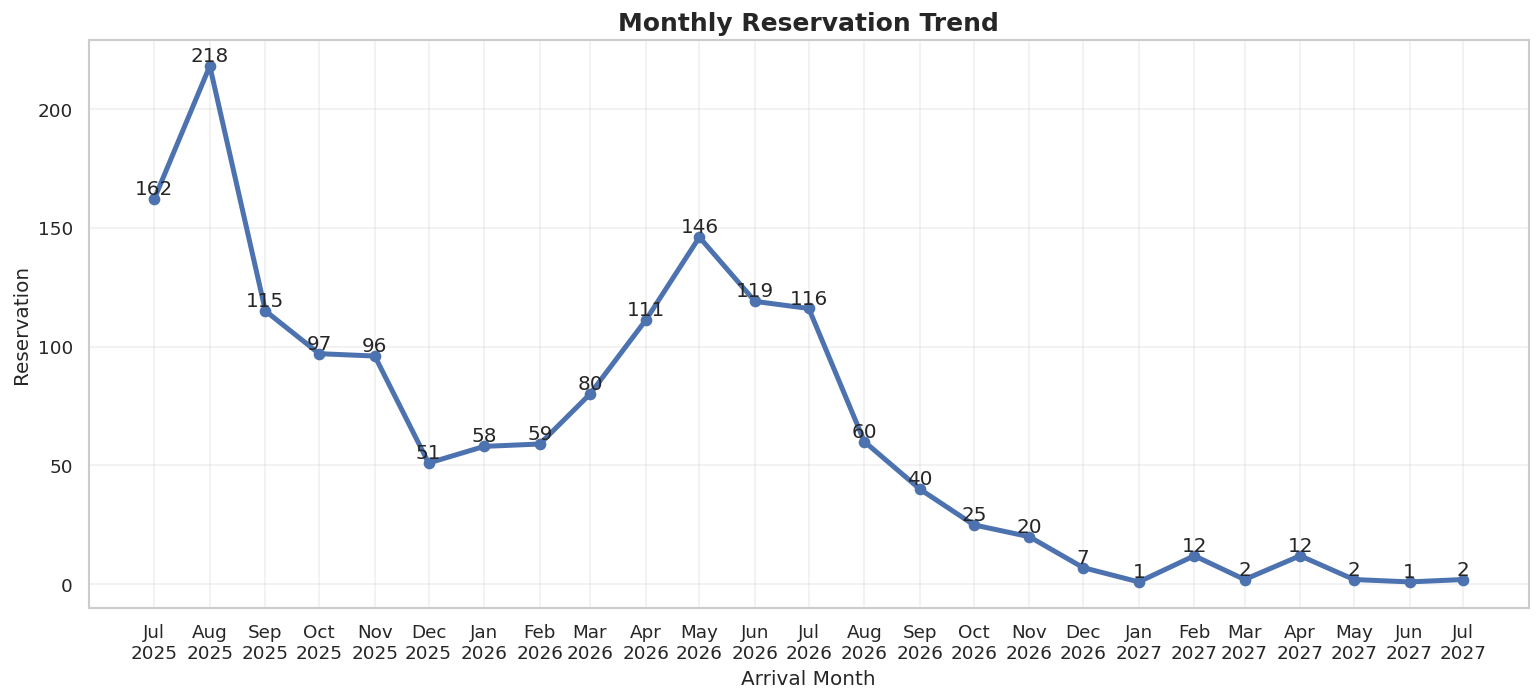

In [ ]:
plot_booking_trend(df)

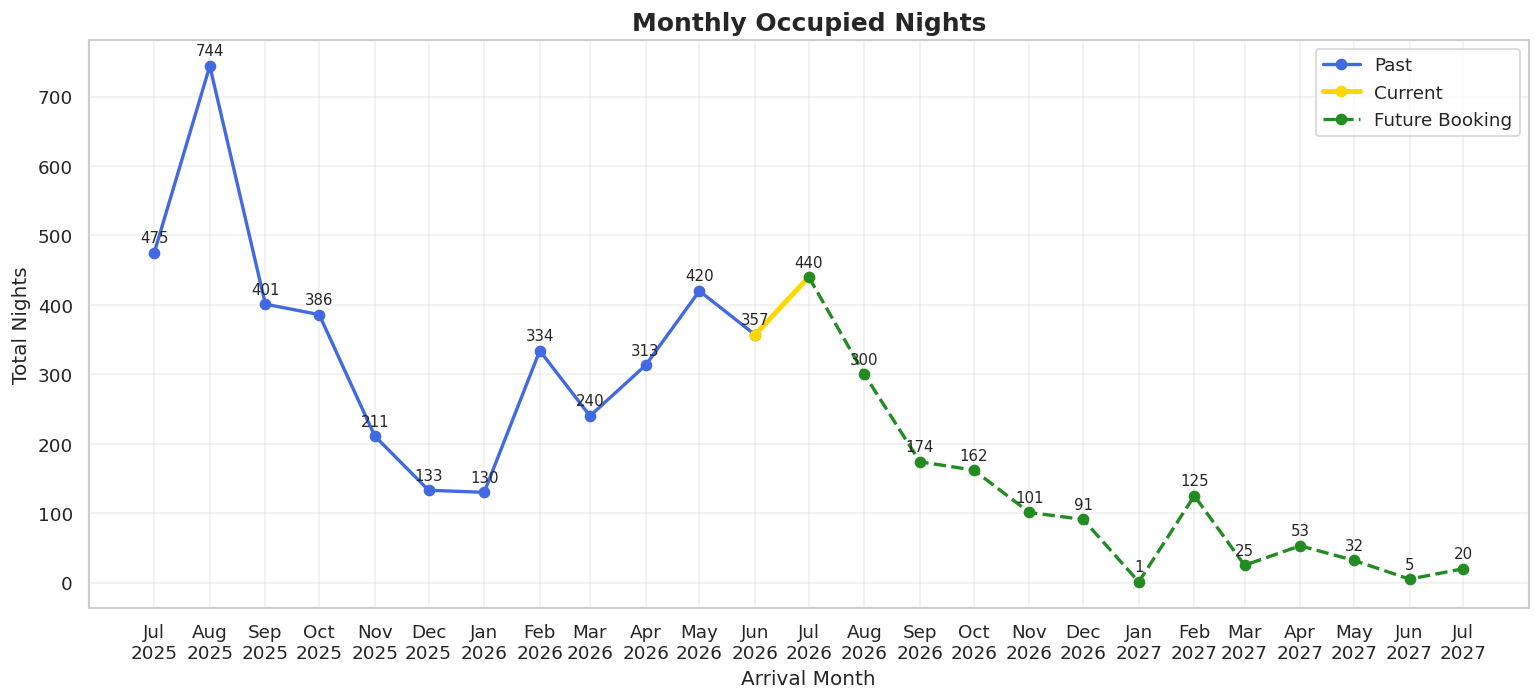

In [ ]:
plot_monthly_trend(
    df,
    column="Nights",
    agg="sum",
    title="Monthly Occupied Nights",
    ylabel="Total Nights"
)

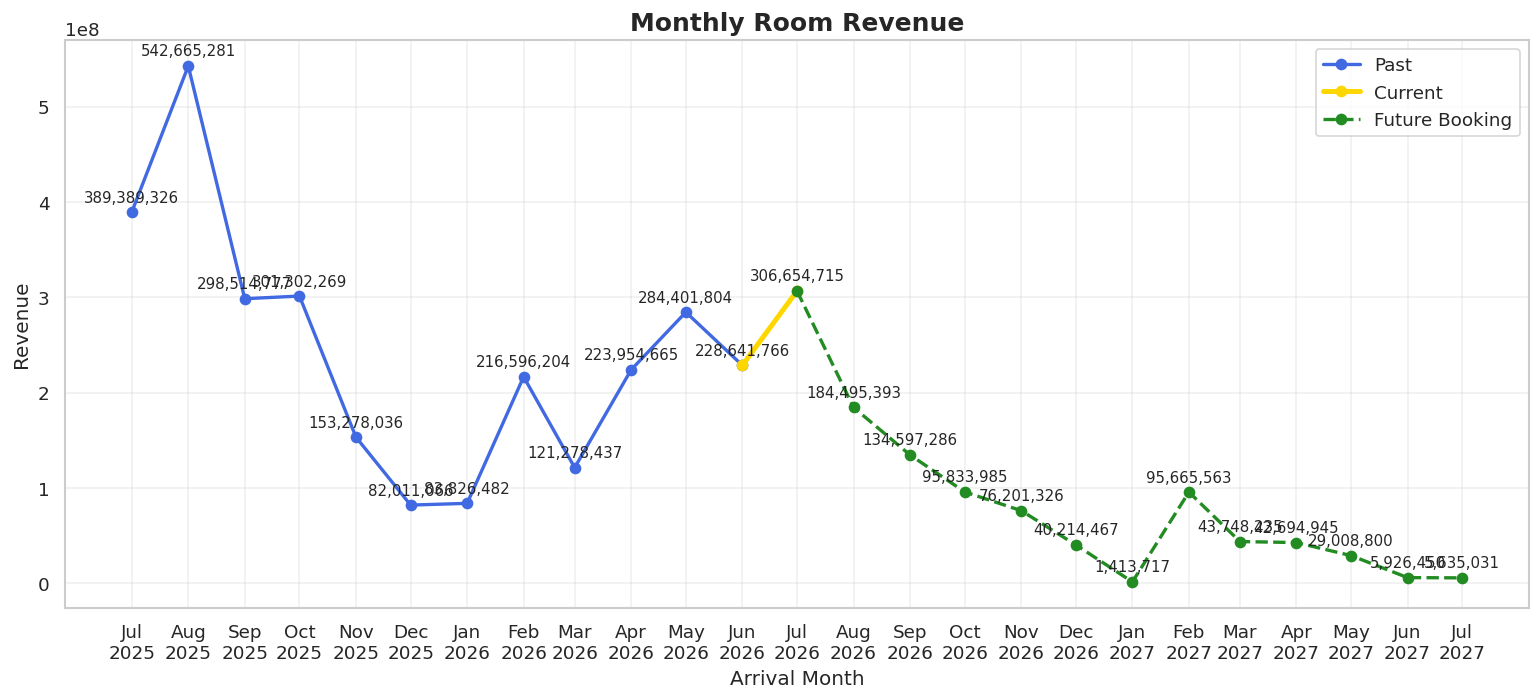

In [ ]:
plot_monthly_trend(
    df,
    column="Room Net",
    agg="sum",
    title="Monthly Room Revenue",
    ylabel="Revenue"
)

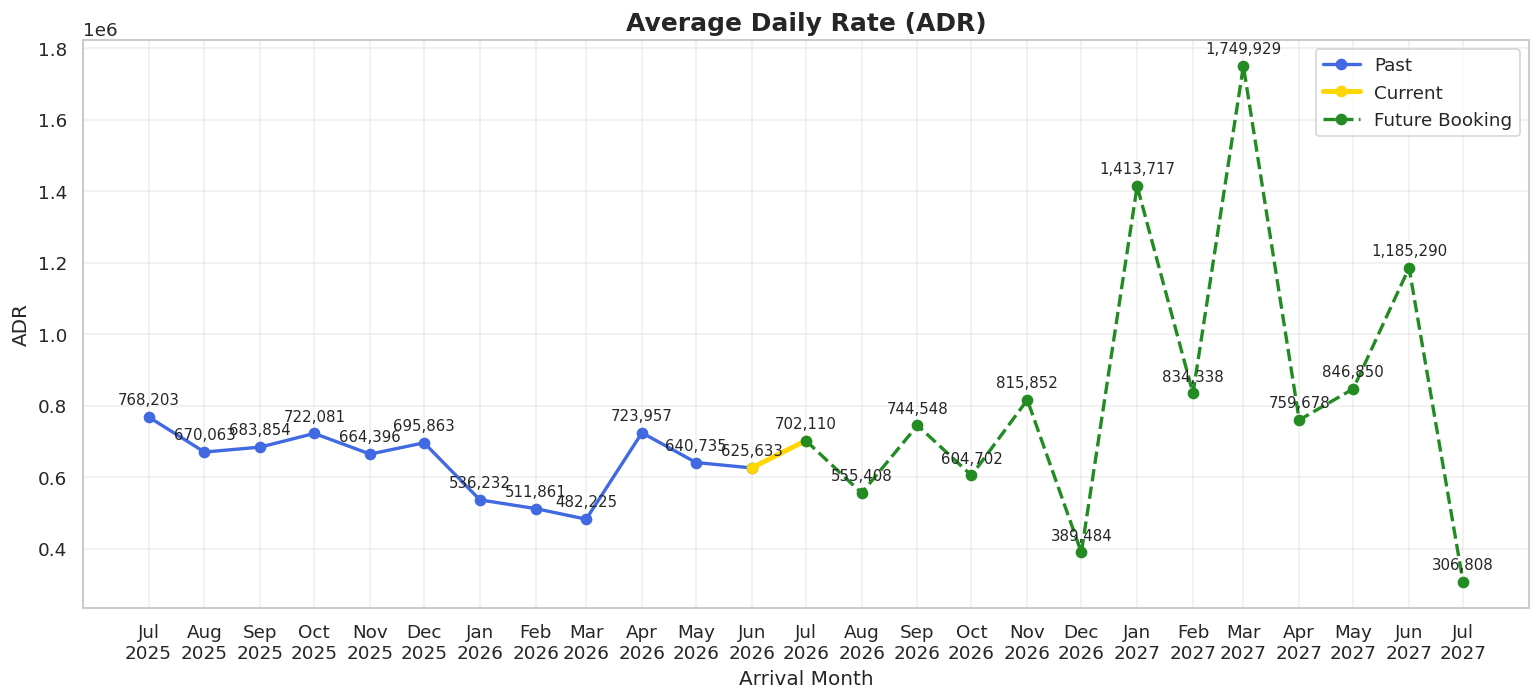

In [ ]:
plot_monthly_trend(
    df,
    column="ADR",
    agg="mean",
    title="Average Daily Rate (ADR)",
    ylabel="ADR"
)

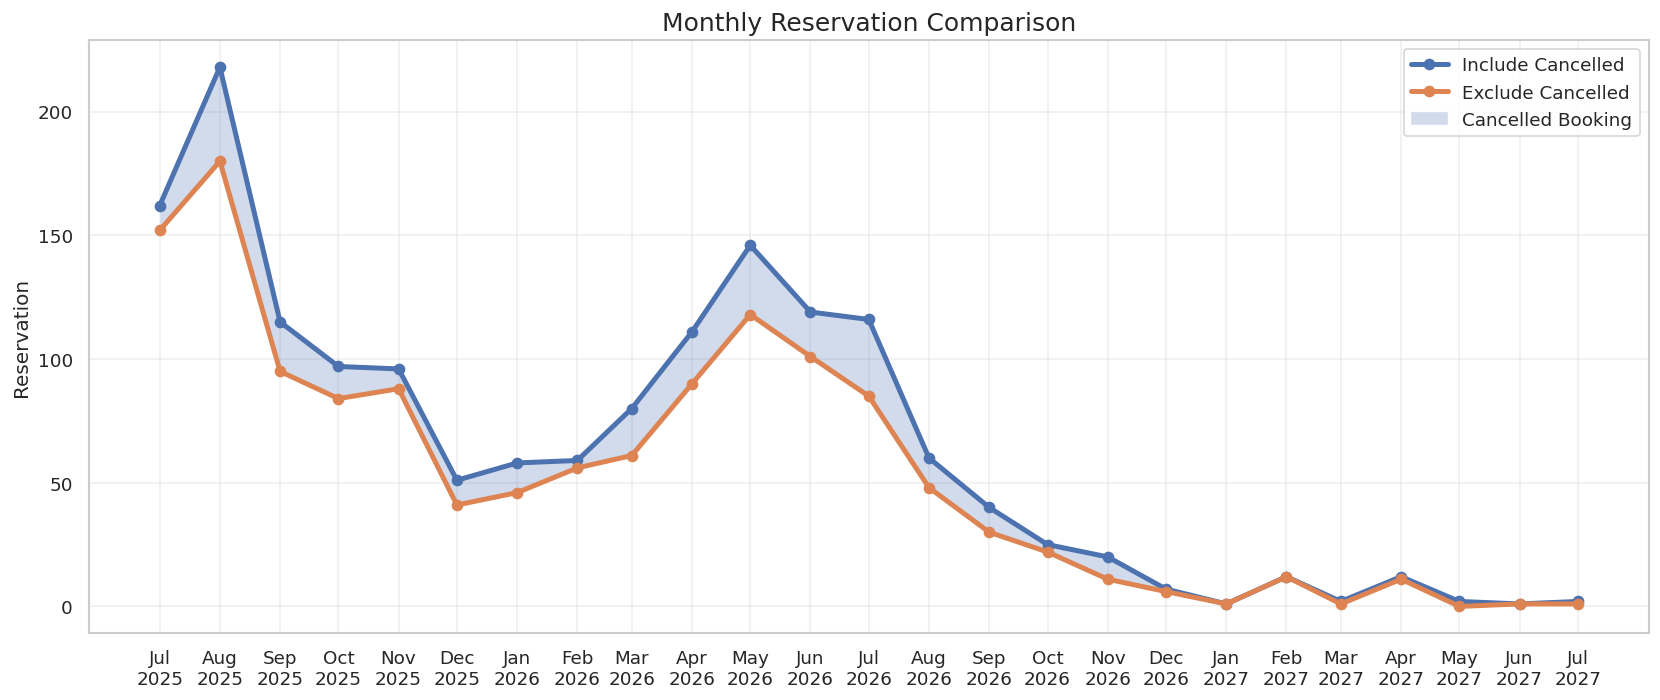

In [ ]:
c

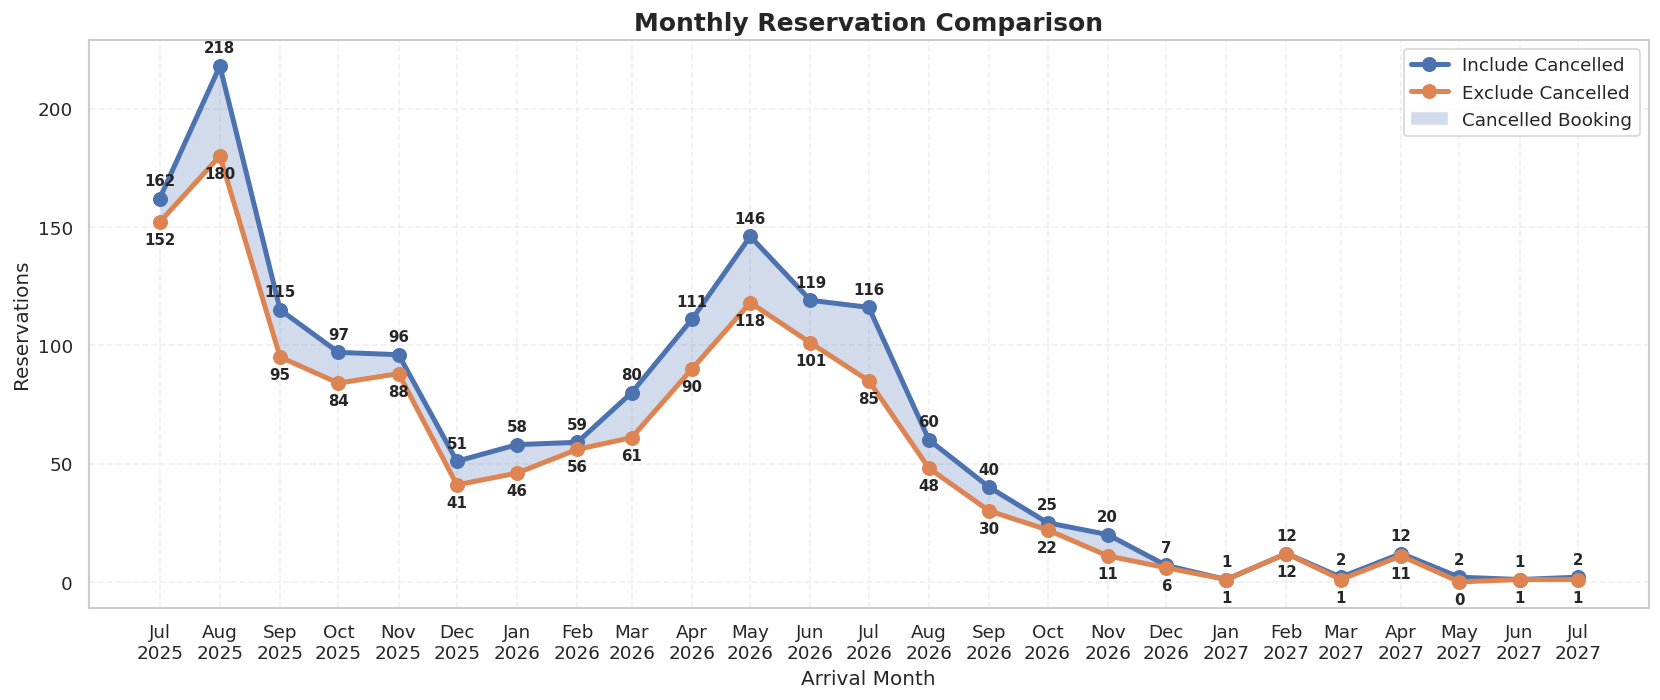

In [ ]:
# ==========================================
# Monthly Booking Comparison
# ==========================================

booking_all = (
    df.groupby(df["Arrival"].dt.to_period("M"))
      .size()
)

booking_live = (
    df.loc[df["Status"] != "CANCELLED"]
      .groupby(df.loc[df["Status"] != "CANCELLED", "Arrival"].dt.to_period("M"))
      .size()
)

booking_all.index = booking_all.index.to_timestamp()
booking_live.index = booking_live.index.to_timestamp()

compare = pd.DataFrame({
    "Include Cancelled": booking_all,
    "Exclude Cancelled": booking_live
}).fillna(0)

plt.figure(figsize=(14,6))

plt.plot(
    compare.index,
    compare["Include Cancelled"],
    marker="o",
    linewidth=3,
    markersize=8,
    label="Include Cancelled"
)

plt.plot(
    compare.index,
    compare["Exclude Cancelled"],
    marker="o",
    linewidth=3,
    markersize=8,
    label="Exclude Cancelled"
)

plt.fill_between(
    compare.index,
    compare["Exclude Cancelled"],
    compare["Include Cancelled"],
    alpha=0.25,
    label="Cancelled Booking"
)

# ==========================================
# Label angka pada setiap titik
# ==========================================

offset = compare["Include Cancelled"].max() * 0.02

for x, y in zip(compare.index, compare["Include Cancelled"]):
    plt.text(
        x,
        y + offset,
        f"{int(y)}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

for x, y in zip(compare.index, compare["Exclude Cancelled"]):
    plt.text(
        x,
        y - offset,
        f"{int(y)}",
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Monthly Reservation Comparison", fontsize=15, fontweight="bold")
plt.xlabel("Arrival Month")
plt.ylabel("Reservations")

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()

plt.xticks(
    compare.index,
    compare.index.strftime("%b\n%Y")
)

plt.tight_layout()
plt.show()

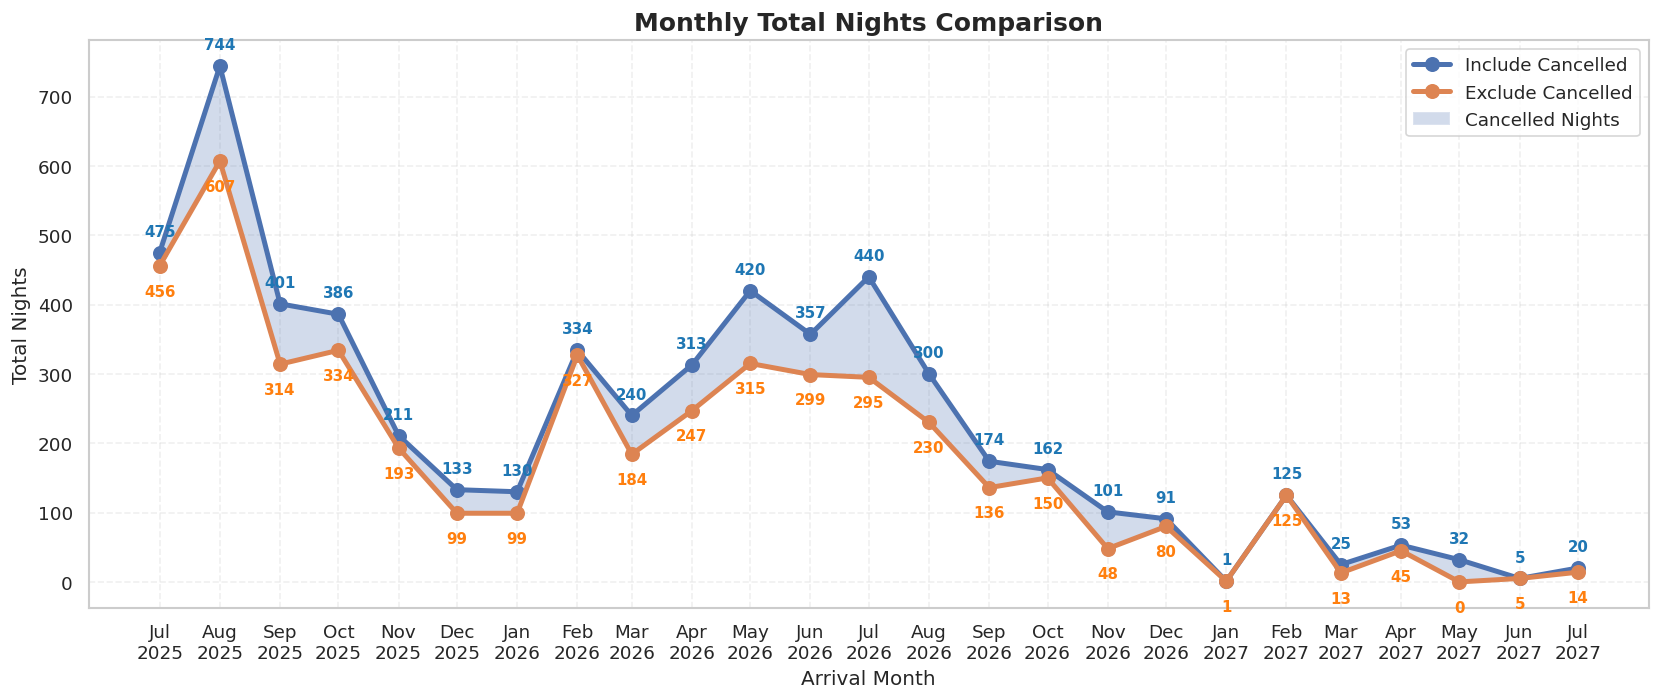

In [ ]:
# ==========================================
# Monthly Total Nights Comparison
# ==========================================

# Total Nights (Include Cancelled)
nights_all = (
    df.groupby(df["Arrival"].dt.to_period("M"))["Nights"]
      .sum()
)

# Total Nights (Exclude Cancelled)
df_live = df[df["Status"] != "CANCELLED"]

nights_live = (
    df_live.groupby(df_live["Arrival"].dt.to_period("M"))["Nights"]
           .sum()
)

# Ubah index menjadi timestamp
nights_all.index = nights_all.index.to_timestamp()
nights_live.index = nights_live.index.to_timestamp()

compare = pd.DataFrame({
    "Include Cancelled": nights_all,
    "Exclude Cancelled": nights_live
}).fillna(0)

plt.figure(figsize=(14,6))

# Include Cancelled
plt.plot(
    compare.index,
    compare["Include Cancelled"],
    marker="o",
    linewidth=3,
    markersize=8,
    label="Include Cancelled"
)

# Exclude Cancelled
plt.plot(
    compare.index,
    compare["Exclude Cancelled"],
    marker="o",
    linewidth=3,
    markersize=8,
    label="Exclude Cancelled"
)

# Area Cancelled
plt.fill_between(
    compare.index,
    compare["Exclude Cancelled"],
    compare["Include Cancelled"],
    alpha=0.25,
    label="Cancelled Nights"
)

# ===========================
# Label Angka
# ===========================

for x, y in zip(compare.index, compare["Include Cancelled"]):
    plt.annotate(
        f"{int(y)}",
        (x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        color="tab:blue",
        fontsize=9,
        fontweight="bold"
    )

for x, y in zip(compare.index, compare["Exclude Cancelled"]):
    plt.annotate(
        f"{int(y)}",
        (x, y),
        xytext=(0, -18),
        textcoords="offset points",
        ha="center",
        color="tab:orange",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    "Monthly Total Nights Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Arrival Month")
plt.ylabel("Total Nights")

plt.grid(True, linestyle="--", alpha=0.3)

plt.legend()

plt.xticks(
    compare.index,
    compare.index.strftime("%b\n%Y")
)

plt.tight_layout()
plt.show()

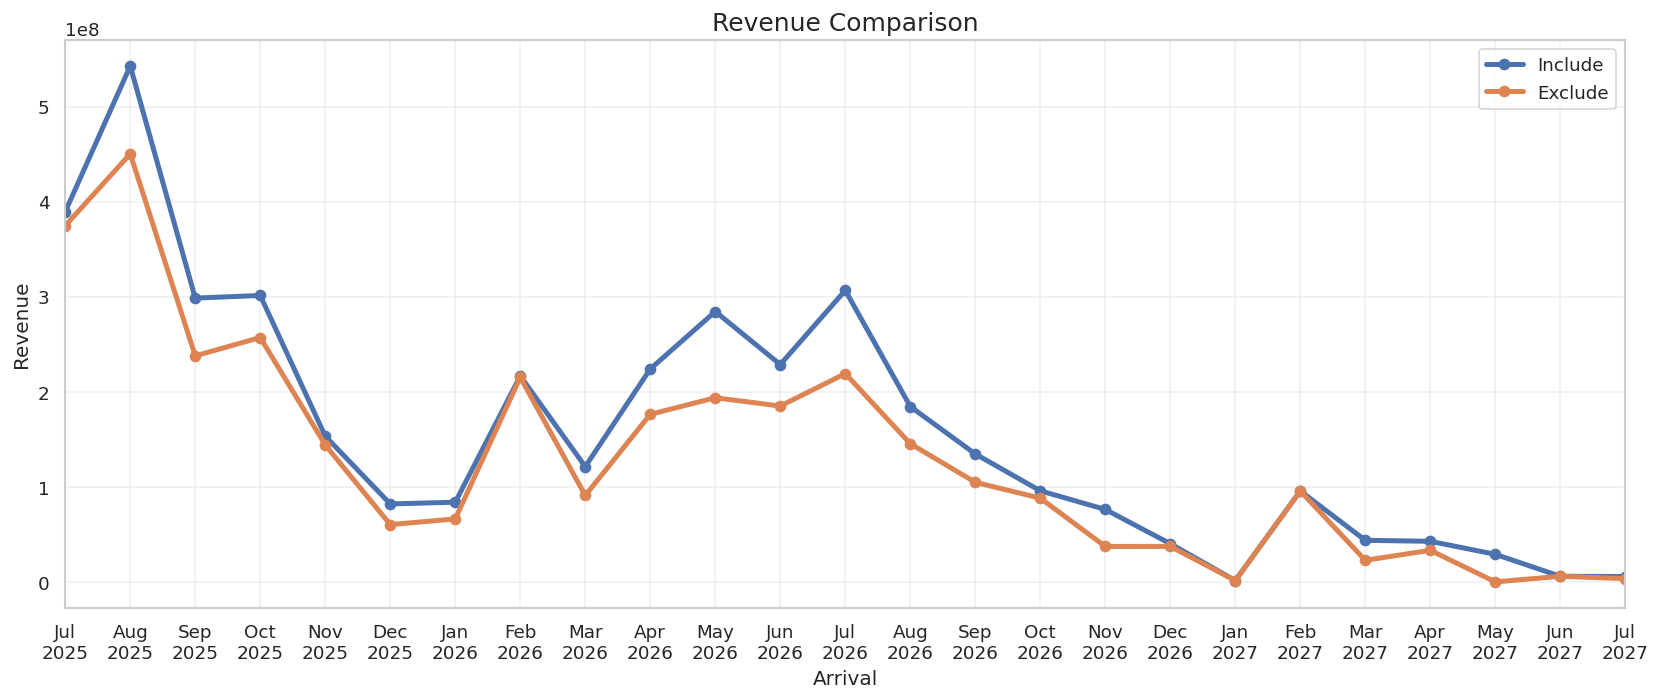

In [ ]:
rev_all = (
    df.groupby(df["Arrival"].dt.to_period("M"))["Room Net"]
    .sum()
)

rev_live = (
    df[df.Status!="CANCELLED"]
    .groupby(
        df[df.Status!="CANCELLED"]["Arrival"].dt.to_period("M")
    )["Room Net"]
    .sum()
)

rev_all.index=rev_all.index.to_timestamp()
rev_live.index=rev_live.index.to_timestamp()

compare=pd.DataFrame({

    "Include":rev_all,

    "Exclude":rev_live

}).fillna(0)

compare.plot(
    figsize=(14,6),
    marker="o",
    linewidth=3
)

plt.title("Revenue Comparison")

plt.ylabel("Revenue")

plt.grid(alpha=.3)

plt.xticks(
    compare.index,
    compare.index.strftime("%b\n%Y")
)

plt.tight_layout()

plt.show()

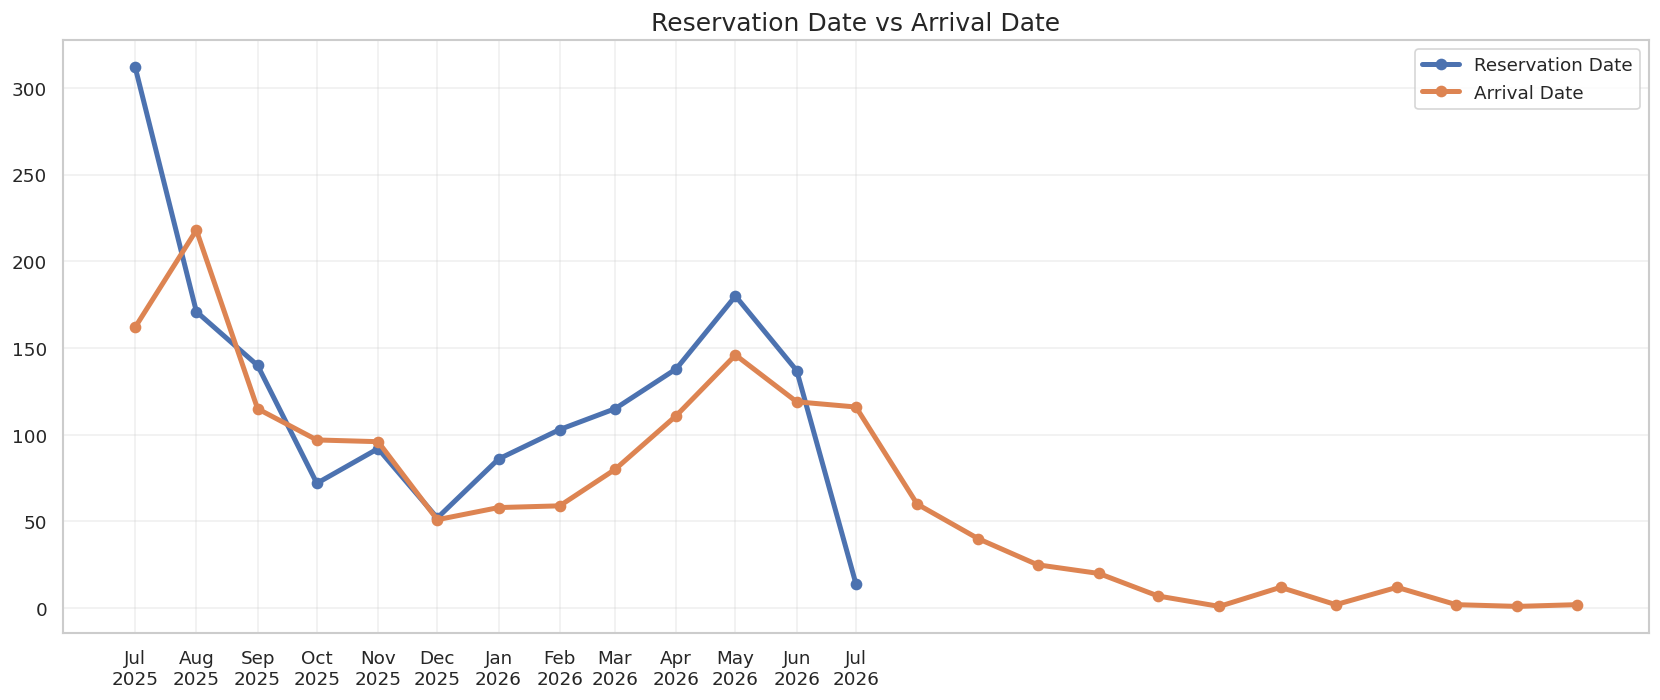

In [ ]:
reservation = (
    df.groupby(
        df["Reservation Month"]
    )
    .size()
)

arrival = (
    df.groupby(
        df["Arrival Month"]
    )
    .size()
)

reservation.index=reservation.index.to_timestamp()

arrival.index=arrival.index.to_timestamp()

plt.figure(figsize=(14,6))

plt.plot(
    reservation.index,
    reservation.values,
    marker="o",
    linewidth=3,
    label="Reservation Date"
)

plt.plot(
    arrival.index,
    arrival.values,
    marker="o",
    linewidth=3,
    label="Arrival Date"
)

plt.legend()

plt.grid(alpha=.3)

plt.title("Reservation Date vs Arrival Date")

plt.xticks(
    reservation.index,
    reservation.index.strftime("%b\n%Y")
)

plt.tight_layout()

plt.show()

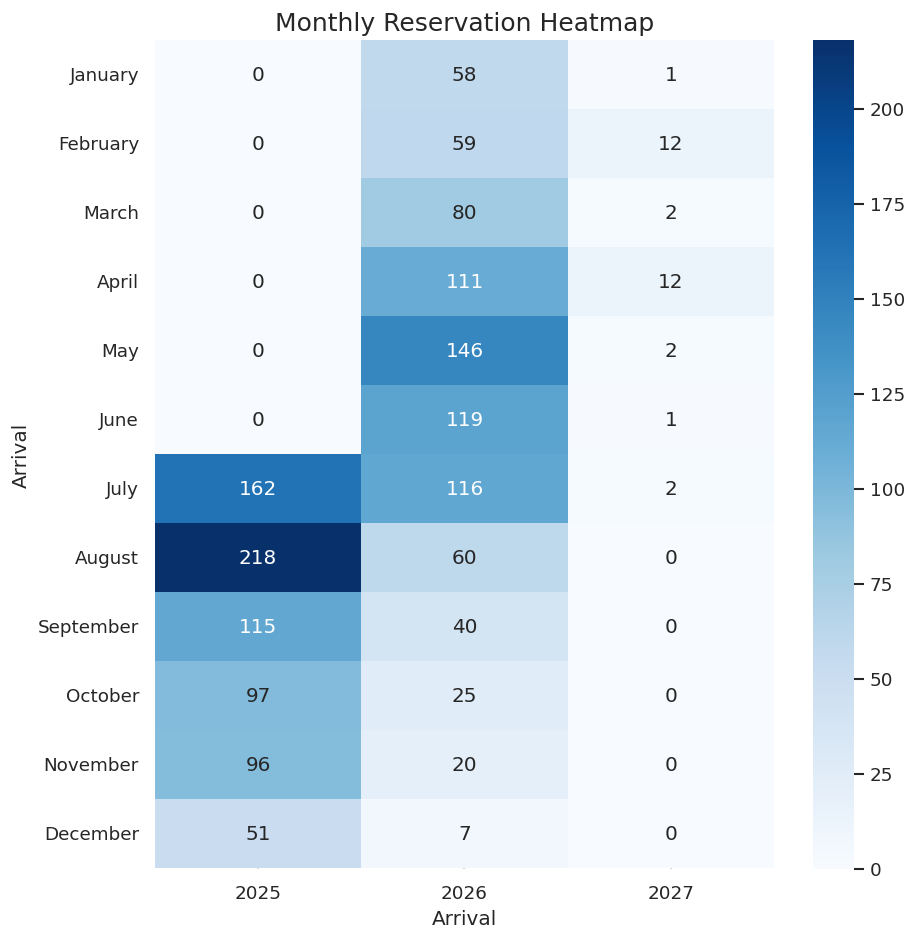

In [ ]:
pivot = pd.crosstab(

    df["Arrival"].dt.month_name(),

    df["Arrival"].dt.year

)

month_order = [

    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"

]

pivot = pivot.reindex(month_order)

plt.figure(figsize=(8,8))

sns.heatmap(

    pivot,

    annot=True,

    cmap="Blues",

    fmt=".0f"

)

plt.title("Monthly Reservation Heatmap")

plt.tight_layout()

plt.show()

In [ ]:
booking = (

    df.groupby(

        df["Arrival"].dt.to_period("M")

    )

    .size()

)

booking = booking.to_frame("Booking")

booking["Growth (%)"] = (

    booking["Booking"]

    .pct_change()

)*100

display(booking)

,Booking,Growth (%)
Arrival,,
2025-07,162,NaN
2025-08,218,34.567901
2025-09,115,-47.247706
2025-10,97,-15.652174
2025-11,96,-1.030928
2025-12,51,-46.875000
2026-01,58,13.725490
2026-02,59,1.724138
2026-03,80,35.593220


# Cancellation Analysis

Menganalisis tingkat pembatalan reservasi untuk mengetahui dampaknya terhadap revenue dan occupancy hotel.

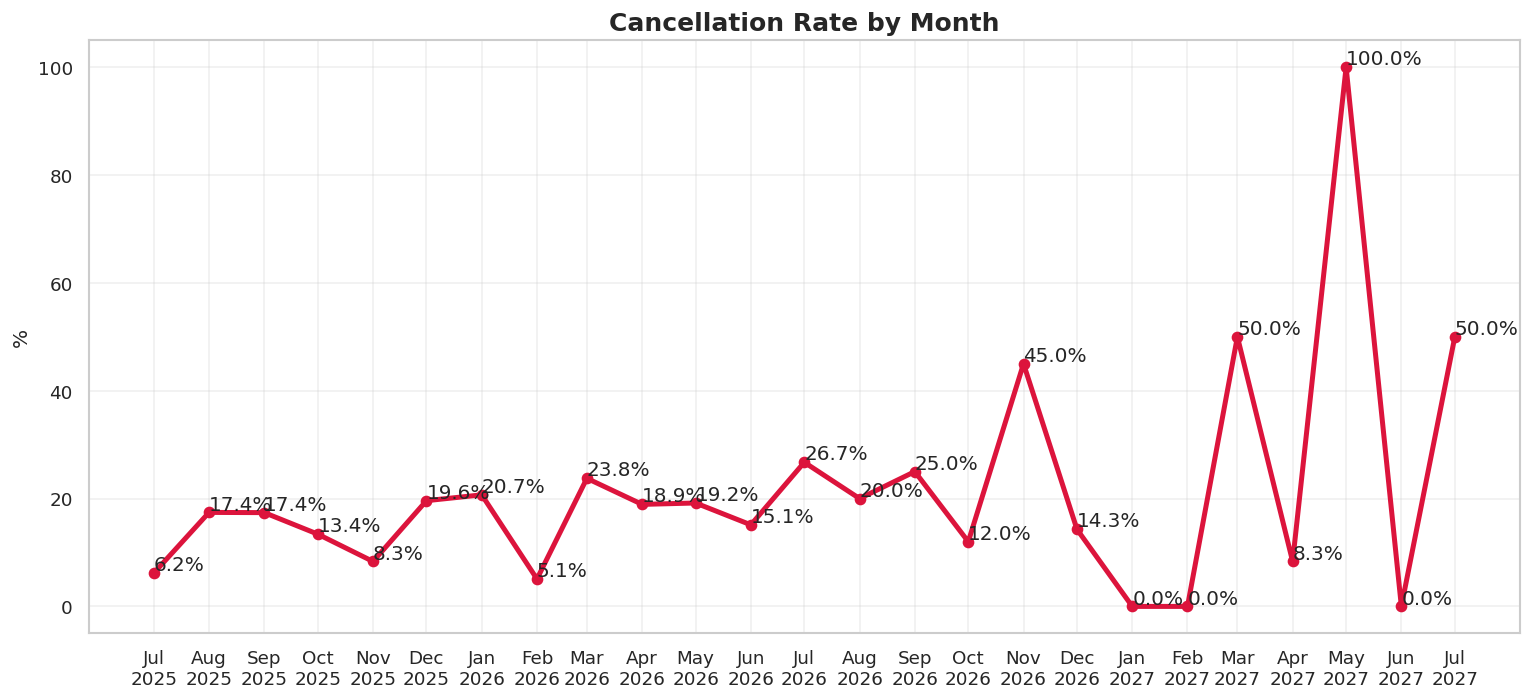

In [ ]:
plot_cancel_rate(df)

,Booking,Cancel,Cancellation Rate
Agent Cleaned,,,
Airbnb,7,2,28.571429
COMPLIMENTARY,7,2,28.571429
Not Mapping,7,2,28.571429
Traveloka,7,2,28.571429
Agoda,61,14,22.950820
DIRECT,540,110,20.370370
Booking.com,823,134,16.281896
Doku Old (Commission Based),29,4,13.793103
C-Trip,49,1,2.040816


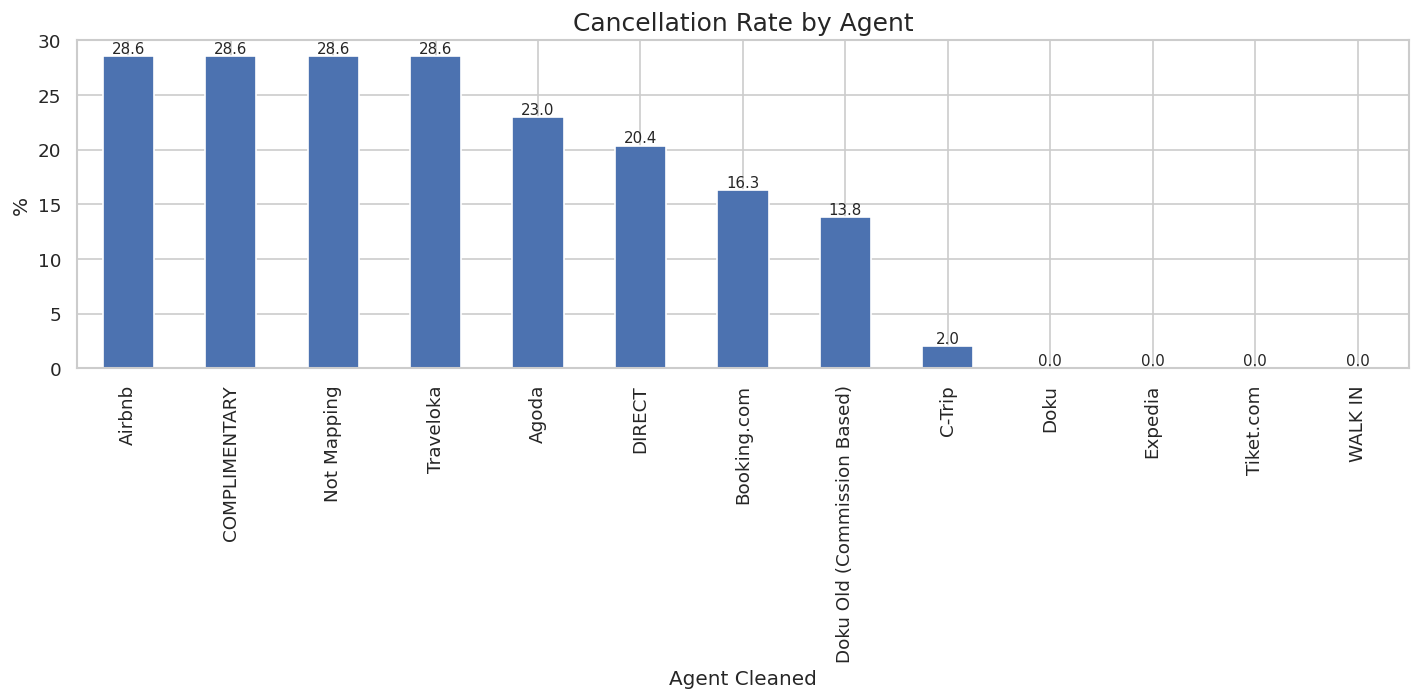

In [ ]:
cancel = (

    df.groupby("Agent Cleaned")

    .agg(

        Booking=("Folio","count"),

        Cancel=("Status",lambda x:(x=="CANCELLED").sum())

    )

)

cancel["Cancellation Rate"]=(

    cancel["Cancel"]

    /cancel["Booking"]

)*100

cancel=cancel.sort_values(

    "Cancellation Rate",

    ascending=False

)

display(cancel.head(20))

ax=cancel.head(15)["Cancellation Rate"].plot.bar()

add_value_labels(ax,fmt="{:.1f}")

plt.ylabel("%")

plt.title("Cancellation Rate by Agent")

plt.tight_layout()

plt.show()

In [ ]:
cancel_country=(

    df.groupby("Country")

    .agg(

        Booking=("Folio","count"),

        Cancel=("Status",lambda x:(x=="CANCELLED").sum())

    )

)

cancel_country["Rate"]=(

    cancel_country["Cancel"]

    /cancel_country["Booking"]

)*100

cancel_country=cancel_country.sort_values(

    "Rate",

    ascending=False

)

display(cancel_country.head(15))

,Booking,Cancel,Rate
Country,,,
Pakistan,1,1,100.000000
New Caledonia,1,1,100.000000
Hungary,3,2,66.666667
Philippines,3,2,66.666667
United States of America,2,1,50.000000
Malta,2,1,50.000000
China,4,2,50.000000
Denmark,10,5,50.000000
Czech Republic,18,8,44.444444


,Booking,Cancel,Cancellation Rate
Lead Group,,,
<1 Week,716,63,8.798883
1 Month,227,41,18.061674
2 Months,162,29,17.901235
3 Months,103,24,23.300971
6 Months,147,47,31.972789
1 Year,141,57,40.425532
>1 Year,5,3,60.000000


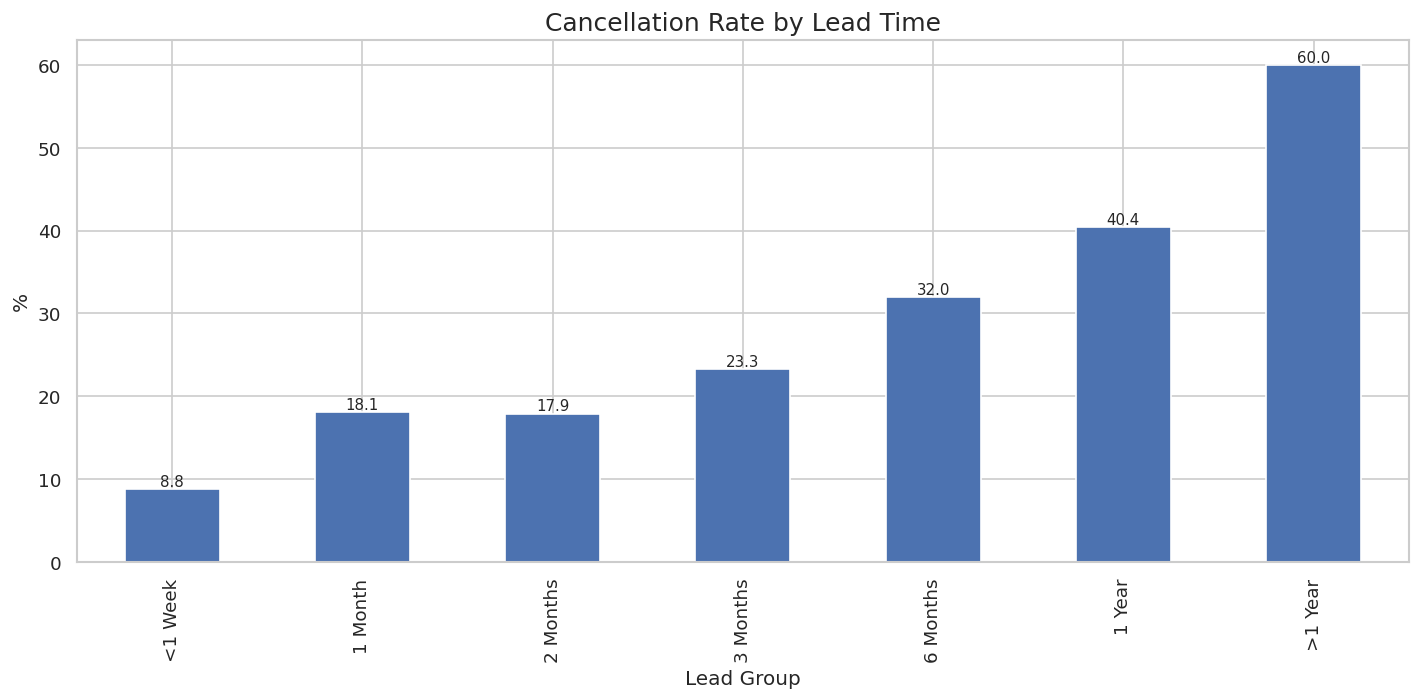

In [ ]:
lead=df.copy()

lead["Lead Group"]=pd.cut(

    lead["Lead Time"],

    bins=[

        -1,

        7,

        30,

        60,

        90,

        180,

        365,

        9999

    ],

    labels=[

        "<1 Week",

        "1 Month",

        "2 Months",

        "3 Months",

        "6 Months",

        "1 Year",

        ">1 Year"

    ]

)

summary=(

    lead.groupby("Lead Group")

    .agg(

        Booking=("Folio","count"),

        Cancel=("Status",lambda x:(x=="CANCELLED").sum())

    )

)

summary["Cancellation Rate"]=(

    summary["Cancel"]

    /summary["Booking"]

)*100

display(summary)

ax=summary["Cancellation Rate"].plot.bar()

add_value_labels(ax,fmt="{:.1f}")

plt.ylabel("%")

plt.title("Cancellation Rate by Lead Time")

plt.tight_layout()

plt.show()

# Revenue Analysis

Bagian ini menganalisis pendapatan hotel berdasarkan waktu, OTA, tipe kamar, rate plan, dan sumber pendapatan lainnya untuk mengetahui kontributor revenue terbesar.

In [ ]:
revenue_summary(df)

,Metric,Amount
0,Room Revenue,3.987950e+09
1,Ancillary Revenue,1.030180e+09
2,Commission,5.884206e+08
3,Rebate,1.187875e+07


,Metric,Amount
0,Room Revenue,3.987950e+09
1,Ancillary Revenue,1.030180e+09
2,Commission,5.884206e+08
3,Rebate,1.187875e+07


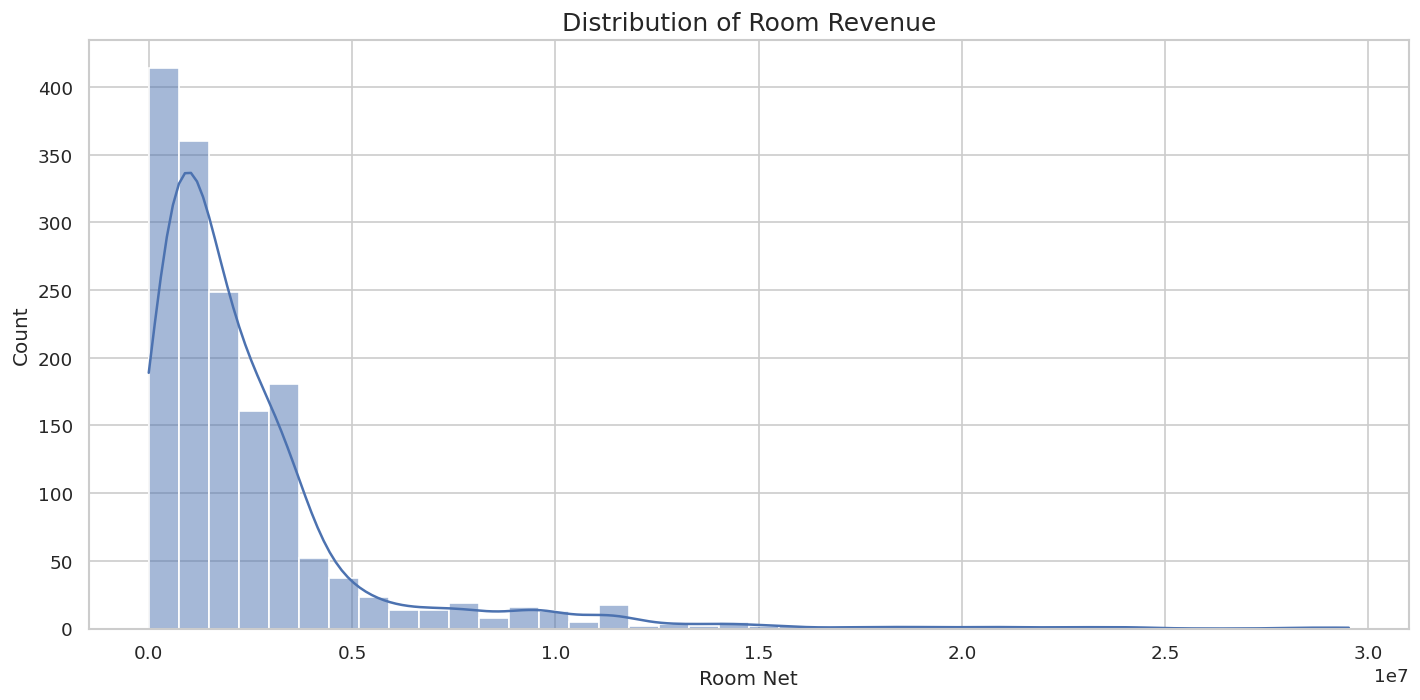

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["Room Net"],
    bins=40,
    kde=True
)

plt.title("Distribution of Room Revenue")

plt.xlabel("Room Net")

plt.tight_layout()

plt.show()

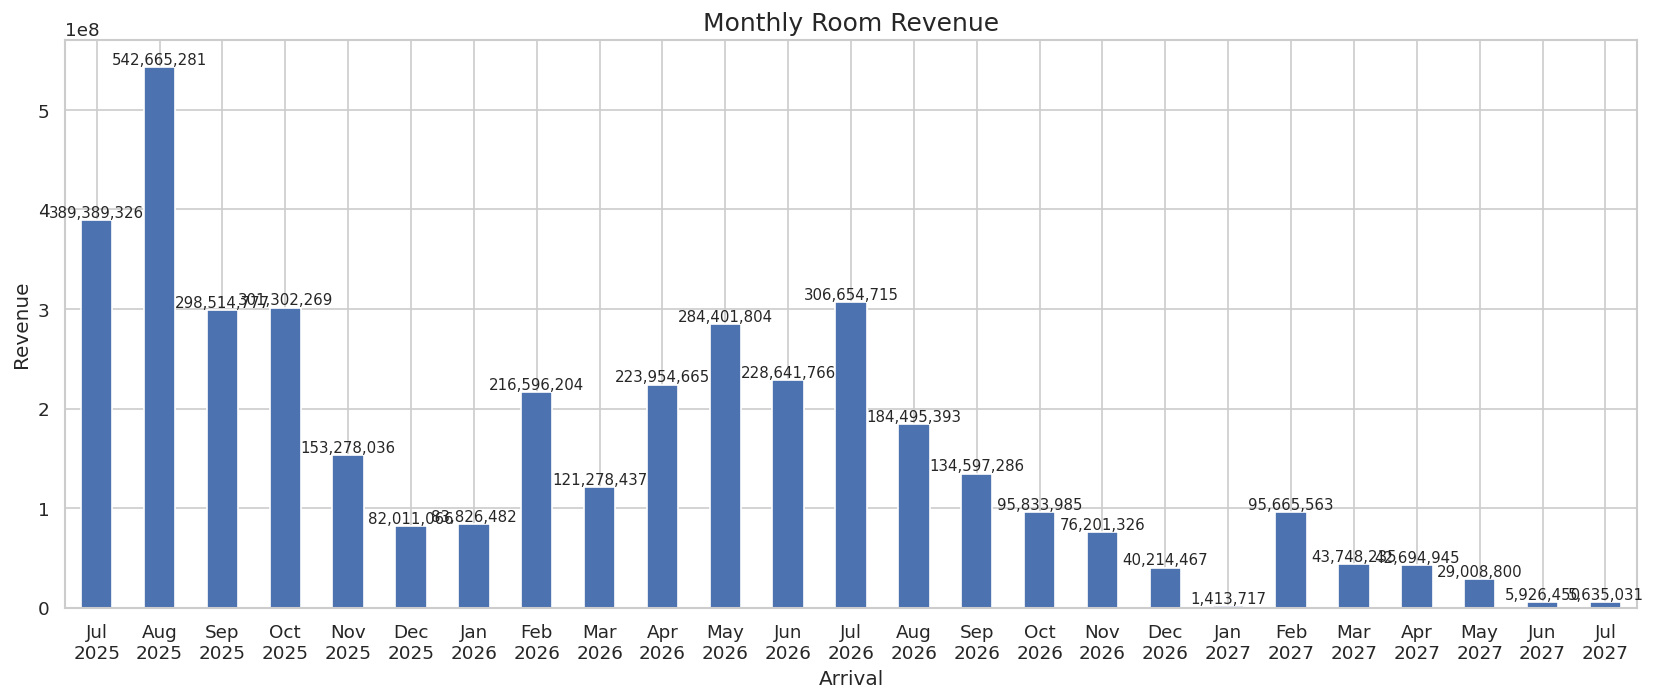

In [ ]:
monthly_revenue = (
    df.groupby(df["Arrival"].dt.to_period("M"))["Room Net"]
      .sum()
)

monthly_revenue.index = monthly_revenue.index.to_timestamp()

ax = monthly_revenue.plot.bar(figsize=(14,6))

add_value_labels(ax)

plt.title("Monthly Room Revenue")

plt.ylabel("Revenue")

plt.xticks(
    range(len(monthly_revenue.index)),
    monthly_revenue.index.strftime("%b\n%Y"),
    rotation=0
)

plt.tight_layout()

plt.show()

In [ ]:
growth = monthly_revenue.to_frame("Revenue")

growth["Growth (%)"] = (
    growth["Revenue"]
    .pct_change()*100
)

display(growth.style.format({

    "Revenue":"{:,.0f}",

    "Growth (%)":"{:.2f}%"

}))

,Revenue,Growth (%)
Arrival,,
2025-07-01 00:00:00,"389,389,326",nan%
2025-08-01 00:00:00,"542,665,281",39.36%
2025-09-01 00:00:00,"298,514,777",-44.99%
2025-10-01 00:00:00,"301,302,269",0.93%
2025-11-01 00:00:00,"153,278,036",-49.13%
2025-12-01 00:00:00,"82,011,066",-46.50%
2026-01-01 00:00:00,"83,826,482",2.21%
2026-02-01 00:00:00,"216,596,204",158.39%
2026-03-01 00:00:00,"121,278,437",-44.01%


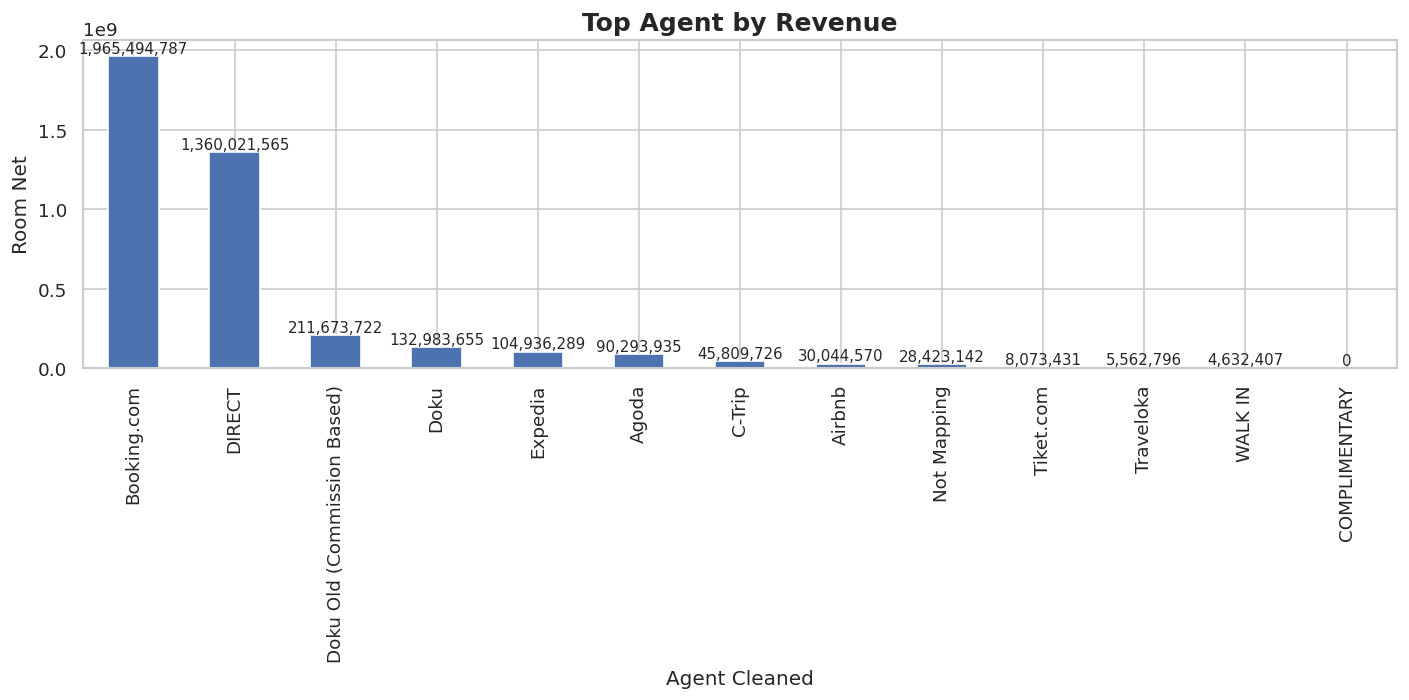

,Room Net,Folio
Agent Cleaned,,
Booking.com,"1,965,494,787",823
DIRECT,"1,360,021,565",540
Doku Old (Commission Based),"211,673,722",29
Doku,"132,983,655",32
Expedia,"104,936,289",36
Agoda,"90,293,935",61
C-Trip,"45,809,726",49
Airbnb,"30,044,570",7
Not Mapping,"28,423,142",7


In [ ]:
top_agent = plot_top_agent(df,15)

display(top_agent.style.format({

    "Room Net":"{:,.0f}"

}))

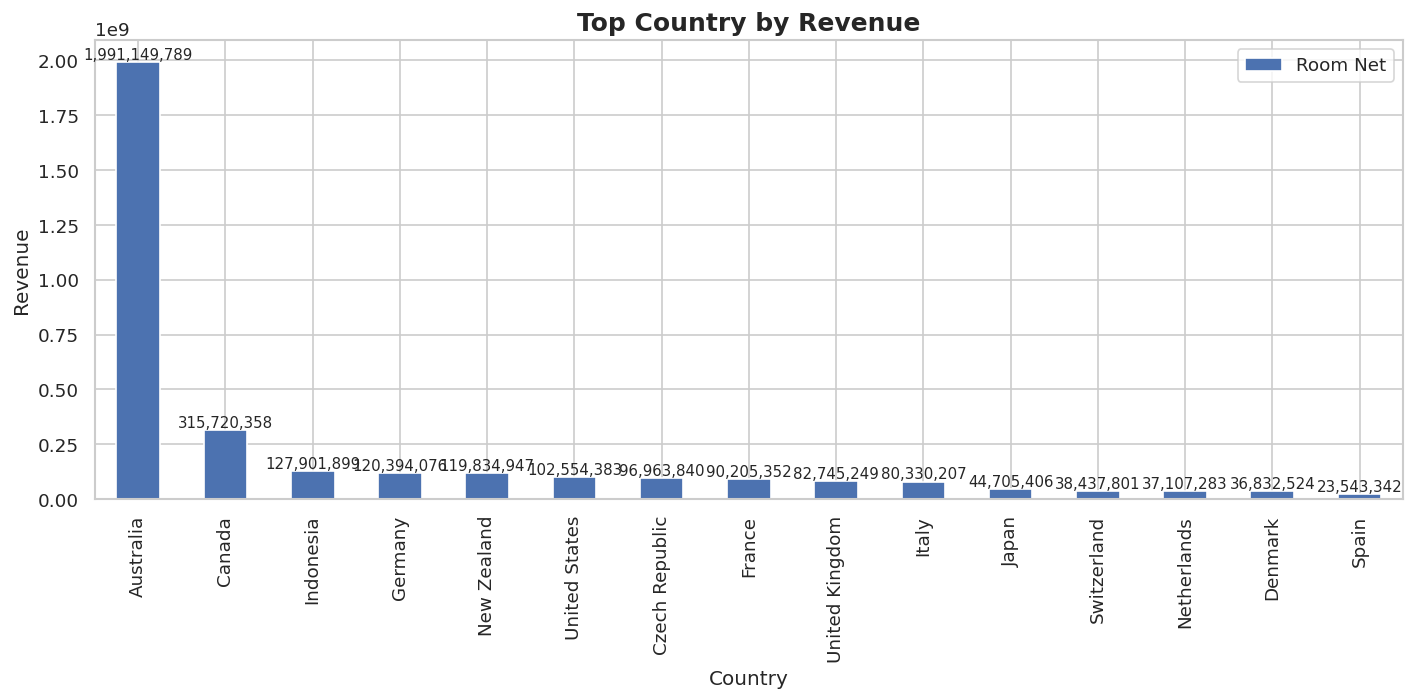

,Room Net
Country,
Australia,"1,991,149,789"
Canada,"315,720,358"
Indonesia,"127,901,899"
Germany,"120,394,076"
New Zealand,"119,834,947"
United States,"102,554,383"
Czech Republic,"96,963,840"
France,"90,205,352"
United Kingdom,"82,745,249"


In [ ]:
country = plot_country(df,15)

display(country.style.format({

    "Room Net":"{:,.0f}"

}))

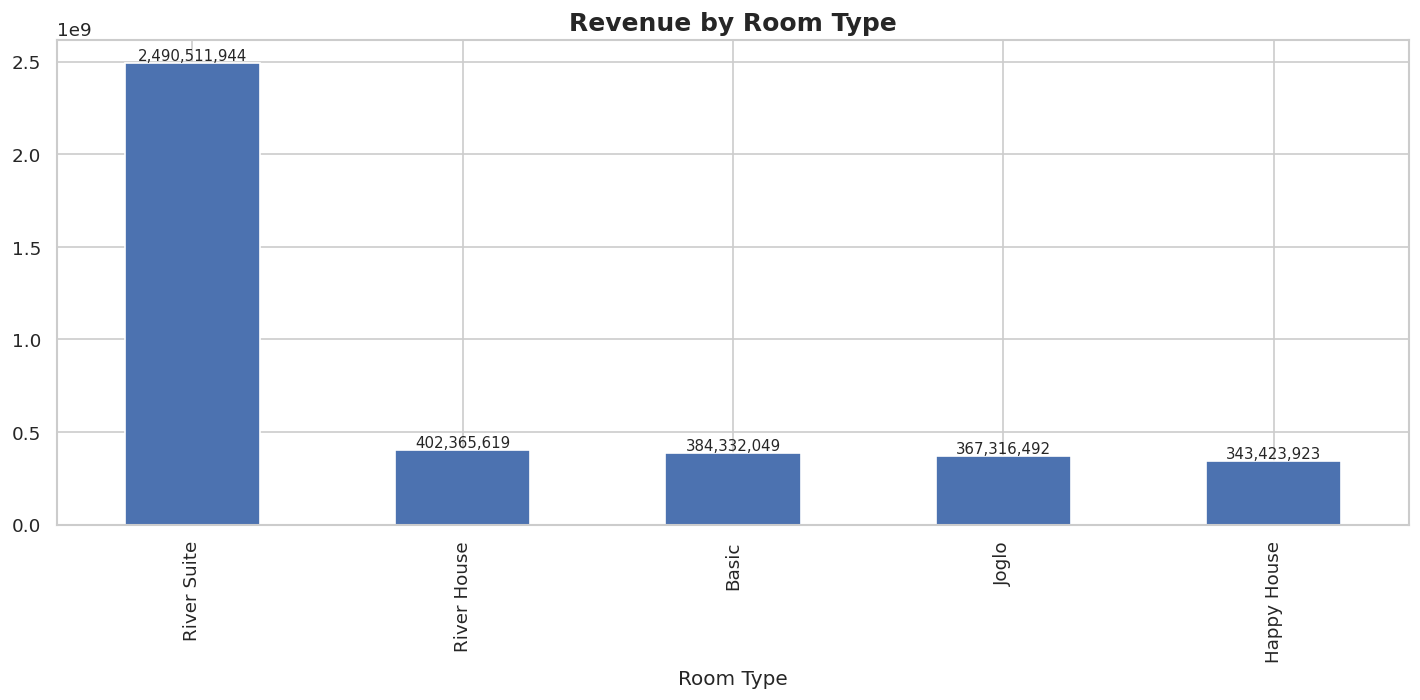

,Room Net,Nights,Folio
Room Type,,,
River Suite,"2,490,511,944",3956,1143
River House,"402,365,619",299,65
Basic,"384,332,049",1004,309
Joglo,"367,316,492",246,61
Happy House,"343,423,923",168,34


In [ ]:
room = plot_room_type(df)

display(

room.style.format({

    "Room Net":"{:,.0f}"

})

)

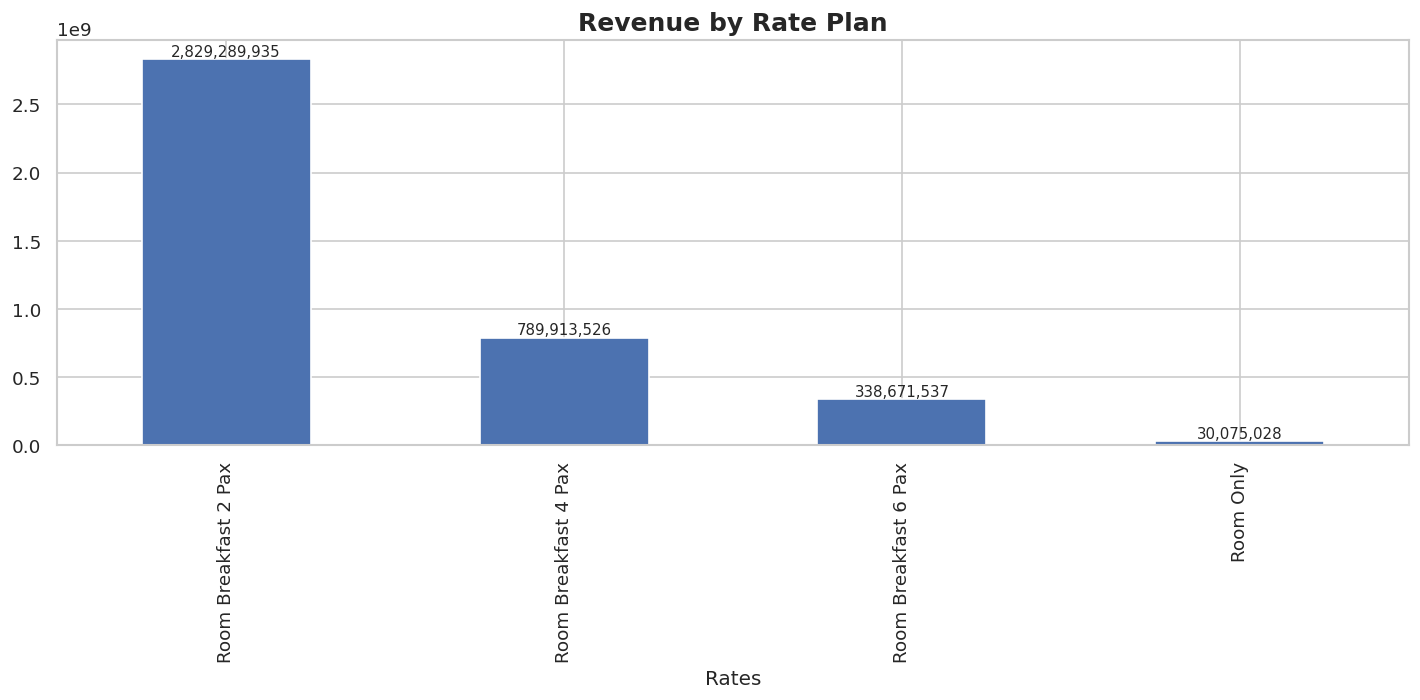

,Room Net,Nights,Folio
Rates,,,
Room Breakfast 2 Pax,"2,829,289,935",4868,1415
Room Breakfast 4 Pax,"789,913,526",545,128
Room Breakfast 6 Pax,"338,671,537",163,33
Room Only,"30,075,028",97,36


In [ ]:
rate = plot_rate(df)

display(

rate.style.format({

    "Room Net":"{:,.0f}"

})

)

In [ ]:
avg = (

    df.groupby("Agent Cleaned")

    .agg(

        Revenue=("Room Net","sum"),

        Booking=("Folio","count")

    )

)

avg["Average Revenue"]=(

    avg["Revenue"]

    /avg["Booking"]

)

avg=avg.sort_values(

    "Average Revenue",

    ascending=False

)

display(

avg.head(20).style.format({

    "Revenue":"{:,.0f}",

    "Average Revenue":"{:,.0f}"

})

)

,Revenue,Booking,Average Revenue
Agent Cleaned,,,
Doku Old (Commission Based),"211,673,722",29,"7,299,094"
Airbnb,"30,044,570",7,"4,292,081"
Doku,"132,983,655",32,"4,155,739"
Not Mapping,"28,423,142",7,"4,060,449"
Expedia,"104,936,289",36,"2,914,897"
DIRECT,"1,360,021,565",540,"2,518,558"
Booking.com,"1,965,494,787",823,"2,388,208"
Agoda,"90,293,935",61,"1,480,228"
WALK IN,"4,632,407",4,"1,158,102"


,Component,Amount
0,Room Charge,"5,732,510,823"
1,Extra Charge,"14,500,000"
2,POS,"1,015,679,849"
3,Rebate,"-11,878,750"
4,Commission,"-588,420,647"
5,Room Net,"3,987,950,027"


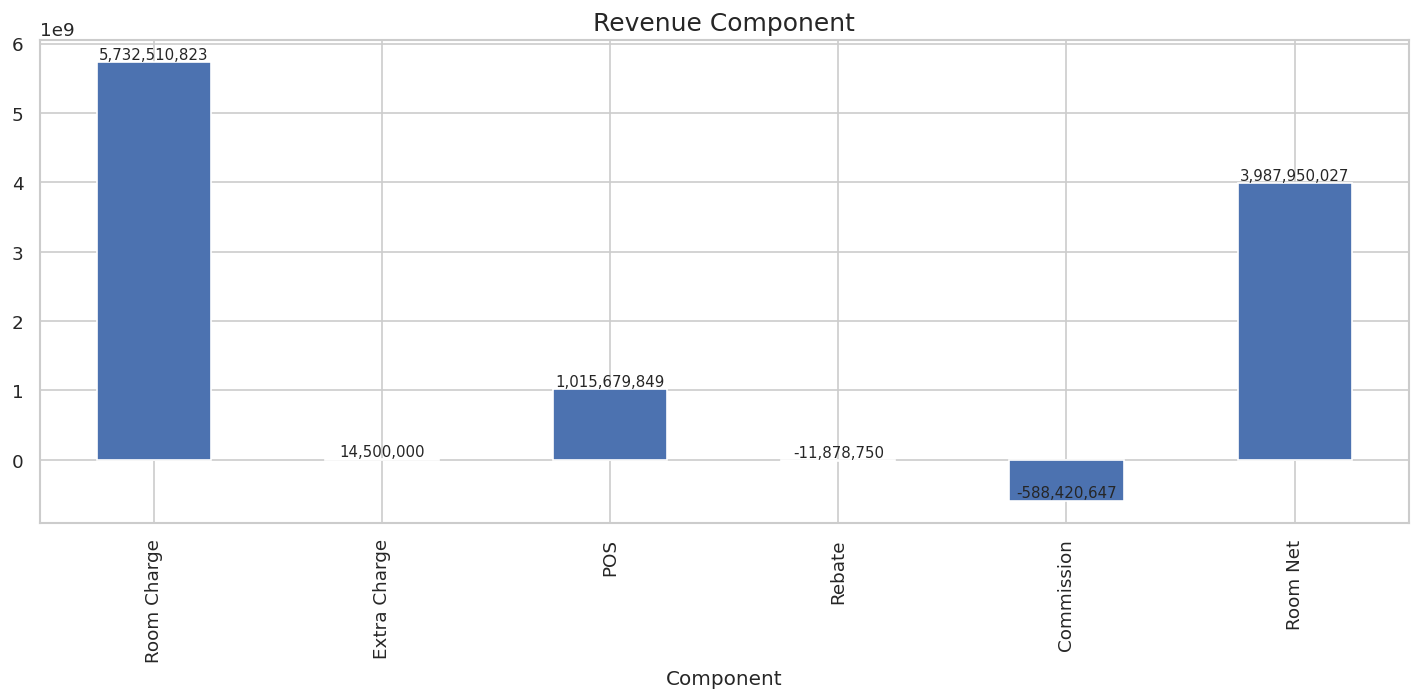

In [ ]:
waterfall = pd.DataFrame({

    "Component":[

        "Room Charge",

        "Extra Charge",

        "POS",

        "Rebate",

        "Commission",

        "Room Net"

    ],

    "Amount":[

        df["Room Charge"].sum(),

        df["Extra Charge"].sum(),

        df["Pos"].sum(),

        -df["Rebate"].sum(),

        -df["Commission"].sum(),

        df["Room Net"].sum()

    ]

})

display(

waterfall.style.format({

    "Amount":"{:,.0f}"

})

)

ax = waterfall.plot.bar(

    x="Component",

    y="Amount",

    legend=False,

    figsize=(12,6)

)

add_value_labels(ax)

plt.title("Revenue Component")

plt.tight_layout()

plt.show()

,Room Net,Cum %
Agent Cleaned,,
Booking.com,"1,965,494,787",49.29%
DIRECT,"1,360,021,565",83.39%
Doku Old (Commission Based),"211,673,722",88.70%
Doku,"132,983,655",92.03%
Expedia,"104,936,289",94.66%
Agoda,"90,293,935",96.93%
C-Trip,"45,809,726",98.08%
Airbnb,"30,044,570",98.83%
Not Mapping,"28,423,142",99.54%


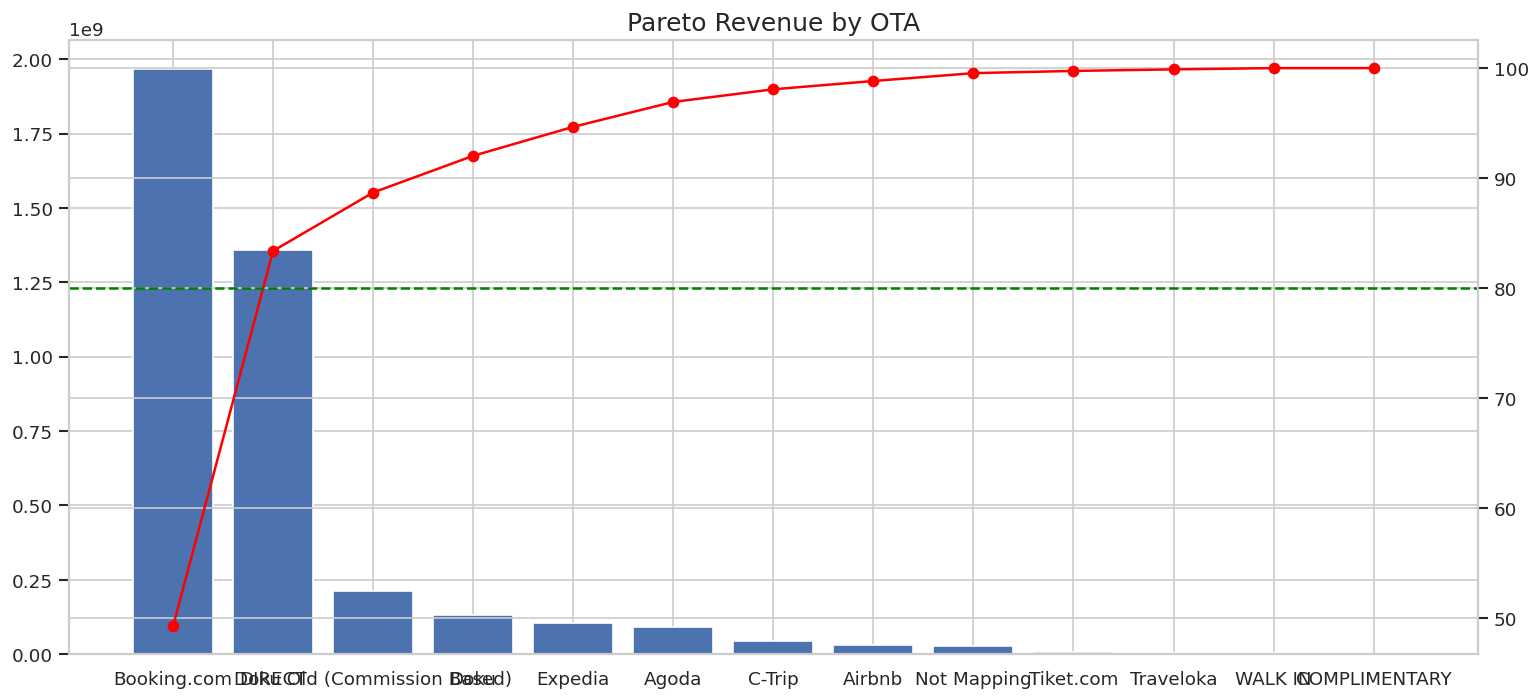

In [ ]:
pareto = (

    df.groupby("Agent Cleaned")["Room Net"]

    .sum()

    .sort_values(ascending=False)

)

pareto = pareto.to_frame()

pareto["Cum %"]=(

    pareto["Room Net"]

    .cumsum()

    /pareto["Room Net"].sum()

)*100

display(

pareto.style.format({

    "Room Net":"{:,.0f}",

    "Cum %":"{:.2f}%"

})

)

fig,ax1=plt.subplots(figsize=(13,6))

ax1.bar(

    pareto.index,

    pareto["Room Net"]

)

ax2=ax1.twinx()

ax2.plot(

    pareto.index,

    pareto["Cum %"],

    color="red",

    marker="o"

)

ax2.axhline(

    80,

    linestyle="--",

    color="green"

)

plt.xticks(rotation=75)

plt.title("Pareto Revenue by OTA")

plt.tight_layout()

plt.show()

In [ ]:
guest=(

    df.groupby("Guest")

    .agg(

        Revenue=("Room Net","sum"),

        Stay=("Nights","sum"),

        Visit=("Folio","count")

    )

    .sort_values(

        "Revenue",

        ascending=False

    )

)

display(

guest.head(20).style.format({

    "Revenue":"{:,.0f}"

})

)

,Revenue,Stay,Visit
Guest,,,
Mrs megan trotterc,"159,759,760",196,14
Mrs Debbra,"130,648,013",172,46
Mr David Solomon,"117,766,831",159,47
Mrs Megan Trotter,"88,030,888",120,10
Jarda Sladek,"50,465,314",56,3
Melanie Ford,"43,748,235",25,2
Michal Gajdosik,"43,323,795",77,14
Mrs Elizabeth Guardian,"32,604,033",40,10
Mr Stephen Handley,"29,517,241",16,1


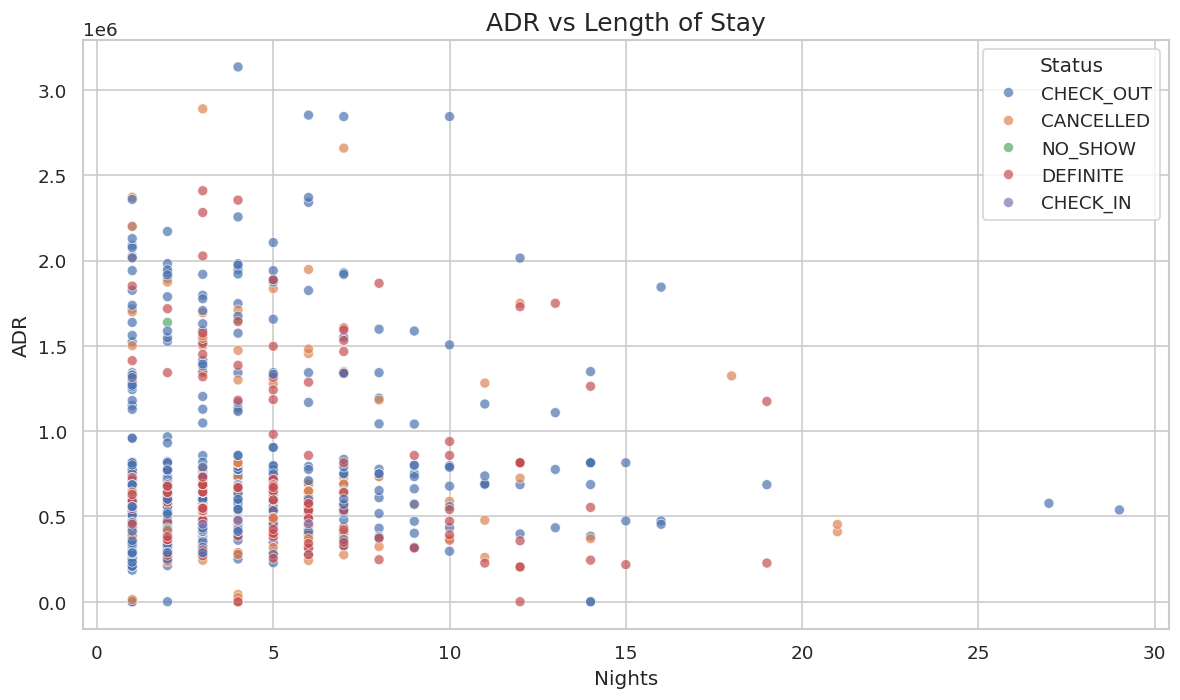

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    data=df,

    x="Nights",

    y="ADR",

    hue="Status",

    alpha=.7

)

plt.title(

    "ADR vs Length of Stay"

)

plt.tight_layout()

plt.show()

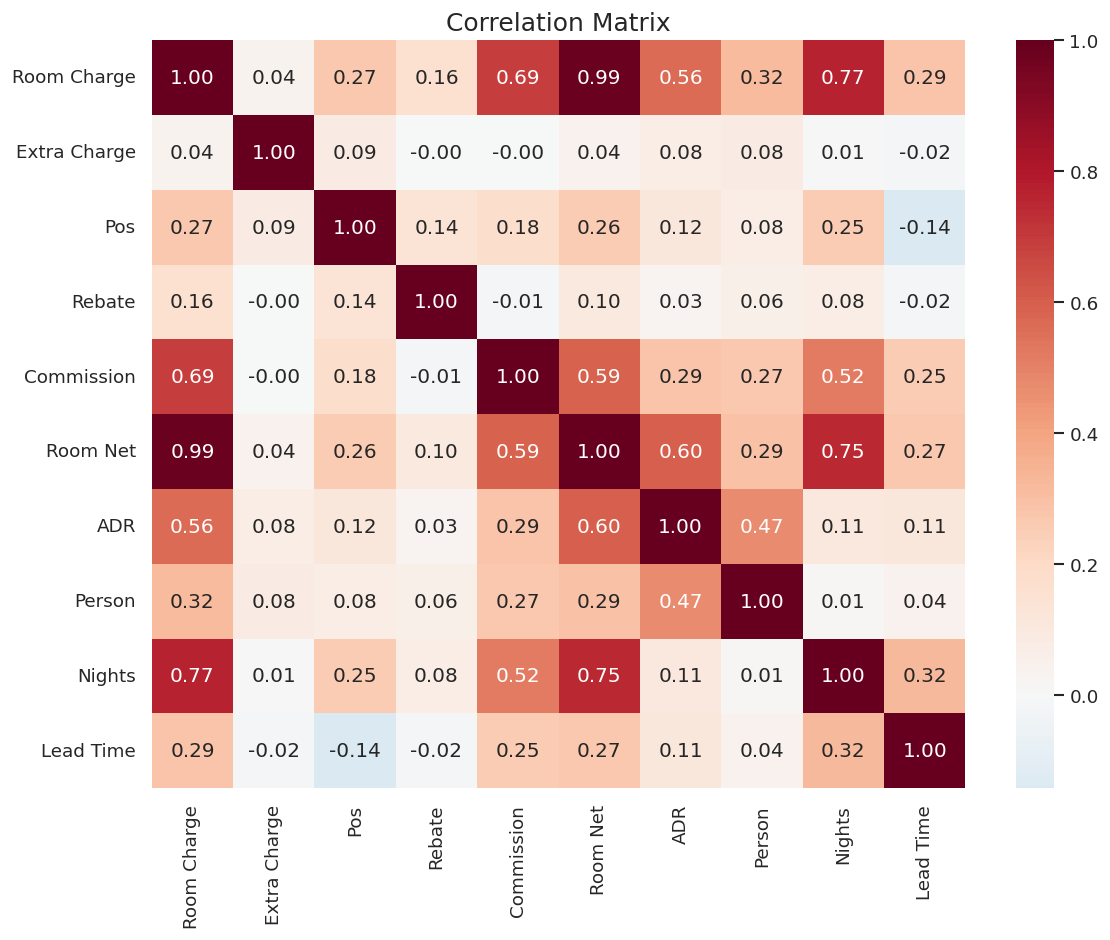

In [ ]:
corr = df[[

    "Room Charge",

    "Extra Charge",

    "Pos",

    "Rebate",

    "Commission",

    "Room Net",

    "ADR",

    "Person",

    "Nights",

    "Lead Time"

]].corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(

    corr,

    annot=True,

    cmap="RdBu_r",

    center=0,

    fmt=".2f"

)

plt.title(

    "Correlation Matrix"

)

plt.tight_layout()

plt.show()

# Guest & Market Analysis

Analisis karakteristik tamu berdasarkan negara asal, jumlah tamu, lama menginap, OTA, dan pola reservasi untuk mengetahui target market hotel.

,Booking,Revenue,Nights,Guest
Country,,,,
Australia,715,"1,991,149,789",2726,1303
Canada,49,"315,720,358",403,99
Indonesia,111,"127,901,899",204,206
Germany,46,"120,394,076",165,99
New Zealand,48,"119,834,947",192,92
United States,45,"102,554,383",132,79
Czech Republic,18,"96,963,840",135,47
France,50,"90,205,352",141,97
United Kingdom,33,"82,745,249",136,59


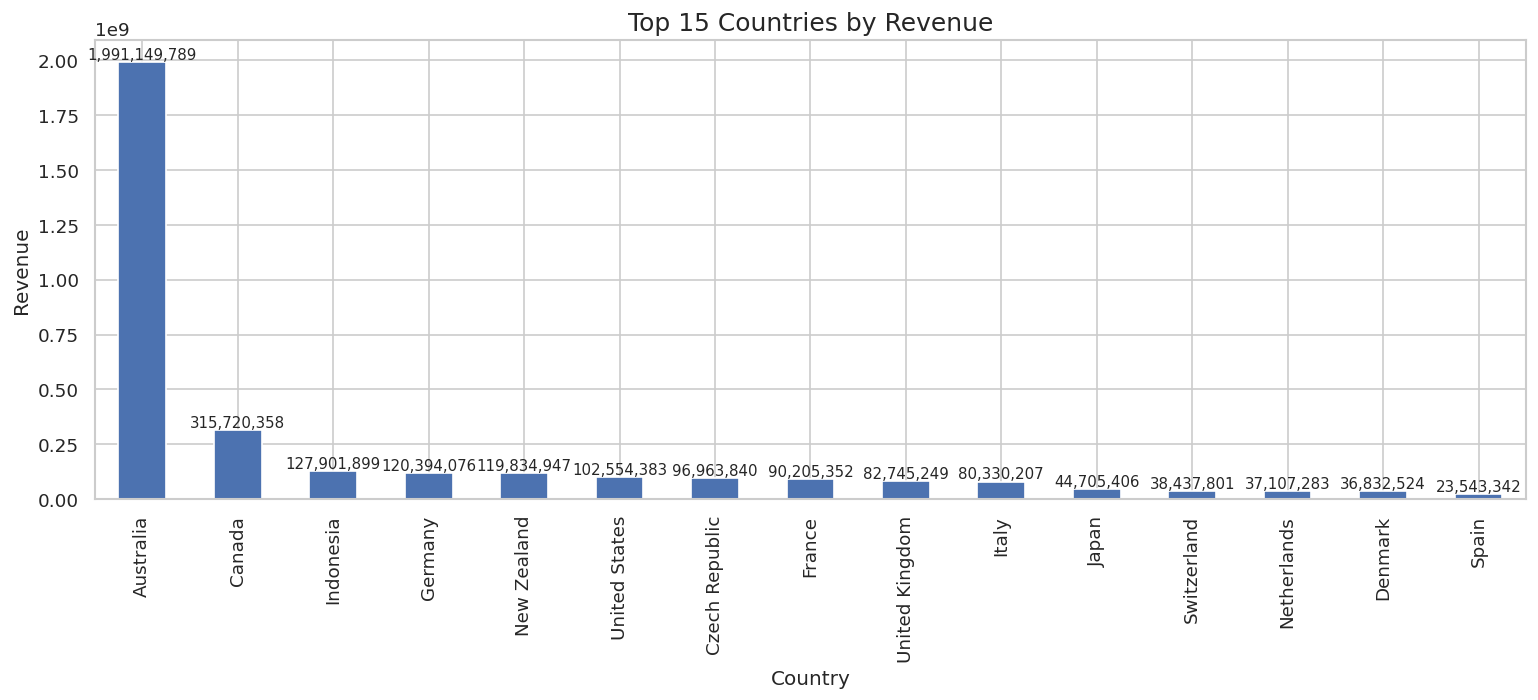

In [ ]:
country_summary = (
    df.groupby("Country")
      .agg(
          Booking=("Folio","count"),
          Revenue=("Room Net","sum"),
          Nights=("Nights","sum"),
          Guest=("Person","sum")
      )
      .sort_values("Revenue",ascending=False)
)

display(
    country_summary.style.format({
        "Revenue":"{:,.0f}"
    })
)

ax = country_summary.head(15)["Revenue"].plot.bar(figsize=(13,6))

add_value_labels(ax)

plt.title("Top 15 Countries by Revenue")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

,AverageStay,Booking
Country,,
Canada,8.224490,49
Denmark,7.700000,10
Czech Republic,7.500000,18
United Kingdom,4.121212,33
New Zealand,4.000000,48
Singapore,3.900000,10
Australia,3.812587,715
Italy,3.647059,34
Germany,3.586957,46


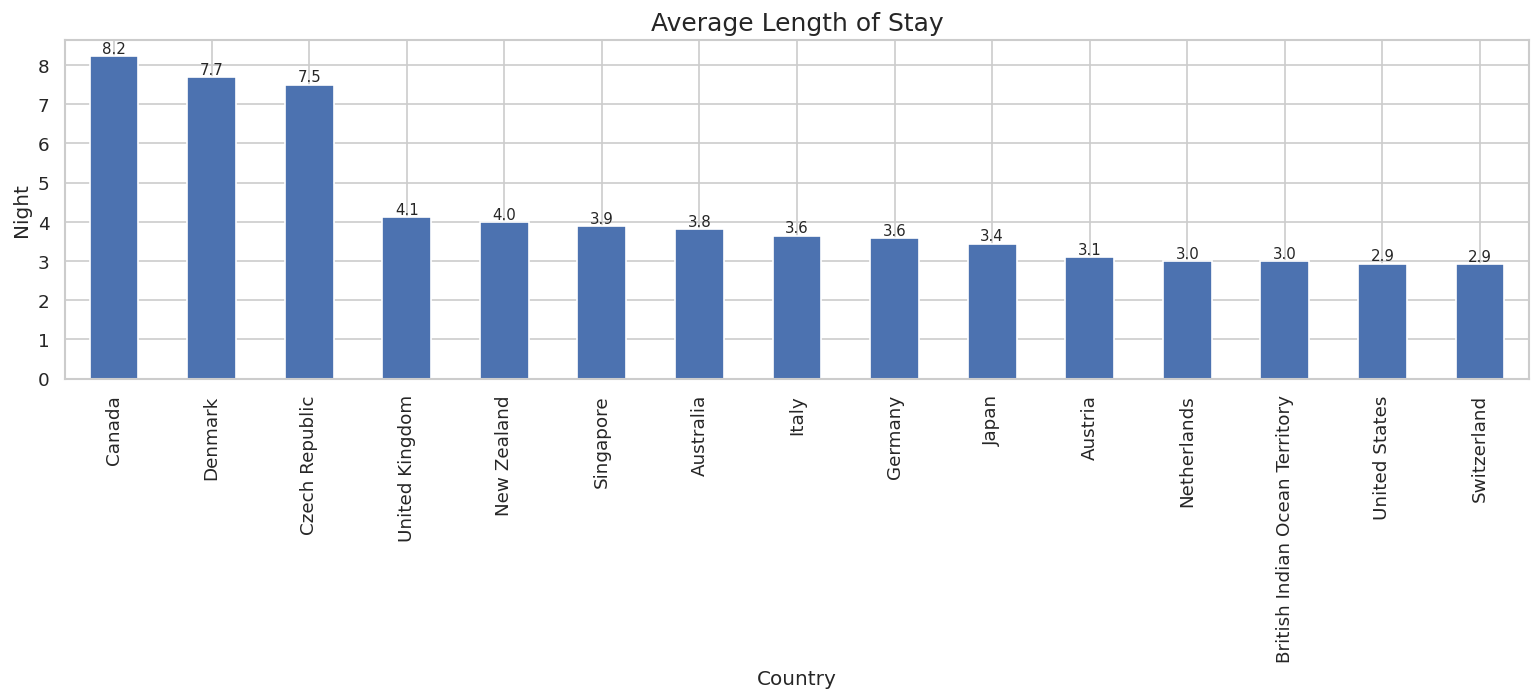

In [ ]:
stay_country = (

    df.groupby("Country")

    .agg(

        AverageStay=("Nights","mean"),

        Booking=("Folio","count")

    )

    .query("Booking>=5")

    .sort_values(

        "AverageStay",

        ascending=False

    )

)

display(

stay_country.head(20)

)

ax = stay_country.head(15)["AverageStay"].plot.bar(figsize=(13,6))

add_value_labels(ax,fmt="{:.1f}")

plt.ylabel("Night")

plt.title("Average Length of Stay")

plt.tight_layout()

plt.show()

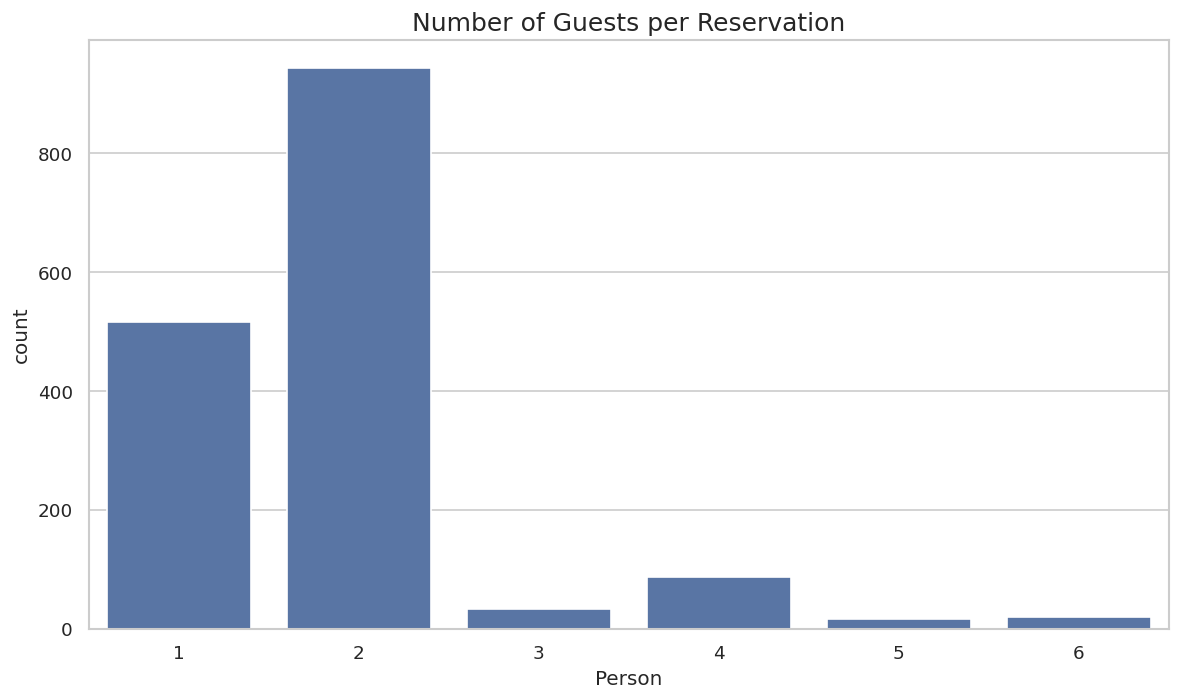

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(

    data=df,

    x="Person"

)

plt.title(

    "Number of Guests per Reservation"

)

plt.tight_layout()

plt.show()

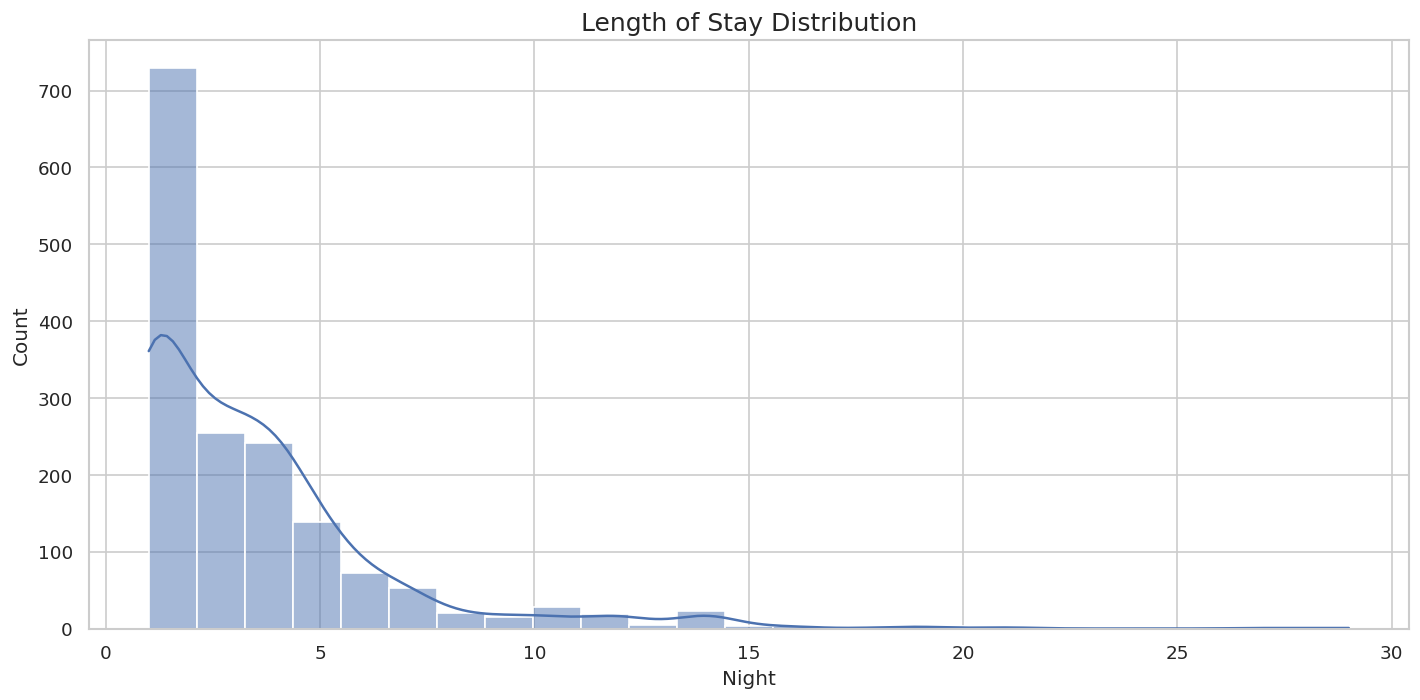

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(

    df["Nights"],

    bins=25,

    kde=True

)

plt.title(

    "Length of Stay Distribution"

)

plt.xlabel("Night")

plt.tight_layout()

plt.show()

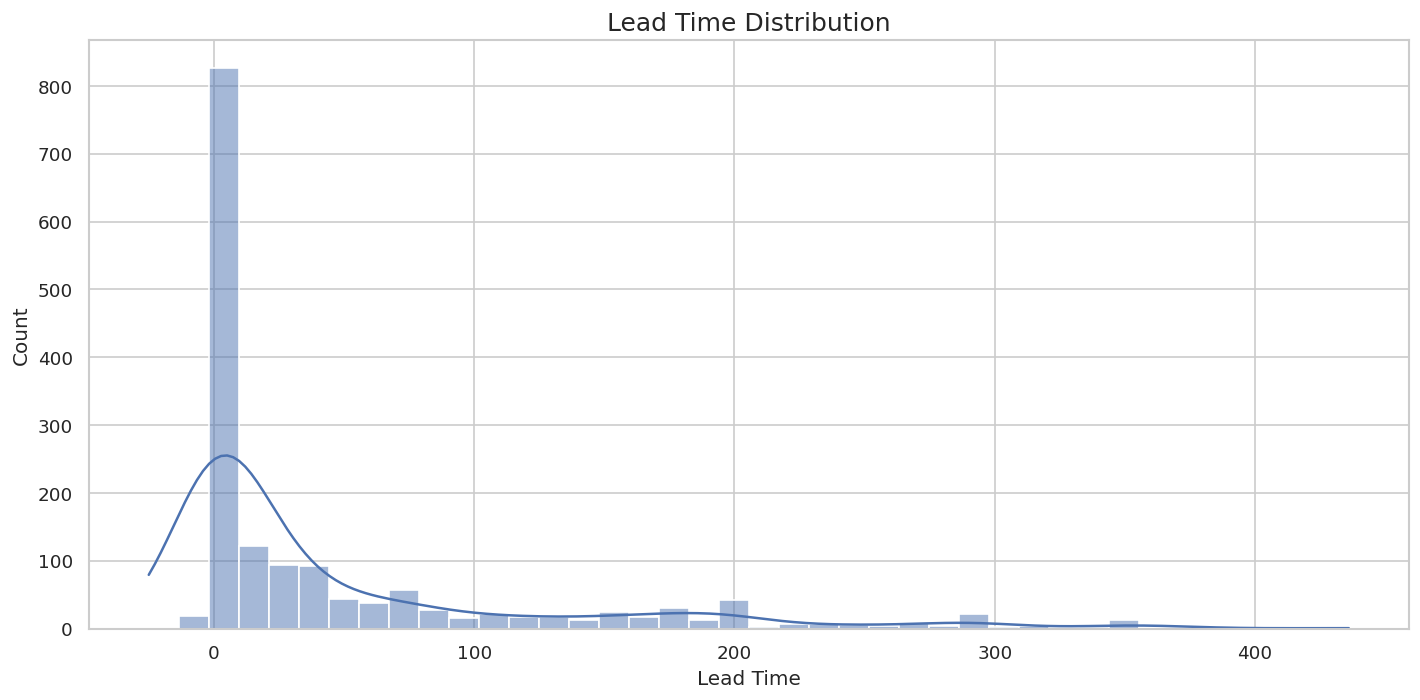

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(

    df["Lead Time"],

    bins=40,

    kde=True

)

plt.title(

    "Lead Time Distribution"

)

plt.tight_layout()

plt.show()

In [ ]:
repeat = (

    df.groupby("Guest")

    .agg(

        Visit=("Folio","count"),

        Revenue=("Room Net","sum"),

        Nights=("Nights","sum")

    )

)

repeat = repeat[

    repeat["Visit"]>1

].sort_values(

    "Visit",

    ascending=False

)

display(

repeat.head(30).style.format({

    "Revenue":"{:,.0f}"

})

)

,Visit,Revenue,Nights
Guest,,,
Mr David Solomon,47,"117,766,831",159
Mrs Debbra,46,"130,648,013",172
Mr Kevin Koeniger,25,"19,305,019",25
Mrs megan trotterc,14,"159,759,760",196
Michal Gajdosik,14,"43,323,795",77
Mrs Debra,11,"29,343,629",44
Mr Chanel E Martin,10,"12,012,012",20
Mrs Elizabeth Guardian,10,"32,604,033",40
cassandra blom,10,"11,770,873",23


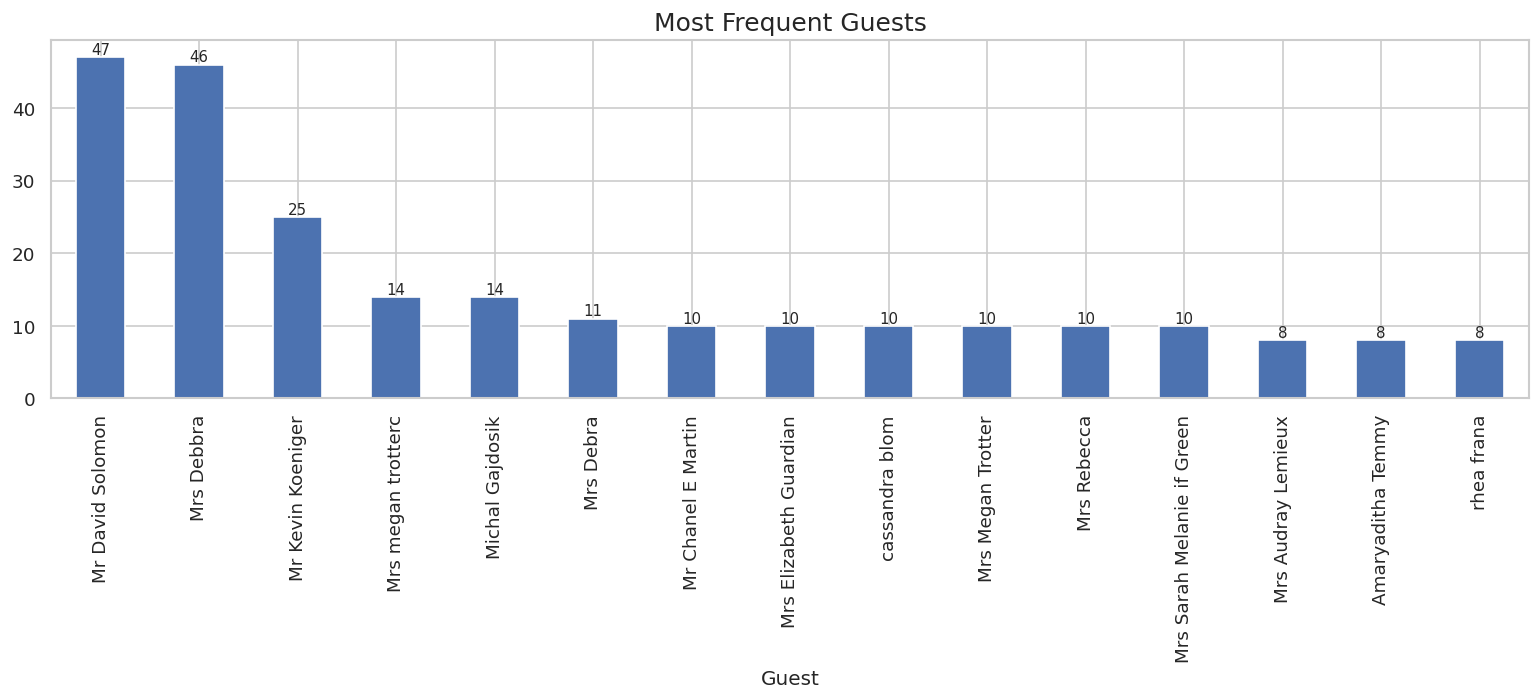

In [ ]:
ax = (

    repeat.head(15)["Visit"]

    .plot.bar(figsize=(13,6))

)

add_value_labels(ax)

plt.title(

    "Most Frequent Guests"

)

plt.tight_layout()

plt.show()

,Booking,Revenue,Nights
Market,,,
Domestic,111,"127,901,899",204
International,1501,"3,860,048,127",5469


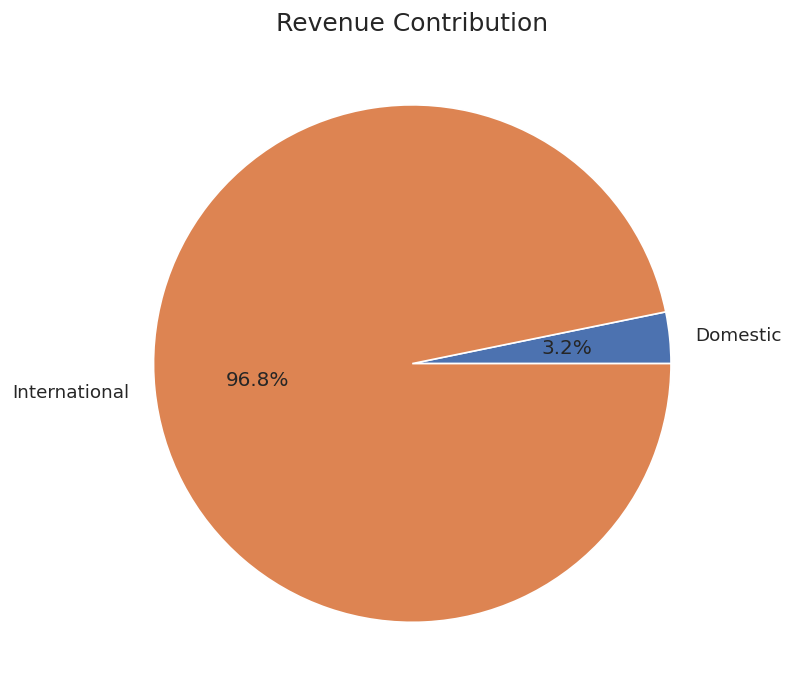

In [ ]:
df["Market"] = np.where(

    df["Country"].fillna("").str.upper()=="INDONESIA",

    "Domestic",

    "International"

)

market = (

    df.groupby("Market")

    .agg(

        Booking=("Folio","count"),

        Revenue=("Room Net","sum"),

        Nights=("Nights","sum")

    )

)

display(

market.style.format({

    "Revenue":"{:,.0f}"

})

)

market["Revenue"].plot.pie(

    autopct="%1.1f%%",

    figsize=(7,7)

)

plt.ylabel("")

plt.title(

    "Revenue Contribution"

)

plt.show()

In [ ]:
guest_value = (

    df.groupby("Guest")

    .agg(

        Revenue=("Room Net","sum"),

        Visit=("Folio","count")

    )

)

guest_value["Revenue per Visit"]=(

    guest_value["Revenue"]

    /guest_value["Visit"]

)

display(

guest_value.sort_values(

    "Revenue per Visit",

    ascending=False

).head(20).style.format({

    "Revenue":"{:,.0f}",

    "Revenue per Visit":"{:,.0f}"

})

)

,Revenue,Visit,Revenue per Visit
Guest,,,
Mr Stephen Handley,"29,517,241",1,"29,517,241"
Mr sean court,"28,448,276",1,"28,448,276"
Mr Christoph Roscheck,"24,181,034",1,"24,181,034"
Melanie Ford,"43,748,235",2,"21,874,118"
Justin Ellegast,"20,760,760",1,"20,760,760"
Mr stan lawrence,"19,913,793",1,"19,913,793"
Adrian Stock,"18,895,969",1,"18,895,969"
Mr Dan Solomon Solomon,"17,120,690",1,"17,120,690"
Jarda Sladek,"50,465,314",3,"16,821,771"


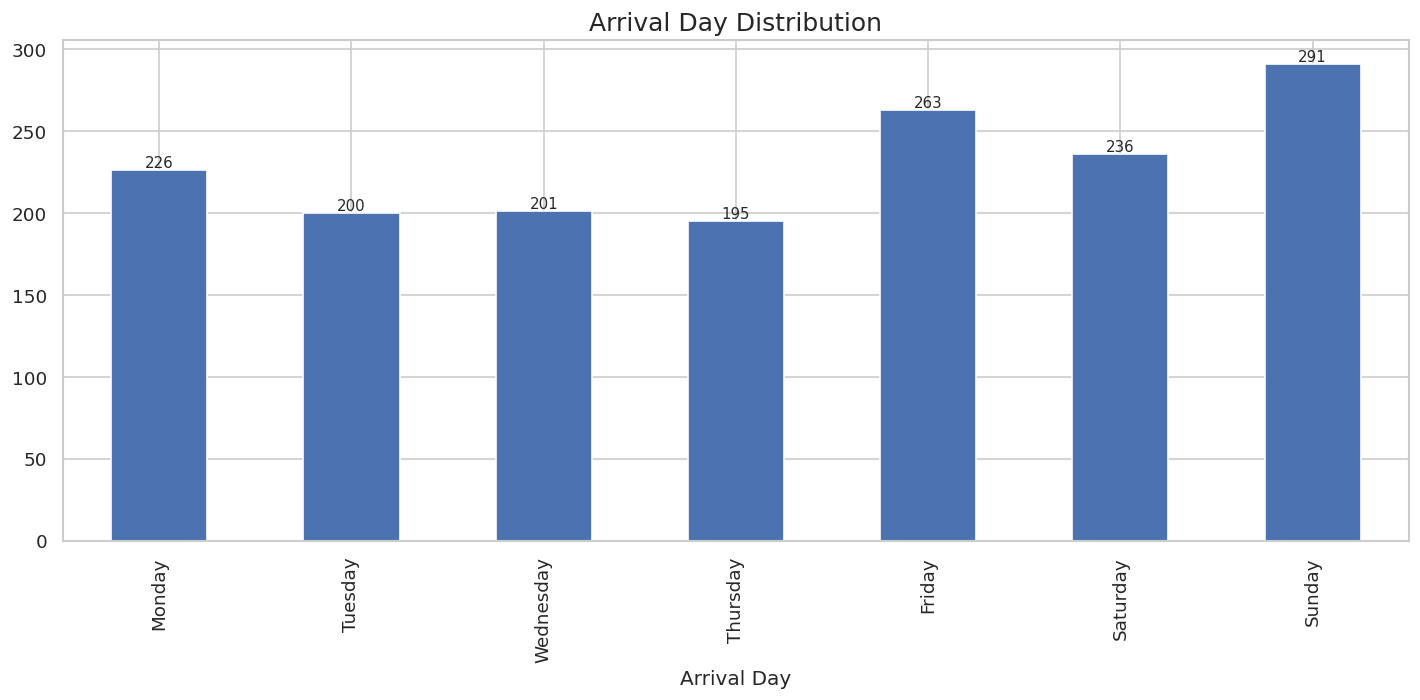

In [ ]:
day = (

    df.groupby("Arrival Day")

    .size()

)

day = day.reindex([

    "Monday",

    "Tuesday",

    "Wednesday",

    "Thursday",

    "Friday",

    "Saturday",

    "Sunday"

])

ax = day.plot.bar(figsize=(12,6))

add_value_labels(ax)

plt.title(

    "Arrival Day Distribution"

)

plt.tight_layout()

plt.show()

In [ ]:
adr_country = (

    df.groupby("Country")

    .agg(

        ADR=("ADR","mean"),

        Booking=("Folio","count")

    )

)

adr_country = adr_country.query(

    "Booking>=5"

)

display(

adr_country.sort_values(

    "ADR",

    ascending=False

).head(20)

)

,ADR,Booking
Country,,
Canada,871856.635714,49
British Indian Ocean Territory,775862.068966,10
Russian Federation,740079.251609,11
Japan,717005.688036,18
United States,714771.892527,45
Australia,700547.309065,715
Czech Republic,677232.562136,18
United Kingdom,647899.878809,33
Germany,644846.232928,46


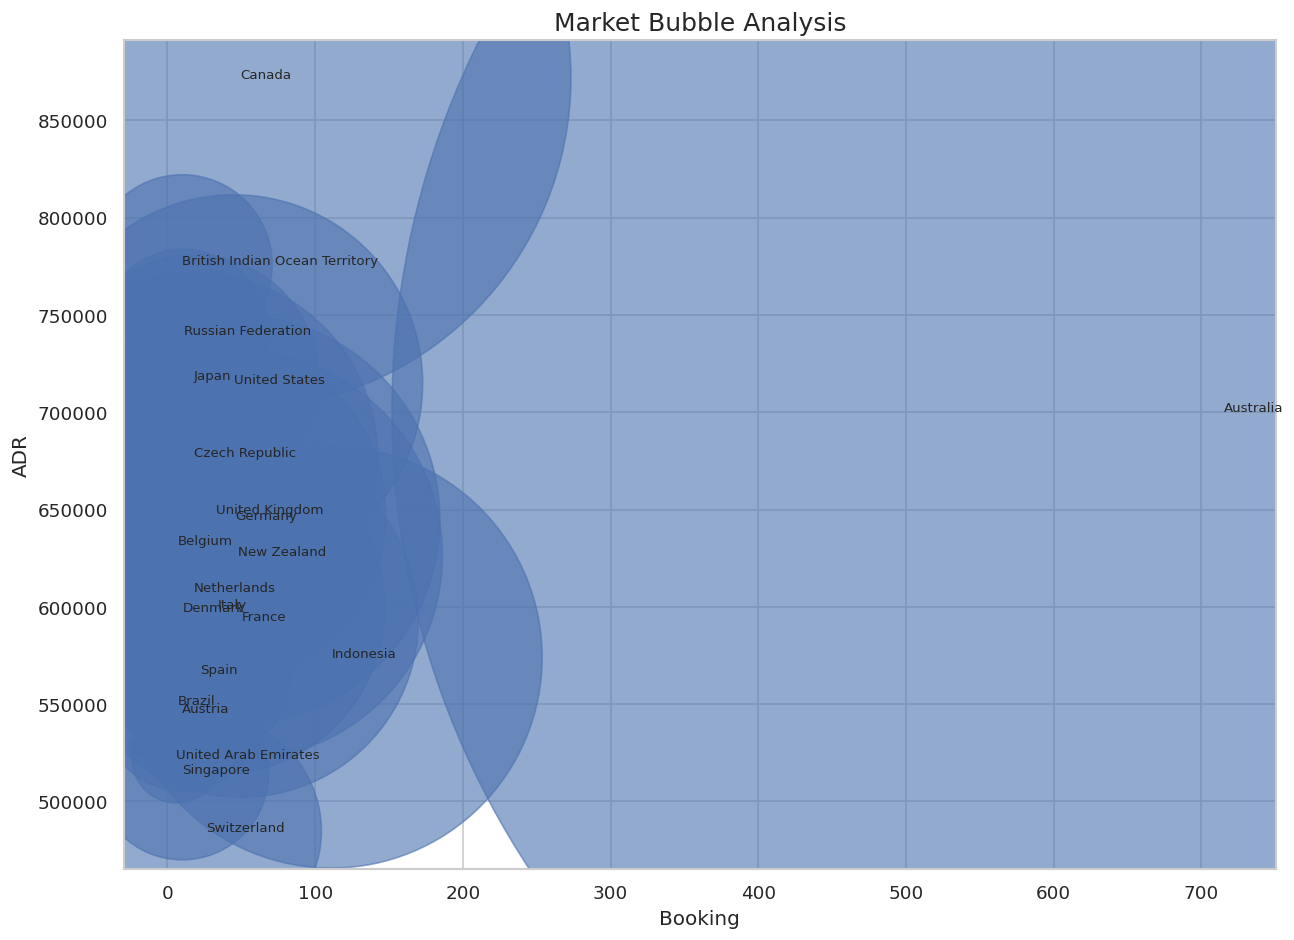

In [ ]:
market = (

    df.groupby("Country")

    .agg(

        Booking=("Folio","count"),

        Revenue=("Room Net","sum"),

        ADR=("ADR","mean")

    )

)

market = market.query(

    "Booking>=5"

)

plt.figure(figsize=(11,8))

plt.scatter(

    market["Booking"],

    market["ADR"],

    s=market["Revenue"]/2000,

    alpha=.6

)

for i in market.index:

    plt.text(

        market.loc[i,"Booking"],

        market.loc[i,"ADR"],

        i,

        fontsize=8

    )

plt.xlabel("Booking")

plt.ylabel("ADR")

plt.title(

    "Market Bubble Analysis"

)

plt.tight_layout()

plt.show()

In [ ]:
guest_segment = df.copy()

guest_segment["LOS Group"] = pd.cut(

    guest_segment["Nights"],

    bins=[0,1,3,7,14,30],

    labels=[

        "1",

        "2-3",

        "4-7",

        "8-14",

        ">14"

    ]

)

summary = (

    guest_segment.groupby("LOS Group")

    .agg(

        Booking=("Folio","count"),

        Revenue=("Room Net","sum"),

        ADR=("ADR","mean")

    )

)

display(

summary.style.format({

    "Revenue":"{:,.0f}",

    "ADR":"{:,.0f}"

})

)

,Booking,Revenue,ADR
LOS Group,,,
1,466,"285,915,518","613,553"
2-3,518,"831,295,152","635,281"
4-7,505,"1,790,898,762","724,088"
8-14,109,"900,019,351","758,110"
>14,14,"179,821,243","690,837"


In [ ]:
print("="*60)
print("GUEST INSIGHT")
print("="*60)

print(f"Top Country        : {country_summary.index[0]}")
print(f"Top Agent          : {top_agent.index[0]}")
print(f"Top Room Type      : {room.index[0]}")
print(f"Top Rate Plan      : {rate.index[0]}")
print(f"Repeat Guests      : {len(repeat)}")
print(f"Average Stay       : {df['Nights'].mean():.2f} Nights")
print(f"Average ADR        : {df['ADR'].mean():,.0f}")
print(f"Cancellation Rate  : {(df.Status=='CANCELLED').mean()*100:.2f}%")
print("="*60)

GUEST INSIGHT
Top Country        : Australia
Top Agent          : Booking.com
Top Room Type      : River Suite
Top Rate Plan      : Room Breakfast 2 Pax
Repeat Guests      : 281
Average Stay       : 3.52 Nights
Average ADR        : 665,609
Cancellation Rate  : 16.81%


# OTA Performance Dashboard

Analisis performa setiap Online Travel Agent (OTA) berdasarkan booking, revenue, ADR, lama menginap, commission, cancellation rate, dan kontribusi revenue.

In [ ]:
ota = (
    df.groupby("Agent Cleaned")
    .agg(
        Booking=("Folio","count"),
        Revenue=("Room Net","sum"),
        Nights=("Nights","sum"),
        ADR=("ADR","mean"),
        Guest=("Person","sum"),
        Commission=("Commission","sum"),
        Cancel=("Status", lambda x: (x=="CANCELLED").sum())
    )
)

ota["Cancellation Rate"] = (
    ota["Cancel"] / ota["Booking"]
) * 100

ota["Average Stay"] = (
    ota["Nights"] / ota["Booking"]
)

ota = ota.sort_values(
    "Revenue",
    ascending=False
)

display(
    ota.style.format({
        "Revenue":"{:,.0f}",
        "ADR":"{:,.0f}",
        "Commission":"{:,.0f}",
        "Cancellation Rate":"{:.2f}%",
        "Average Stay":"{:.2f}"
    })
) #BUATKAN MONTHLY 

,Booking,Revenue,Nights,ADR,Guest,Commission,Cancel,Cancellation Rate,Average Stay
Agent Cleaned,,,,,,,,,
Booking.com,823,"1,965,494,787",3079,"608,819",1587,"576,144,465",134,16.28%,3.74
DIRECT,540,"1,360,021,565",1797,"729,542",946,0,110,20.37%,3.33
Doku Old (Commission Based),29,"211,673,722",176,"1,140,638",70,"6,858,030",4,13.79%,6.07
Doku,32,"132,983,655",145,"999,568",57,0,0,0.00%,4.53
Expedia,36,"104,936,289",119,"805,542",71,"4,021,369",0,0.00%,3.31
Agoda,61,"90,293,935",151,"591,961",122,"1,396,783",14,22.95%,2.48
C-Trip,49,"45,809,726",102,"476,360",98,0,1,2.04%,2.08
Airbnb,7,"30,044,570",32,"913,116",14,0,2,28.57%,4.57
Not Mapping,7,"28,423,142",27,"892,927",17,0,2,28.57%,3.86


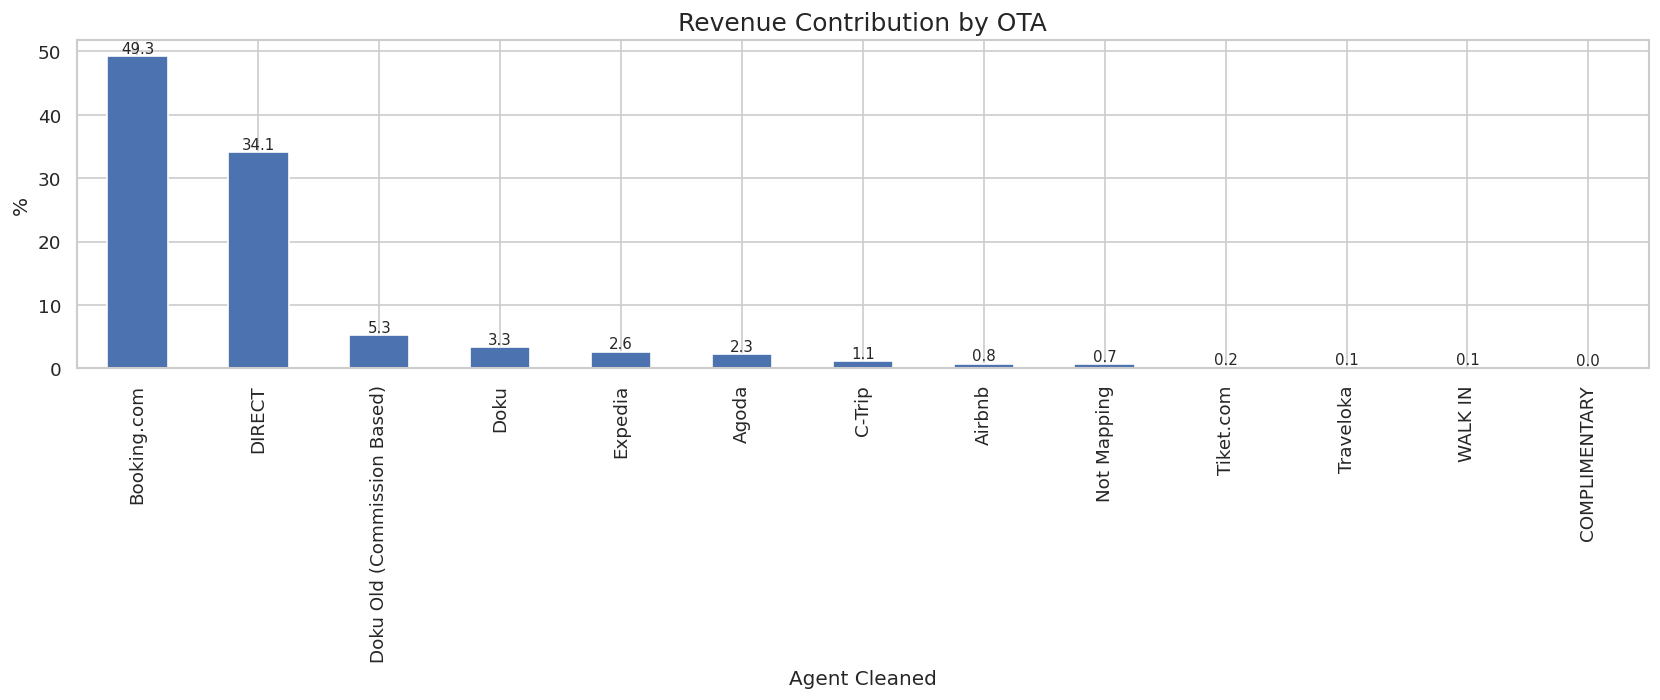

In [ ]:
ota["Contribution (%)"] = (
    ota["Revenue"] /
    ota["Revenue"].sum()
) * 100

ax = ota["Contribution (%)"].plot.bar(figsize=(14,6))

add_value_labels(ax, fmt="{:.1f}")

plt.title("Revenue Contribution by OTA")

plt.ylabel("%")

plt.tight_layout()

plt.show()

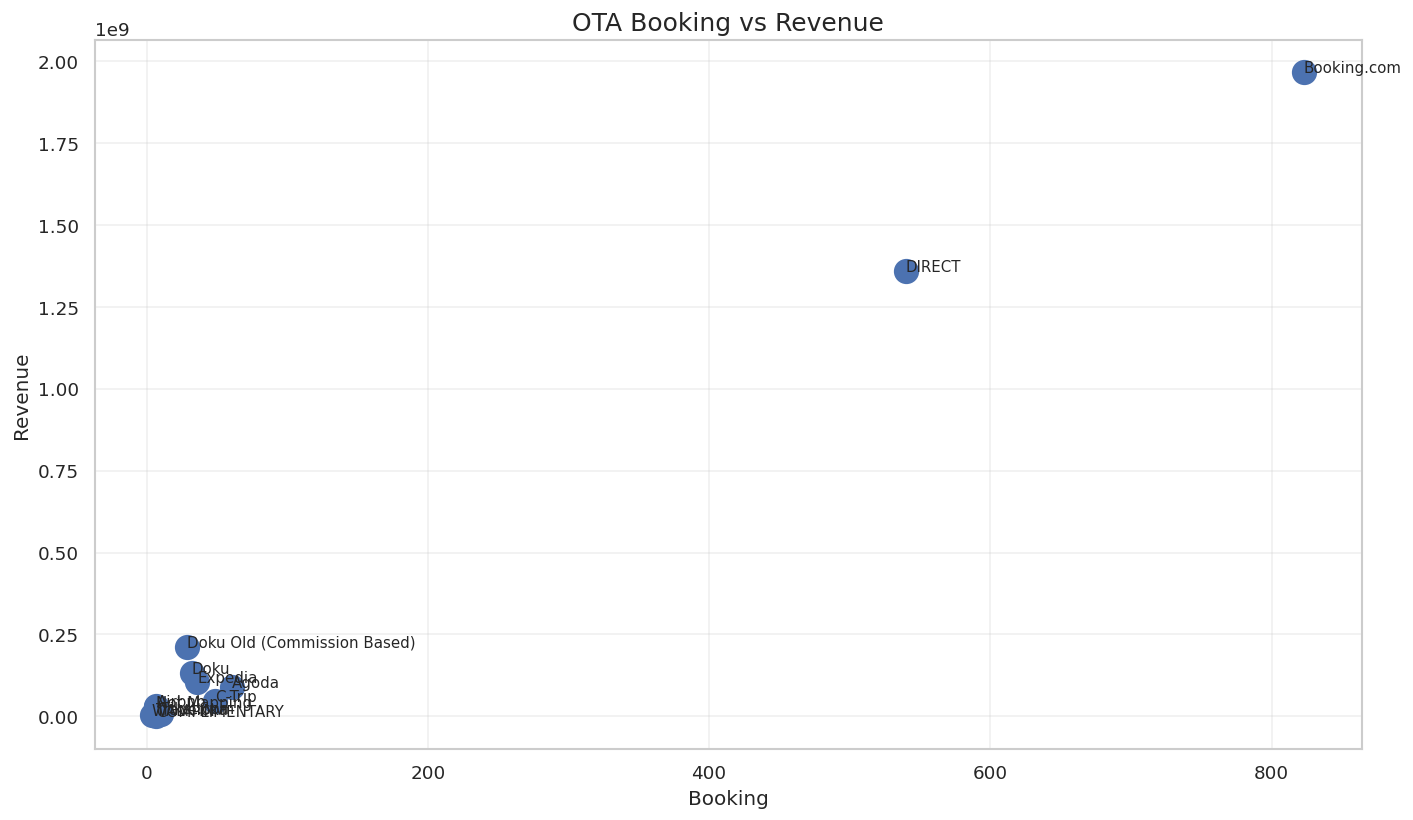

In [ ]:
plt.figure(figsize=(12,7))

plt.scatter(
    ota["Booking"],
    ota["Revenue"],
    s=200
)

for i in ota.index:
    plt.text(
        ota.loc[i,"Booking"],
        ota.loc[i,"Revenue"],
        i,
        fontsize=9
    )

plt.xlabel("Booking")

plt.ylabel("Revenue")

plt.title("OTA Booking vs Revenue")

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

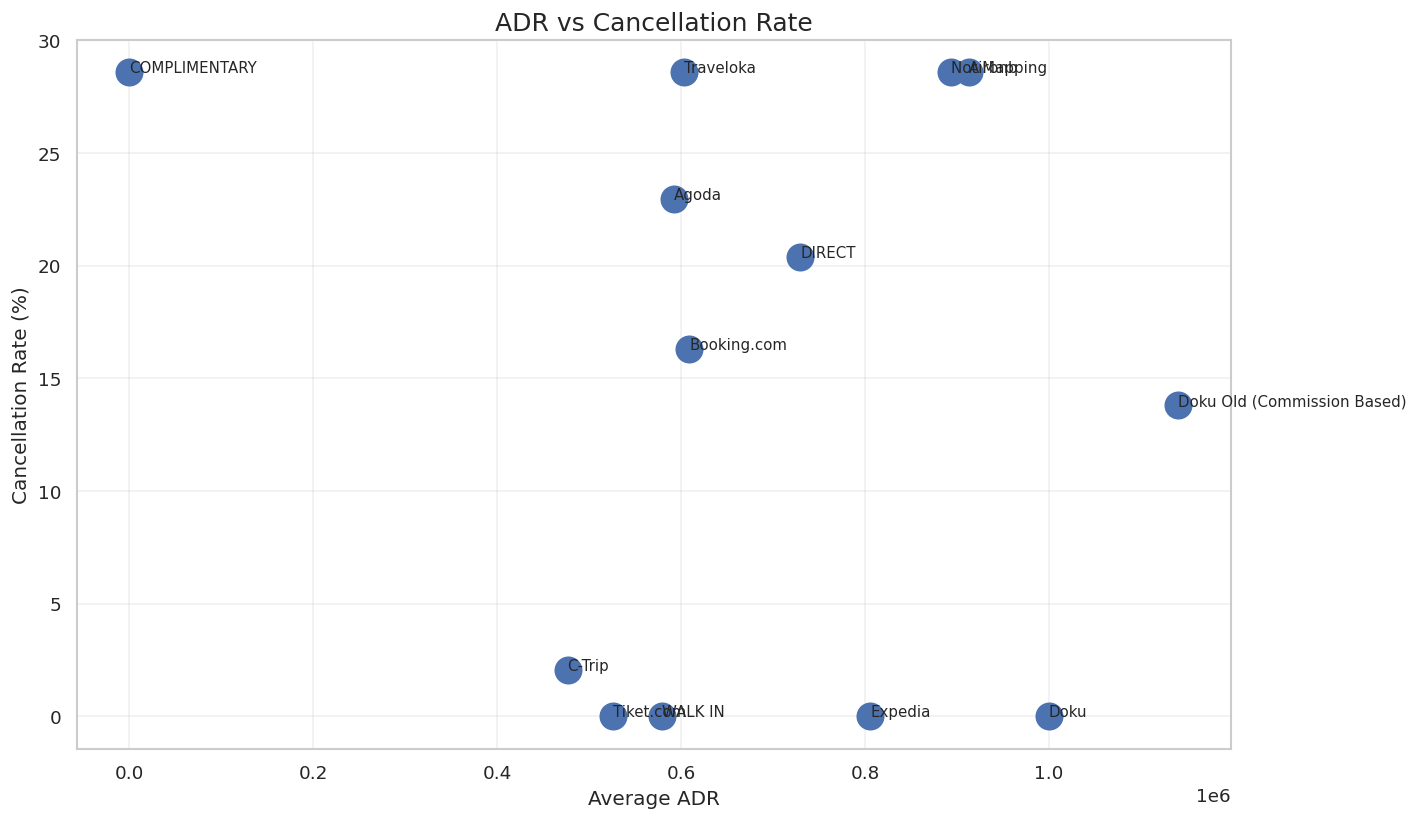

In [ ]:
plt.figure(figsize=(12,7))

plt.scatter(
    ota["ADR"],
    ota["Cancellation Rate"],
    s=250
)

for i in ota.index:
    plt.text(
        ota.loc[i,"ADR"],
        ota.loc[i,"Cancellation Rate"],
        i,
        fontsize=9
    )

plt.xlabel("Average ADR")

plt.ylabel("Cancellation Rate (%)")

plt.title("ADR vs Cancellation Rate")

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

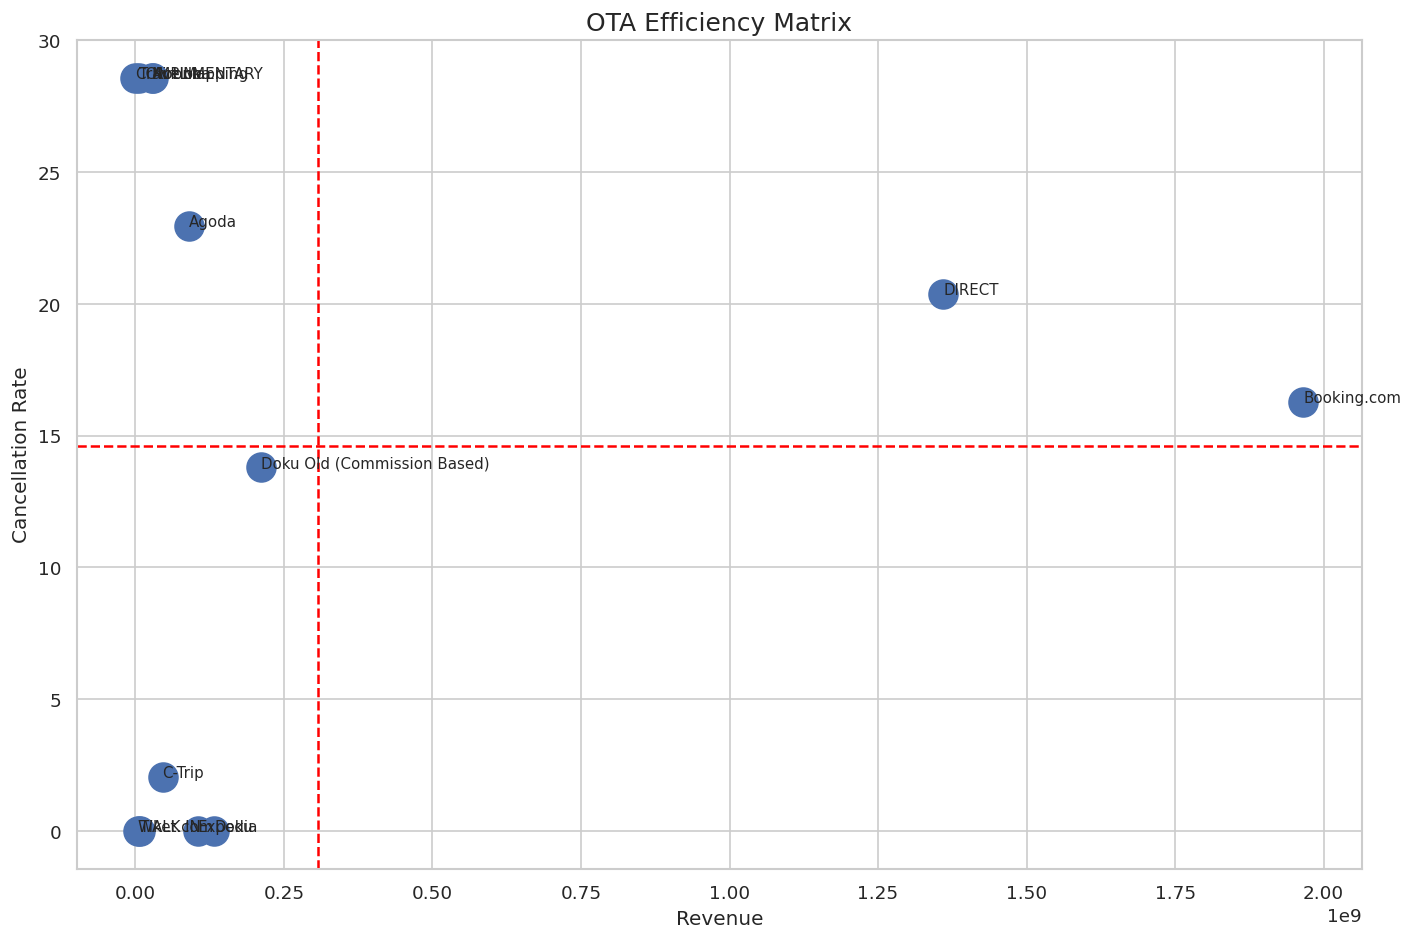

In [ ]:
plt.figure(figsize=(12,8))

plt.scatter(
    ota["Revenue"],
    ota["Cancellation Rate"],
    s=300
)

avg_rev = ota["Revenue"].mean()
avg_cancel = ota["Cancellation Rate"].mean()

plt.axvline(avg_rev,color="red",linestyle="--")
plt.axhline(avg_cancel,color="red",linestyle="--")

for i in ota.index:
    plt.text(
        ota.loc[i,"Revenue"],
        ota.loc[i,"Cancellation Rate"],
        i,
        fontsize=9
    )

plt.xlabel("Revenue")

plt.ylabel("Cancellation Rate")

plt.title("OTA Efficiency Matrix")

plt.tight_layout()

plt.show()

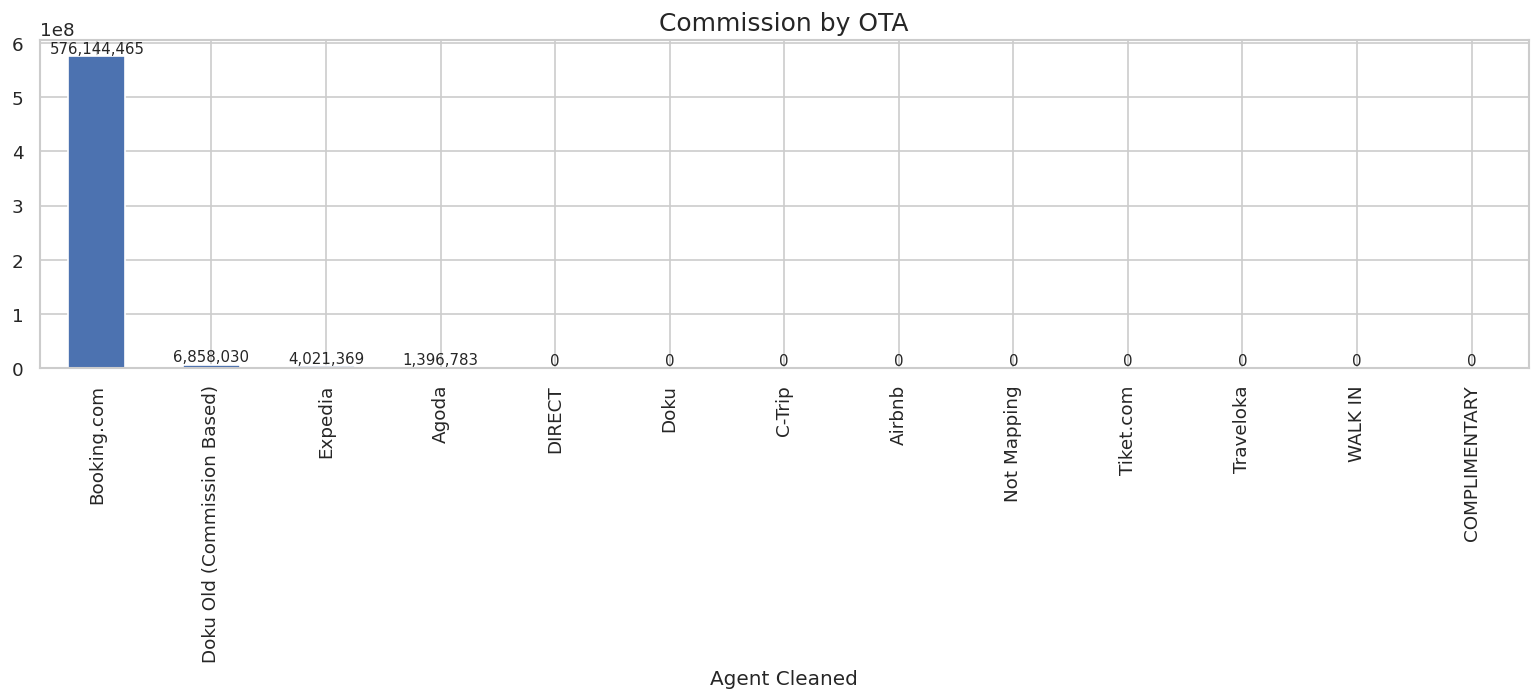

In [ ]:
commission = ota.sort_values(
    "Commission",
    ascending=False
)

ax = commission["Commission"].plot.bar(figsize=(13,6))

add_value_labels(ax)

plt.title("Commission by OTA")

plt.tight_layout()

plt.show()

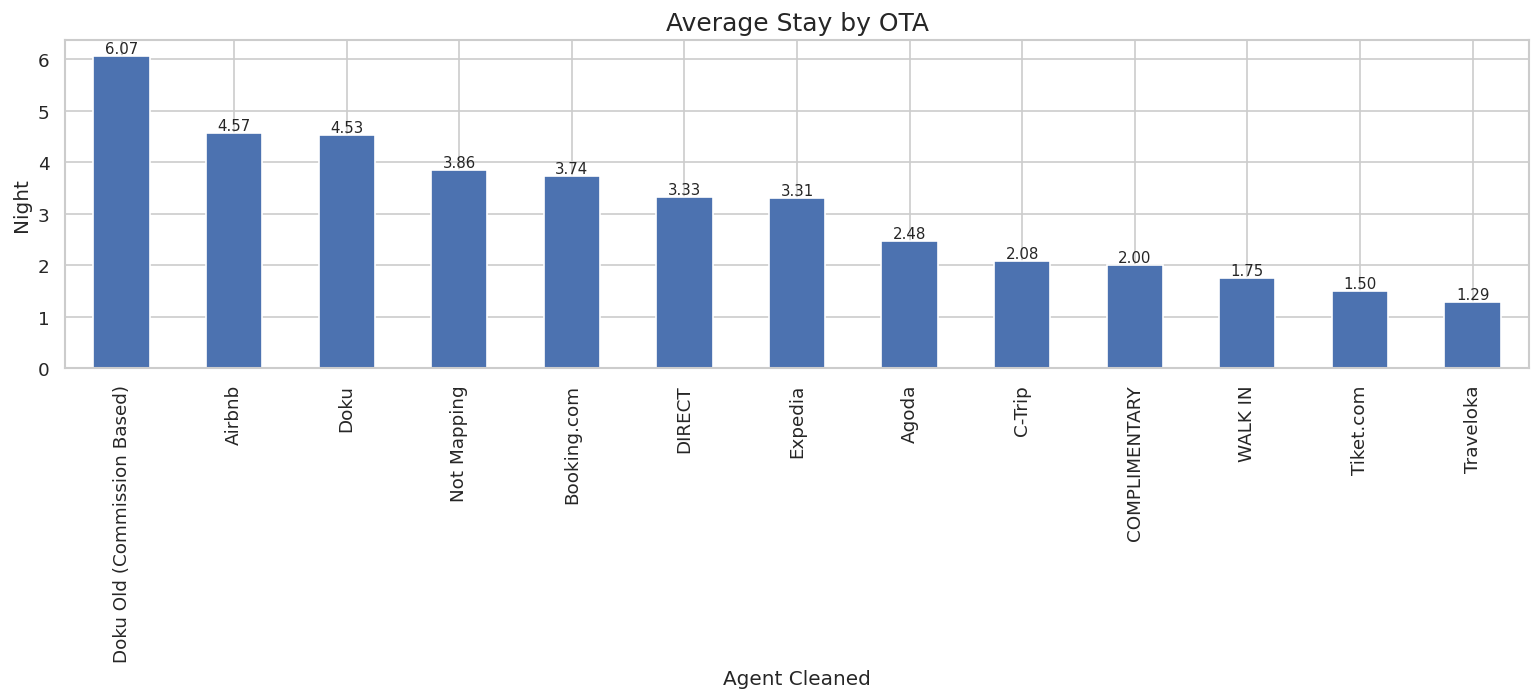

In [ ]:
ax = ota.sort_values(
    "Average Stay",
    ascending=False
)["Average Stay"].plot.bar(figsize=(13,6))

add_value_labels(ax, fmt="{:.2f}")

plt.ylabel("Night")

plt.title("Average Stay by OTA")

plt.tight_layout()

plt.show()

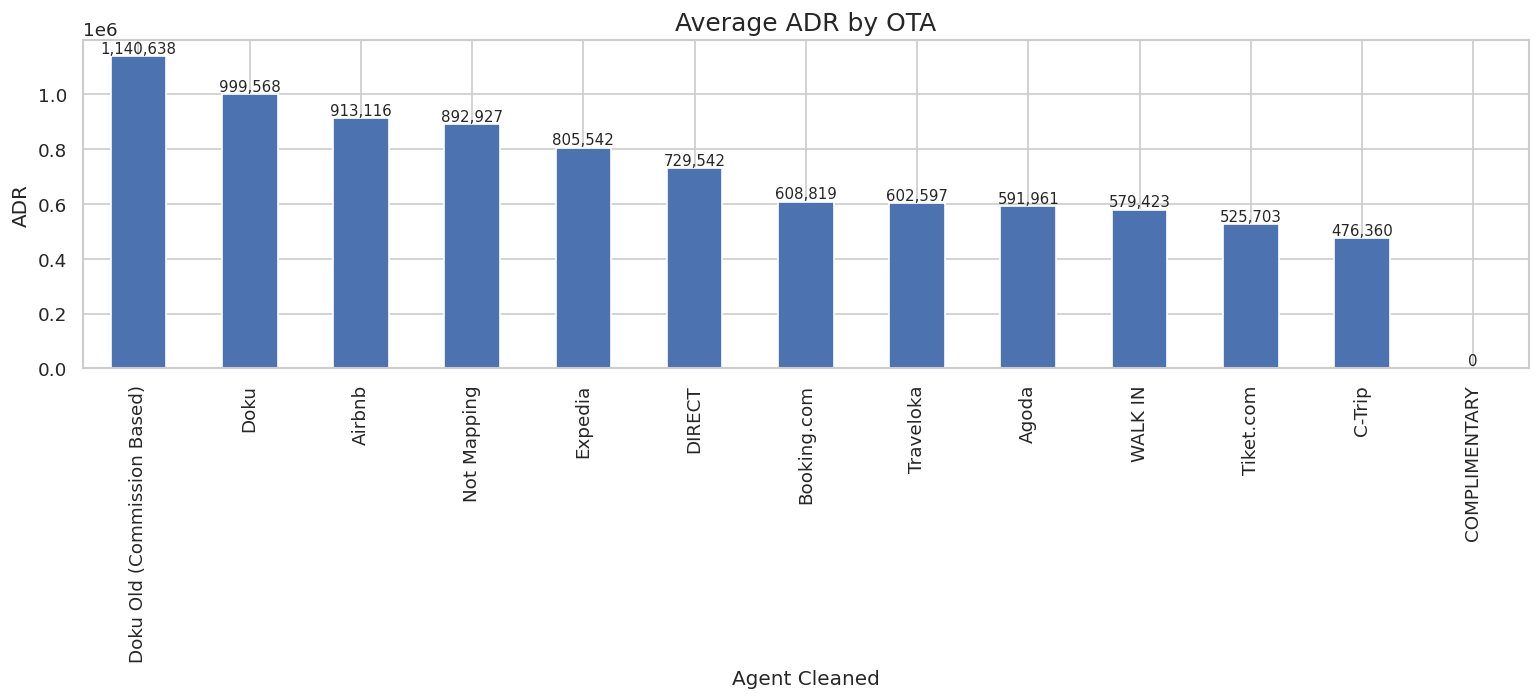

In [ ]:
ax = ota.sort_values(
    "ADR",
    ascending=False
)["ADR"].plot.bar(figsize=(13,6))

add_value_labels(ax)

plt.ylabel("ADR")

plt.title("Average ADR by OTA")

plt.tight_layout()

plt.show()

In [ ]:
ota["Revenue per Night"] = (
    ota["Revenue"] /
    ota["Nights"]
)

display(
    ota.sort_values(
        "Revenue per Night",
        ascending=False
    ).style.format({
        "Revenue per Night":"{:,.0f}"
    })
)

,Booking,Revenue,Nights,ADR,Guest,Commission,Cancel,Cancellation Rate,Average Stay,Contribution (%),Revenue per Night
Agent Cleaned,,,,,,,,,,,
Doku Old (Commission Based),29,211673722.218524,176,1140637.763283,70,6858030.000000,4,13.793103,6.068966,5.307833,"1,202,692"
Not Mapping,7,28423141.999142,27,892927.172070,17,0.000000,2,28.571429,3.857143,0.712726,"1,052,709"
Airbnb,7,30044570.263983,32,913116.135831,14,0.000000,2,28.571429,4.571429,0.753384,"938,893"
Doku,32,132983655.083655,145,999567.935282,57,0.000000,0,0.000000,4.531250,3.334637,"917,129"
Expedia,36,104936288.518277,119,805542.130497,71,4021369.160000,0,0.000000,3.305556,2.631334,"881,818"
DIRECT,540,1360021565.372265,1797,729542.044766,946,0.000000,110,20.370370,3.327778,34.103275,"756,829"
WALK IN,4,4632407.284131,7,579423.142354,9,0.000000,0,0.000000,1.750000,0.116160,"661,772"
Booking.com,823,1965494786.741699,3079,608818.578280,1587,576144464.831525,134,16.281896,3.741191,49.285843,"638,355"
Traveloka,7,5562796.224796,9,602597.168597,16,0.000000,2,28.571429,1.285714,0.139490,"618,088"


In [ ]:
ranking = ota.copy()

ranking["Revenue Rank"] = ranking["Revenue"].rank(
    ascending=False
)

ranking["Booking Rank"] = ranking["Booking"].rank(
    ascending=False
)

ranking["ADR Rank"] = ranking["ADR"].rank(
    ascending=False
)

ranking["Cancellation Rank"] = ranking["Cancellation Rate"].rank()

display(ranking)

,Booking,Revenue,Nights,ADR,Guest,Commission,Cancel,Cancellation Rate,Average Stay,Contribution (%),Revenue per Night,Revenue Rank,Booking Rank,ADR Rank,Cancellation Rank
Agent Cleaned,,,,,,,,,,,,,,,
Booking.com,823,1.965495e+09,3079,6.088186e+05,1587,5.761445e+08,134,16.281896,3.741191,49.285843,6.383549e+05,1.0,1.0,7.0,7.0
DIRECT,540,1.360022e+09,1797,7.295420e+05,946,0.000000e+00,110,20.370370,3.327778,34.103275,7.568289e+05,2.0,2.0,6.0,8.0
Doku Old (Commission Based),29,2.116737e+08,176,1.140638e+06,70,6.858030e+06,4,13.793103,6.068966,5.307833,1.202692e+06,3.0,7.0,1.0,6.0
Doku,32,1.329837e+08,145,9.995679e+05,57,0.000000e+00,0,0.000000,4.531250,3.334637,9.171287e+05,4.0,6.0,2.0,2.5
Expedia,36,1.049363e+08,119,8.055421e+05,71,4.021369e+06,0,0.000000,3.305556,2.631334,8.818176e+05,5.0,5.0,5.0,2.5
Agoda,61,9.029394e+07,151,5.919615e+05,122,1.396783e+06,14,22.950820,2.475410,2.264169,5.979731e+05,6.0,3.0,9.0,9.0
C-Trip,49,4.580973e+07,102,4.763603e+05,98,0.000000e+00,1,2.040816,2.081633,1.148704,4.491150e+05,7.0,4.0,12.0,5.0
Airbnb,7,3.004457e+07,32,9.131161e+05,14,0.000000e+00,2,28.571429,4.571429,0.753384,9.388928e+05,8.0,10.5,3.0,11.5
Not Mapping,7,2.842314e+07,27,8.929272e+05,17,0.000000e+00,2,28.571429,3.857143,0.712726,1.052709e+06,9.0,10.5,4.0,11.5


In [ ]:
score = ota.copy()

score["Revenue Score"] = (
    score["Revenue"] /
    score["Revenue"].max()
)*100

score["ADR Score"] = (
    score["ADR"] /
    score["ADR"].max()
)*100

score["Booking Score"] = (
    score["Booking"] /
    score["Booking"].max()
)*100

score["Cancel Score"] = (
    100 -
    score["Cancellation Rate"]
)

score["Final Score"] = (

    score["Revenue Score"]*0.4 +

    score["Booking Score"]*0.3 +

    score["ADR Score"]*0.2 +

    score["Cancel Score"]*0.1

)

display(

score.sort_values(

    "Final Score",

    ascending=False

)[["Final Score"]]

)

,Final Score
Agent Cleaned,
Booking.com,89.046866
DIRECT,68.116821
Doku Old (Commission Based),33.985593
Doku,31.399304
Expedia,27.572258
Airbnb,24.020086
Not Mapping,23.633094
Agoda,22.145555
C-Trip,20.866872


In [ ]:
pareto = ota.sort_values(
    "Revenue",
    ascending=False
).copy()

pareto["Cum Revenue"] = (
    pareto["Revenue"]
    .cumsum()
)

pareto["Cum %"] = (
    pareto["Cum Revenue"]
    /
    pareto["Revenue"].sum()
)*100

display(pareto)

,Booking,Revenue,Nights,ADR,Guest,Commission,Cancel,Cancellation Rate,Average Stay,Contribution (%),Revenue per Night,Cum Revenue,Cum %
Agent Cleaned,,,,,,,,,,,,,
Booking.com,823,1.965495e+09,3079,6.088186e+05,1587,5.761445e+08,134,16.281896,3.741191,49.285843,6.383549e+05,1.965495e+09,49.285843
DIRECT,540,1.360022e+09,1797,7.295420e+05,946,0.000000e+00,110,20.370370,3.327778,34.103275,7.568289e+05,3.325516e+09,83.389118
Doku Old (Commission Based),29,2.116737e+08,176,1.140638e+06,70,6.858030e+06,4,13.793103,6.068966,5.307833,1.202692e+06,3.537190e+09,88.696951
Doku,32,1.329837e+08,145,9.995679e+05,57,0.000000e+00,0,0.000000,4.531250,3.334637,9.171287e+05,3.670174e+09,92.031588
Expedia,36,1.049363e+08,119,8.055421e+05,71,4.021369e+06,0,0.000000,3.305556,2.631334,8.818176e+05,3.775110e+09,94.662922
Agoda,61,9.029394e+07,151,5.919615e+05,122,1.396783e+06,14,22.950820,2.475410,2.264169,5.979731e+05,3.865404e+09,96.927091
C-Trip,49,4.580973e+07,102,4.763603e+05,98,0.000000e+00,1,2.040816,2.081633,1.148704,4.491150e+05,3.911214e+09,98.075795
Airbnb,7,3.004457e+07,32,9.131161e+05,14,0.000000e+00,2,28.571429,4.571429,0.753384,9.388928e+05,3.941258e+09,98.829178
Not Mapping,7,2.842314e+07,27,8.929272e+05,17,0.000000e+00,2,28.571429,3.857143,0.712726,1.052709e+06,3.969681e+09,99.541904


In [ ]:
recommendation = ota.copy()

recommendation["Recommendation"] = np.select(

[
    (recommendation["Revenue"]>=avg_rev) &
    (recommendation["Cancellation Rate"]<=avg_cancel),

    (recommendation["Revenue"]>=avg_rev) &
    (recommendation["Cancellation Rate"]>avg_cancel),

    (recommendation["Revenue"]<avg_rev) &
    (recommendation["Cancellation Rate"]<=avg_cancel)

],

[
    "⭐ Maintain",

    "⚠ Reduce Cancellation",

    "📈 Grow Partnership"

],

default="❌ Low Priority"

)

display(

recommendation[

["Revenue",

"Cancellation Rate",

"Recommendation"]

].style.format({

"Revenue":"{:,.0f}",

"Cancellation Rate":"{:.2f}%"

})

)

,Revenue,Cancellation Rate,Recommendation
Agent Cleaned,,,
Booking.com,"1,965,494,787",16.28%,⚠ Reduce Cancellation
DIRECT,"1,360,021,565",20.37%,⚠ Reduce Cancellation
Doku Old (Commission Based),"211,673,722",13.79%,📈 Grow Partnership
Doku,"132,983,655",0.00%,📈 Grow Partnership
Expedia,"104,936,289",0.00%,📈 Grow Partnership
Agoda,"90,293,935",22.95%,❌ Low Priority
C-Trip,"45,809,726",2.04%,📈 Grow Partnership
Airbnb,"30,044,570",28.57%,❌ Low Priority
Not Mapping,"28,423,142",28.57%,❌ Low Priority


In [ ]:
print("="*60)

print("OTA PERFORMANCE SUMMARY")

print("="*60)

print(f"Top OTA Revenue           : {ota['Revenue'].idxmax()}")

print(f"Top OTA Booking           : {ota['Booking'].idxmax()}")

print(f"Highest ADR               : {ota['ADR'].idxmax()}")

print(f"Lowest Cancellation       : {ota['Cancellation Rate'].idxmin()}")

print(f"Highest Commission        : {ota['Commission'].idxmax()}")

print(f"Best Overall OTA          : {score['Final Score'].idxmax()}")

print("="*60)

OTA PERFORMANCE SUMMARY
Top OTA Revenue           : Booking.com
Top OTA Booking           : Booking.com
Highest ADR               : Doku Old (Commission Based)
Lowest Cancellation       : Doku
Highest Commission        : Booking.com
Best Overall OTA          : Booking.com


# Room Performance Analysis

Analisis performa tipe kamar berdasarkan jumlah booking, room nights, ADR, revenue, cancellation, dan profitability.

In [ ]:
room_perf = (
    df.groupby("Room Type")
      .agg(
          Booking=("Folio","count"),
          Nights=("Nights","sum"),
          Revenue=("Room Net","sum"),
          ADR=("ADR","mean"),
          Guest=("Person","sum"),
          Cancel=("Status",lambda x:(x=="CANCELLED").sum())
      )
)

room_perf["Average Stay"] = (
    room_perf["Nights"] /
    room_perf["Booking"]
)

room_perf["Cancellation Rate"] = (
    room_perf["Cancel"] /
    room_perf["Booking"]
)*100

display(
    room_perf.style.format({
        "Revenue":"{:,.0f}",
        "ADR":"{:,.0f}",
        "Average Stay":"{:.2f}",
        "Cancellation Rate":"{:.2f}%"
    })
)

,Booking,Nights,Revenue,ADR,Guest,Cancel,Average Stay,Cancellation Rate
Room Type,,,,,,,,
Basic,309,1004,"384,332,049","388,580",503,43,3.25,13.92%
Happy House,34,168,"343,423,923","2,054,607",143,6,4.94,17.65%
Joglo,61,246,"367,316,492","1,517,984",182,11,4.03,18.03%
River House,65,299,"402,365,619","1,461,945",199,10,4.60,15.38%
River Suite,1143,3956,"2,490,511,944","608,407",2009,201,3.46,17.59%


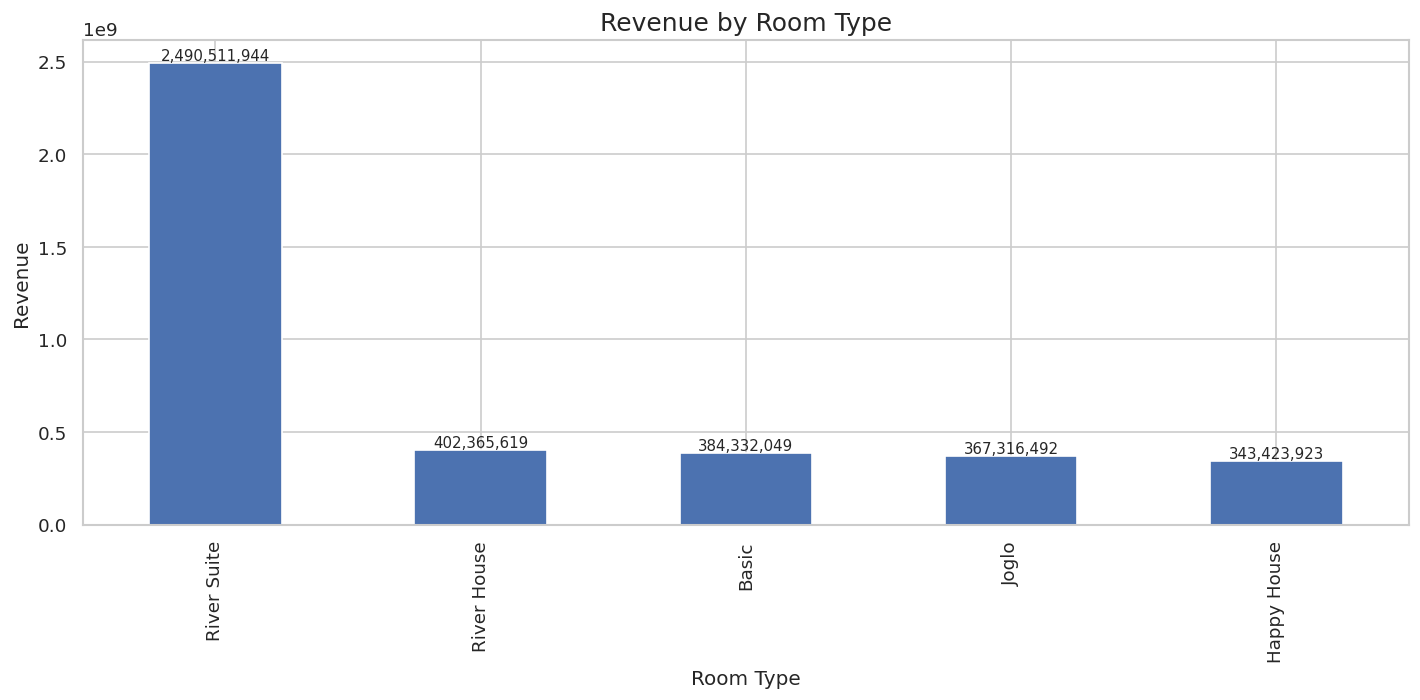

In [ ]:
ax = room_perf.sort_values(
    "Revenue",
    ascending=False
)["Revenue"].plot.bar(figsize=(12,6))

add_value_labels(ax)

plt.title("Revenue by Room Type")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

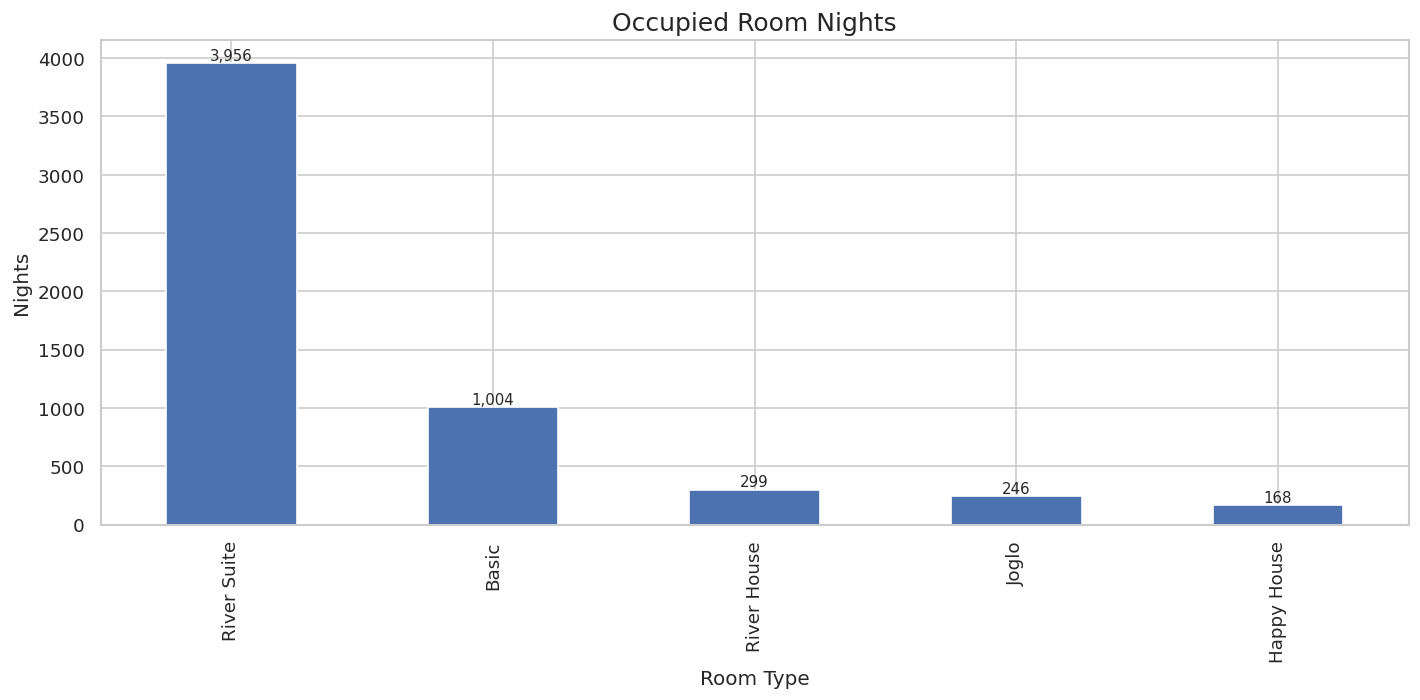

In [ ]:
ax = room_perf.sort_values(
    "Nights",
    ascending=False
)["Nights"].plot.bar(figsize=(12,6))

add_value_labels(ax)

plt.title("Occupied Room Nights")

plt.ylabel("Nights")

plt.tight_layout()

plt.show()

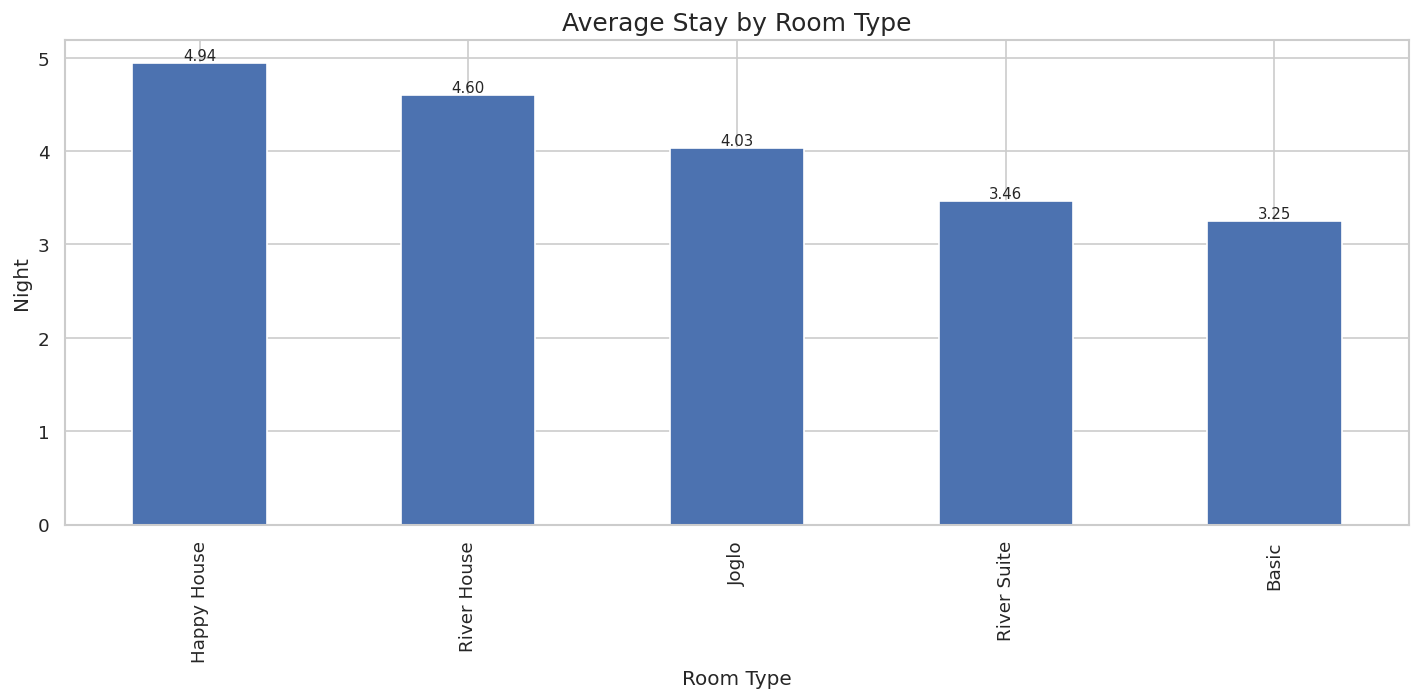

In [ ]:
ax = room_perf.sort_values(
    "Average Stay",
    ascending=False
)["Average Stay"].plot.bar(figsize=(12,6))

add_value_labels(ax, fmt="{:.2f}")

plt.ylabel("Night")

plt.title("Average Stay by Room Type")

plt.tight_layout()

plt.show()

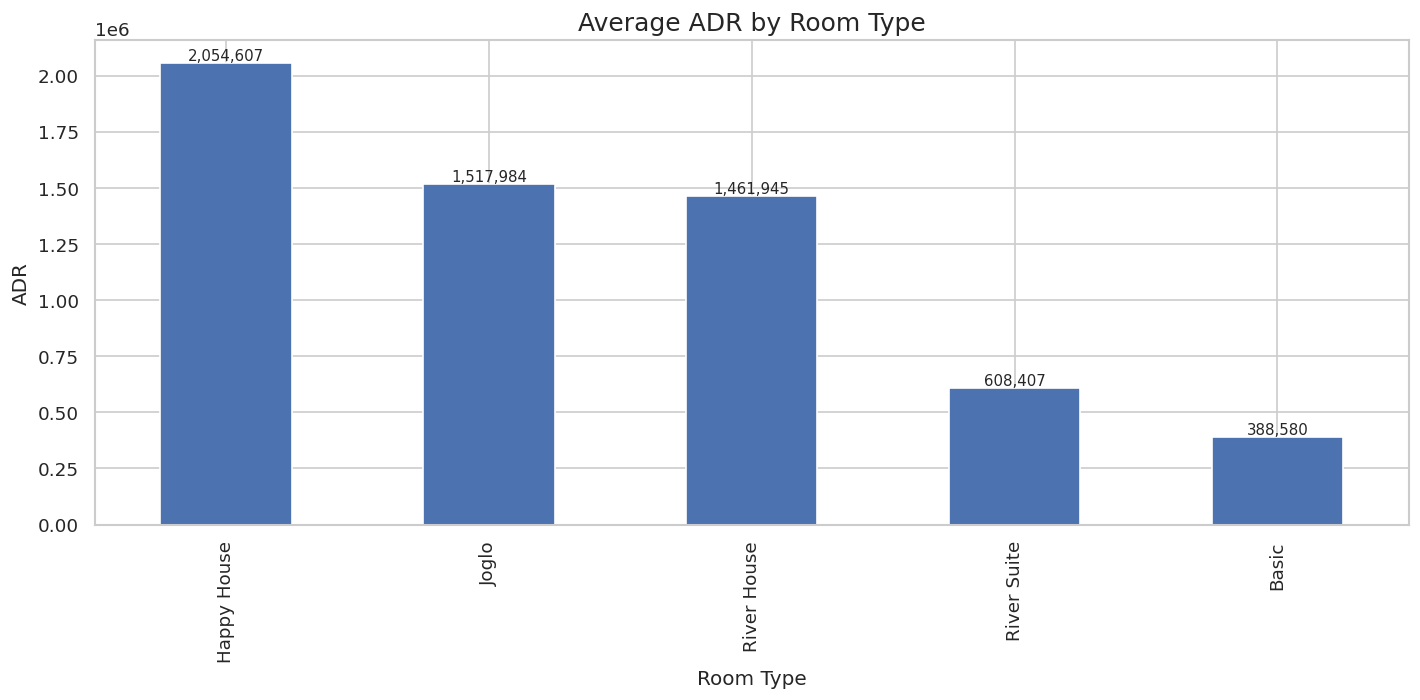

In [ ]:
ax = room_perf.sort_values(
    "ADR",
    ascending=False
)["ADR"].plot.bar(figsize=(12,6))

add_value_labels(ax)

plt.ylabel("ADR")

plt.title("Average ADR by Room Type")

plt.tight_layout()

plt.show()

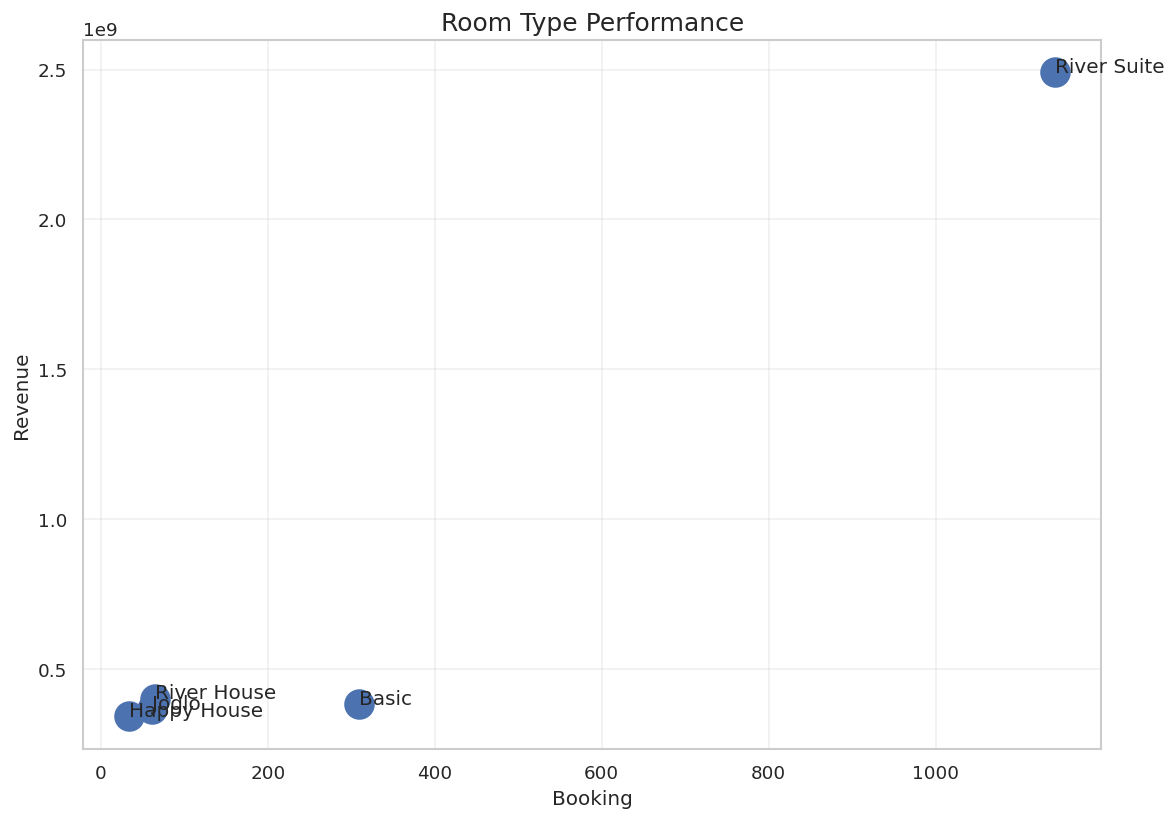

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(
    room_perf["Booking"],
    room_perf["Revenue"],
    s=300
)

for i in room_perf.index:

    plt.text(
        room_perf.loc[i,"Booking"],
        room_perf.loc[i,"Revenue"],
        i
    )

plt.xlabel("Booking")

plt.ylabel("Revenue")

plt.title("Room Type Performance")

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

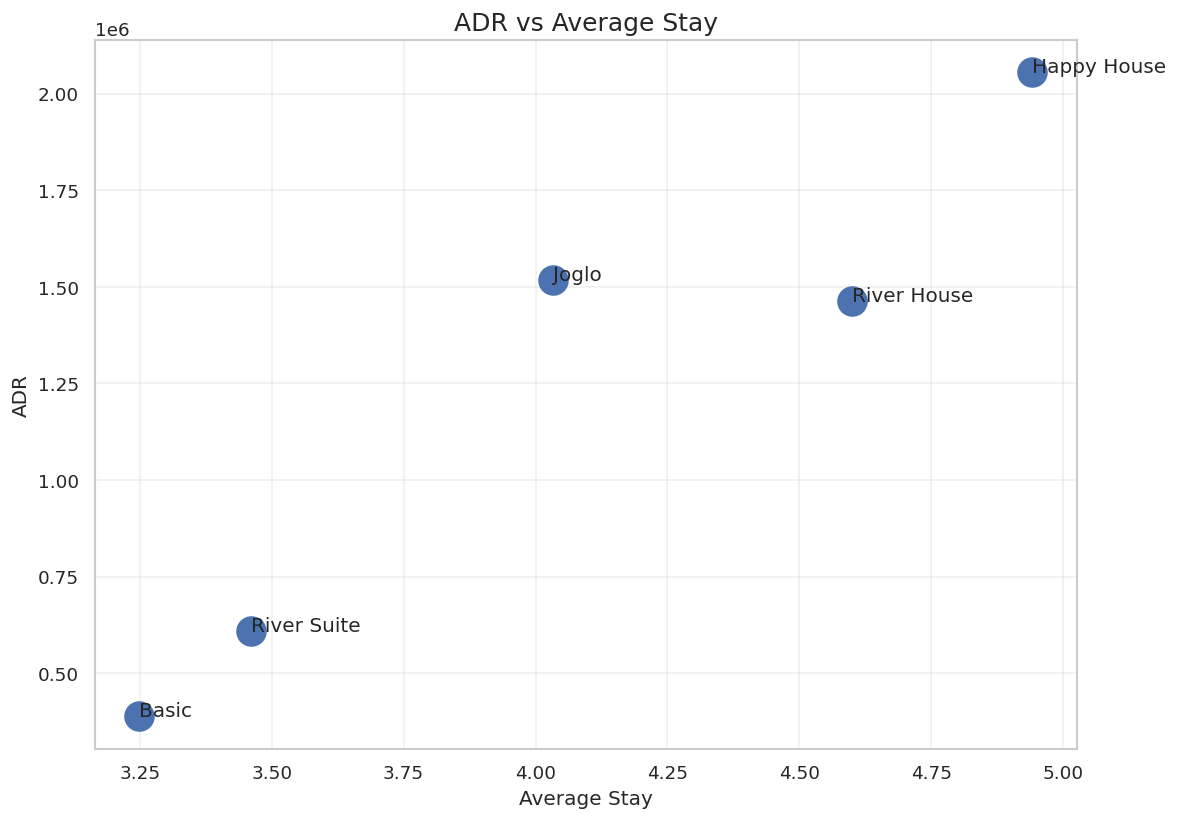

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(
    room_perf["Average Stay"],
    room_perf["ADR"],
    s=300
)

for i in room_perf.index:

    plt.text(
        room_perf.loc[i,"Average Stay"],
        room_perf.loc[i,"ADR"],
        i
    )

plt.xlabel("Average Stay")

plt.ylabel("ADR")

plt.title("ADR vs Average Stay")

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

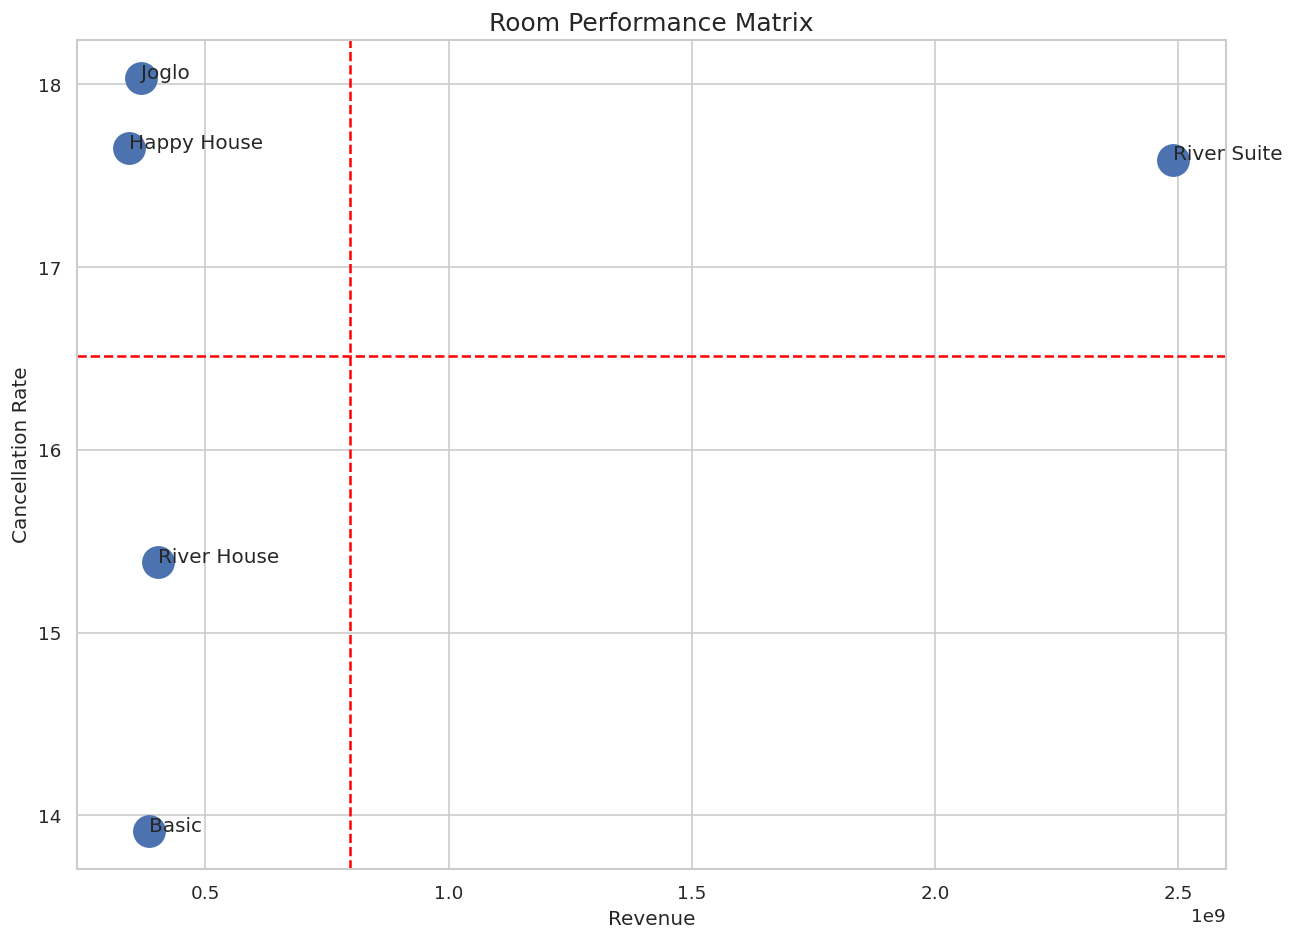

In [ ]:
avg_rev = room_perf["Revenue"].mean()
avg_cancel = room_perf["Cancellation Rate"].mean()

plt.figure(figsize=(11,8))

plt.scatter(
    room_perf["Revenue"],
    room_perf["Cancellation Rate"],
    s=350
)

plt.axvline(avg_rev,color="red",linestyle="--")
plt.axhline(avg_cancel,color="red",linestyle="--")

for i in room_perf.index:

    plt.text(
        room_perf.loc[i,"Revenue"],
        room_perf.loc[i,"Cancellation Rate"],
        i
    )

plt.xlabel("Revenue")

plt.ylabel("Cancellation Rate")

plt.title("Room Performance Matrix")

plt.tight_layout()

plt.show()

In [ ]:
room_perf["Contribution"] = (

    room_perf["Revenue"]

    /

    room_perf["Revenue"].sum()

)*100

display(

room_perf.style.format({

"Contribution":"{:.2f}%"

})

)

,Booking,Nights,Revenue,ADR,Guest,Cancel,Average Stay,Cancellation Rate,Contribution
Room Type,,,,,,,,,
Basic,309,1004,384332049.442825,388580.370463,503,43,3.249191,13.915858,9.64%
Happy House,34,168,343423922.902040,2054607.431523,143,6,4.941176,17.647059,8.61%
Joglo,61,246,367316491.766173,1517984.363290,182,11,4.032787,18.032787,9.21%
River House,65,299,402365618.577705,1461945.254440,199,10,4.600000,15.384615,10.09%
River Suite,1143,3956,2490511943.877832,608407.361812,2009,201,3.461067,17.585302,62.45%


# Executive Dashboard

In [ ]:
kpi = pd.DataFrame({

"Metric":[

"Reservation",

"Revenue",

"Room Nights",

"Average ADR",

"Cancellation",

"Average Stay"

],

"Value":[

len(df),

df["Room Net"].sum(),

df["Nights"].sum(),

round(df["ADR"].mean(),0),

round((df.Status=="CANCELLED").mean()*100,2),

round(df["Nights"].mean(),2)

]

})

display(kpi)

,Metric,Value
0,Reservation,1.612000e+03
1,Revenue,3.987950e+09
2,Room Nights,5.673000e+03
3,Average ADR,6.656090e+05
4,Cancellation,1.681000e+01
5,Average Stay,3.520000e+00


In [ ]:
dashboard = (

    df.groupby(

        df["Arrival"].dt.to_period("M")

    )

    .agg(

        Booking=("Folio","count"),

        Revenue=("Room Net","sum"),

        ADR=("ADR","mean"),

        Nights=("Nights","sum")

    )

)

display(

dashboard.style.format({

"Revenue":"{:,.0f}",

"ADR":"{:,.0f}"

})

)

,Booking,Revenue,ADR,Nights
Arrival,,,,
2025-07,162,"389,389,326","768,203",475
2025-08,218,"542,665,281","670,063",744
2025-09,115,"298,514,777","683,854",401
2025-10,97,"301,302,269","722,081",386
2025-11,96,"153,278,036","664,396",211
2025-12,51,"82,011,066","695,863",133
2026-01,58,"83,826,482","536,232",130
2026-02,59,"216,596,204","511,861",334
2026-03,80,"121,278,437","482,225",240


In [ ]:
best = dashboard.sort_values(

    "Revenue",

    ascending=False

)

display(best.head())

,Booking,Revenue,ADR,Nights
Arrival,,,,
2025-08,218,5.426653e+08,670062.558487,744
2025-07,162,3.893893e+08,768202.631121,475
2026-07,116,3.066547e+08,702109.558119,440
2025-10,97,3.013023e+08,722081.267662,386
2025-09,115,2.985148e+08,683853.513826,401


In [ ]:
display(

best.tail()

)

,Booking,Revenue,ADR,Nights
Arrival,,,,
2026-12,7,4.021447e+07,3.894836e+05,91
2027-05,2,2.900880e+07,8.468498e+05,32
2027-06,1,5.926450e+06,1.185290e+06,5
2027-07,2,5.635031e+06,3.068079e+05,20
2027-01,1,1.413717e+06,1.413717e+06,1


In [ ]:
print("="*70)

print("EXECUTIVE SUMMARY")

print("="*70)

print(f"Highest Revenue Month : {dashboard['Revenue'].idxmax()}")

print(f"Highest Booking Month : {dashboard['Booking'].idxmax()}")

print(f"Highest ADR Month     : {dashboard['ADR'].idxmax()}")

print(f"Highest Nights        : {dashboard['Nights'].idxmax()}")

print(f"Best OTA             : {ota['Revenue'].idxmax()}")

print(f"Best Room            : {room_perf['Revenue'].idxmax()}")

print(f"Top Country          : {country_summary.index[0]}")

print("="*70)

EXECUTIVE SUMMARY
Highest Revenue Month : 2025-08
Highest Booking Month : 2025-08
Highest ADR Month     : 2027-03
Highest Nights        : 2025-08
Best OTA             : Booking.com
Best Room            : River Suite
Top Country          : Australia


In [ ]:
year_summary = (

    df.groupby("Year")

    .agg(

        Booking=("Folio","count"),

        Revenue=("Room Net","sum"),

        ADR=("ADR","mean"),

        Nights=("Nights","sum"),

        Cancel=("Status",lambda x:(x=="CANCELLED").sum())

    )

)

year_summary["Cancellation Rate"]=(

    year_summary["Cancel"]

    /

    year_summary["Booking"]

)*100

display(

year_summary.style.format({

"Revenue":"{:,.0f}",

"ADR":"{:,.0f}",

"Cancellation Rate":"{:.2f}%"

})

)

,Booking,Revenue,ADR,Nights,Cancel,Cancellation Rate
Year,,,,,,
2025,739,"1,767,160,755","701,595",2350,99,13.40%
2026,841,"1,996,696,531","626,573",3062,167,19.86%
2027,32,"224,092,740","860,449",261,5,15.62%


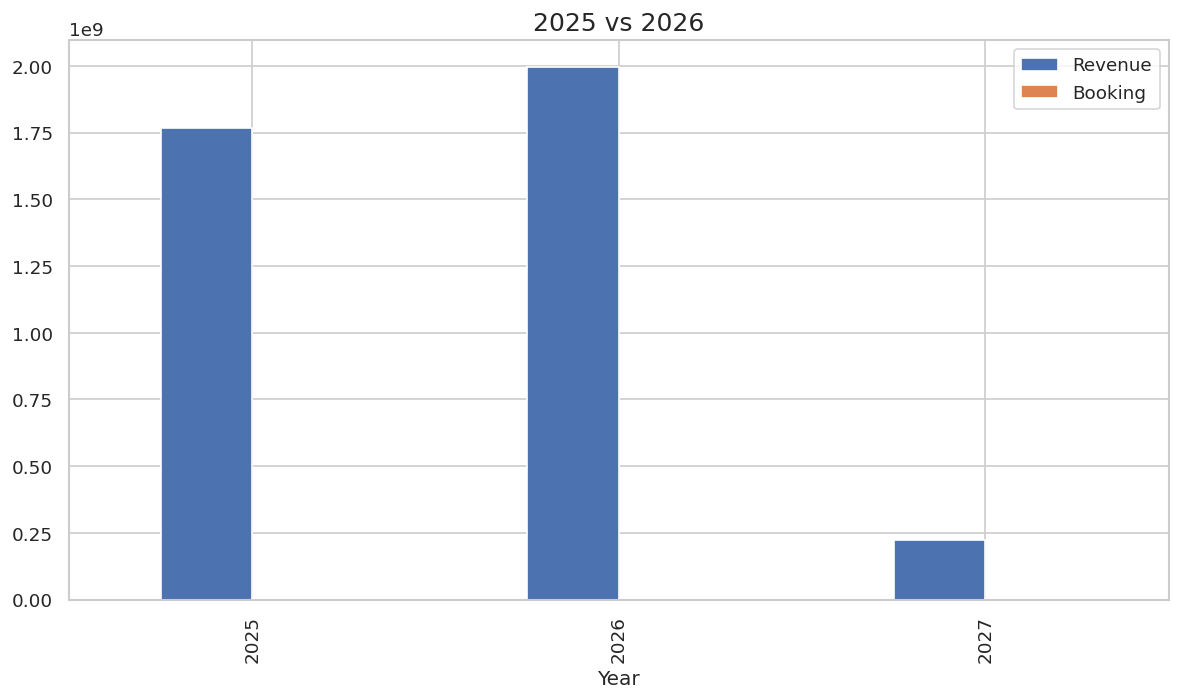

In [ ]:
year_summary[

["Revenue","Booking"]

].plot.bar(

figsize=(10,6)

)

plt.title(

"2025 vs 2026"

)

plt.tight_layout()

plt.show()

In [ ]:
year_summary.to_excel(

"hotel_summary.xlsx"

)

ota.to_excel(

"ota_summary.xlsx"

)

room_perf.to_excel(

"room_summary.xlsx"

)

print("Summary exported successfully.")

Summary exported successfully.


# Conclusion

## Business Highlights

- Revenue trend telah dianalisis berdasarkan bulan.
- Performa OTA telah dibandingkan berdasarkan revenue, ADR, booking, dan cancellation.
- Performa tipe kamar telah dibandingkan berdasarkan revenue, room nights, dan ADR.
- Karakteristik tamu telah dianalisis berdasarkan negara, lama menginap, serta repeat guest.
- Executive dashboard telah merangkum KPI utama untuk mendukung pengambilan keputusan.

Notebook ini dapat dikembangkan lebih lanjut dengan:
- Occupancy Rate (%) apabila data jumlah kamar tersedia.
- RevPAR dan GOPPAR.
- Forecast menggunakan Prophet, ARIMA, atau LSTM.
- Dashboard interaktif menggunakan Plotly Dash atau Streamlit.